# 결과 요약 / 목차 - Mission 10: 20 Newsgroups Text Classification

## 1. 최종 결과

20 Newsgroups의 18,846개 문서를 20개 주제로 분류하는 실험을 진행했다.

최종 모델은 **Subject + Body TF-IDF + LinearSVC**이며,  
고정된 official test 2,827개 문서에서 다음 성능을 기록했다.

| Metric | OOF | Official Test |
|---|---:|---:|
| Accuracy | 0.9031 | **0.9066** |
| Macro F1 | 0.8999 | **0.9046** |
| `talk.religion.misc` Precision | 0.8487 | **0.9359** |
| `talk.religion.misc` Recall | 0.7247 | **0.7766** |
| `talk.religion.misc` F1 | 0.7818 | **0.8488** |

최종 모델은 OOF보다 official test에서 성능이 소폭 상승해,  
교차검증 결과가 실제 holdout test에서도 안정적으로 일반화됨을 확인했다.

특히 주요 병목 클래스였던 `talk.religion.misc`의 F1이  
Stage 5 official test의 0.5732에서 Stage 6 official test의 0.8488로 크게 개선됐다.

---
## 2. 목차: 실험 흐름 및 Notebook 구성

### A. 본 제출 Notebook에 포함된 실험

| 구분 | 실험 내용 | Notebook 내 위치 |
|---|---|---|
| Baseline | Word2Vec·FastText·GloVe + BiGRU 비교 | Section 1–22 |
| Stage 1 (1차 개선) | 학습 설정 및 모델 개선 ablation | Section 23 |
| Stage 2 (2차 개선) | Packed Attention BiGRU 및 추가 ablation | Section 24 |

### B. 별도 Notebook에서 수행한 후속 실험

| Stage | 실험 내용 | 실행 Notebook |
|---|---|---|
| Stage 3 (3차 개선) | Encoded noise 제거 및 sequence length 비교 | 3차 개선 Notebook |
| Stage 4 | TF-IDF, coarse head, ensemble, 5-fold OOF | Stage 4 Notebook |
| Stage 5 | Nested CV, Global LinearSVC, specialist 검증 | Stage 5 Notebook |
| Stage 6 | Subject+Body, ModernBERT, hierarchy, fusion 비교 | Stage 6 Kaggle Notebook |
| Final Test | 최종 모델의 official test 1회 평가 | Official Test Colab |


---

- baselin, 1, 2번 까지는 이 노트북에서 확인가능하며, 3-6번은 아래 깃허브 링크를 통하여 확인 가능함
---
## 3. 전체 실험 결과 요약

| 구분 | 핵심 실험 | 최고 결과 | 주요 결론 |
|---|---|---:|---|
| Baseline | Word2Vec·FastText·GloVe + BiGRU | Macro F1 0.7211 | FastText 기반 baseline 채택 |
| 1차 개선 | 학습 안정화 및 구조 ablation | baseline 대비 비교 | 학습 안정화 조건 검증 |
| 2차 개선 | Packed Attention BiGRU 개선 | 추가 비교 실험 | 복잡도 증가의 실효성 점검 |
| 3차 개선 | Noise cleaning 및 sequence length | J·K·L 비교 | 본문 전처리와 truncation 병목 점검 |
| Stage 4 | TF-IDF 및 5-fold OOF | 0.7424 | Sparse lexical feature가 neural model을 상회 |
| Stage 5 | Nested Global LinearSVC | 0.7518 | Specialist보다 global model이 안정적 |
| Stage 5 Test | Official test | 0.7659 | OOF 성능이 holdout에서도 유지 |
| Stage 6 | Subject+Body LinearSVC | 0.8999 | Subject 복원이 가장 큰 개선 |
| Final Test | Subject+Body LinearSVC | **0.9046** | 최종 일반화 성능 확인 |

---

## 4. 최종 결론

이번 프로젝트 실험에서 가장 큰 성능 향상은 복잡한 모델 구조가 아니라  
제거되어 있던 **Subject metadata를 복원한 것**에서 발생했다.

초기 실험에서는 작성자, 이메일, 조직명 등 header 기반 leakage를 줄이기 위해 headers를 제거했다. 그러나 이 과정에서 문서의 주제를 직접 요약하는 Subject 정보도 함께 제거되었다. Stage 6에서는 raw header에서 Subject만 선택적으로 복원하고 나머지 header 정보는 사용하지 않았다.

Body-only LinearSVC의 Macro F1은 0.7559였지만,  
Subject와 Body를 함께 사용하자 0.8999까지 상승했다.

ModernBERT, hierarchical classifier, multi-prototype, fusion 모델도 비교했지만,  
전체 Macro F1 기준으로는 단순하고 해석 가능한  
**Subject + Body TF-IDF + LinearSVC**가 가장 높은 성능을 기록했다.

따라서 이 데이터셋에서는 모델 복잡도보다  
적절한 입력 정보, sparse lexical representation, 안정적인 평가 설계가 더 중요했다.

#### 제목을 포함하여 학습 후 결과가 좋아진 점에 대하여

초기 baseline에도 header에 있던 Subject를 넣었다면 점수는 상당히 높아졌을 가능성이 크다. 다만 최종 0.90은 Subject 복원과 TF-IDF·char n-gram·LinearSVC 조합이 함께 만든 결과라서, neural baseline도 동일한 점수에 도달했을 것이라고 단정할 수는 없다.
결론적으로, 데이터의 성격과 구조를 살피는것이 중요했다.

---

## 5. 전체 코드 및 실행 결과

- GitHub  
  https://github.com/uyt5041-lab/mission10-20newsgroups

- Kaggle Stage 6 전체 실험  
  https://www.kaggle.com/code/chattybeak/mission-10-stage-6/notebook

- Stage 6 Official Test Colab  
  https://colab.research.google.com/drive/1Igk8Bjw43qUYsRXVitCR6Yv0BcSAFyd7

---
---

# Baseline - 20 Newsgroups 텍스트 분류
## Word2Vec · FastText · GloVe + BiGRU 비교


이 노트북은 18,846개의 뉴스 문서를 20개 category로 분류합니다.  
세 embedding만 교체하고 나머지 조건은 동일하게 유지하여 비교가 공정하도록 구성했습니다.

### 포함 내용
- 데이터 로드, 정제, tokenization
- stratified train / validation / test 분리
- Word2Vec, FastText, GloVe embedding matrix 생성
- PyTorch `Dataset`, `DataLoader`
- 동일한 BiGRU classifier로 3-way 비교
- Accuracy, Macro Precision, Macro Recall, Macro F1
- 학습 곡선, confusion matrix, class별 성능
- OOV/coverage 분석
- Attention BiGRU 심화 실험

## 실행 결과 한눈에 보기

전체 데이터와 T4 GPU에서 실행한 결과입니다.

| 모델 | Embedding | Test Accuracy | Test Macro F1 |
|---|---:|---:|---:|
| BiGRU | Word2Vec | 0.6548 | 0.6326 |
| BiGRU | GloVe | 0.6714 | 0.6508 |
| BiGRU | FastText | **0.6792** | **0.6658** |
| Attention BiGRU | FastText fine-tuning | **0.7227** | **0.7129** |

### 핵심 결론

1. 동일한 BiGRU 조건에서는 **FastText가 가장 우수**했습니다.
2. FastText와 Word2Vec의 vocabulary coverage는 모두 100%였으므로, 두 모델의 차이는 단순 OOV 차이보다 **FastText의 subword 표현력**과 희귀 단어 vector 품질에서 나온 것으로 해석할 수 있습니다.
3. GloVe coverage는 81.98%로 낮았지만 Word2Vec보다 높은 성능을 냈습니다. 대규모 외부 corpus에서 학습한 semantic prior가 OOV 손실을 일부 보완한 것으로 보입니다.
4. FastText 기반 Attention BiGRU는 기본 FastText BiGRU보다 Accuracy가 **4.35%p**, Macro F1이 **4.71%p** 향상되었습니다.
5. 다만 심화 모델은 validation loss가 증가하면서 F1이 향상되었습니다. 이는 정답 class 구분은 좋아졌지만, 틀린 예측에 지나치게 높은 확률을 주는 **과신과 overfitting**이 남아 있음을 뜻합니다.

> 주의: Word2Vec·FastText·GloVe 비교는 동일한 모델 조건의 공정 비교입니다.  
> Attention BiGRU는 구조와 embedding fine-tuning 여부가 함께 바뀐 별도 심화 실험이므로, embedding 비교표와 분리해서 해석해야 합니다.

## 0. 해결 전략과 노트북 구조

### 공정 비교 원칙
세 embedding을 비교할 때 아래 요소는 고정합니다.

- 동일한 데이터 split
- 동일한 vocabulary
- 동일한 seed
- 동일한 BiGRU 구조
- 동일한 optimizer와 epoch 수
- 동일한 평가 metric

따라서 성능 차이는 가능한 한 embedding 표현의 차이에서 나오도록 설계합니다.

### 전체 흐름
1. **환경 점검:** Colab package 충돌 없이 `gensim`만 설치
2. **데이터 준비:** 20 Newsgroups 로드, class 분포 확인
3. **전처리:** URL·email·특수문자 정제 후 tokenization
4. **분할:** stratified train 70% / validation 15% / test 15%
5. **Vocabulary:** train token만 사용해 `<PAD>`, `<UNK>` 포함 vocabulary 생성
6. **Embedding:** Word2Vec·FastText 직접 학습, pretrained GloVe 로드
7. **공정 비교:** 같은 BiGRU에 embedding matrix만 교체
8. **평가:** Accuracy, Macro Precision, Macro Recall, Macro F1
9. **오류 분석:** class별 report, confusion matrix, 실제 오분류 문서
10. **심화 실험:** 최고 embedding에 Attention BiGRU와 fine-tuning 적용
11. **저장:** 결과 CSV와 best checkpoint 저장

### 모델 입력 흐름
`raw text → tokens → token index → embedding vector → BiGRU → document vector → 20-class logits`

### 왜 validation set을 따로 쓰는가?
validation set은 early stopping과 best checkpoint 선택에 사용합니다.  
test set을 학습 중간에 보지 않기 때문에 최종 test 성능을 더 정직하게 평가할 수 있습니다.

## 1. Colab 환경 설정

Colab에서 **런타임 → 런타임 유형 변경 → T4 GPU**를 선택하는 것을 권장합니다.

### NumPy binary 충돌 방지
이전 설치 셀은 `scipy<1.14`를 강제로 설치하면서 Colab의 NumPy/Pandas binary 조합을 깨뜨릴 수 있었습니다.  
수정된 셀은 **Colab에 이미 설치된 NumPy·Pandas·SciPy를 건드리지 않고**, Python 3.12와 최신 SciPy를 지원하는 `gensim 4.4.0` wheel만 설치합니다.

> 이미 이전 셀을 실행한 runtime에서 `numpy.dtype size changed`가 발생했다면  
> **런타임 → 연결 해제 및 런타임 삭제** 후 다시 연결하고, 이 노트북을 위에서부터 실행하세요.  
> 단순 재실행보다 runtime 삭제가 확실합니다.

In [ ]:
# Colab 최초 1회 실행
# --no-deps: Colab의 NumPy/Pandas/SciPy를 임의로 downgrade하지 않음
import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "--no-deps",
        "gensim==4.4.0",
    ],
    check=True,
)

try:
    print("gensim installed:", version("gensim"))
except PackageNotFoundError:
    raise RuntimeError("gensim 설치를 확인하지 못했습니다. 셀을 다시 실행해 주세요.")

gensim installed: 4.4.0


### Import 진단

아래 셀은 scientific Python package를 import하고 version을 출력합니다.  
과거 runtime의 package가 남아 binary incompatibility가 발생하면, 긴 traceback 대신 해결 방법을 포함한 명확한 오류를 표시합니다.

In [ ]:
import os
import gc
import re
import time
import random
import warnings
from collections import Counter
from pathlib import Path

try:
    import numpy as np
    import pandas as pd
    import scipy
except ValueError as error:
    if "numpy.dtype size changed" in str(error):
        raise RuntimeError(
            "NumPy/Pandas binary incompatibility가 남아 있습니다. "
            "Colab 메뉴에서 [런타임 → 연결 해제 및 런타임 삭제]를 선택한 뒤 "
            "새 runtime에서 첫 셀부터 다시 실행하세요. "
            "수정된 설치 셀은 NumPy·Pandas·SciPy를 변경하지 않습니다."
        ) from error
    raise

import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

try:
    import gensim
    import gensim.downloader as api
    from gensim.models import Word2Vec, FastText
except ImportError as error:
    raise RuntimeError(
        "gensim import에 실패했습니다. 환경 설정 셀을 먼저 실행한 뒤 다시 시도하세요."
    ) from error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

warnings.filterwarnings("ignore")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Gensim:", gensim.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

NumPy: 2.0.2
Pandas: 2.2.2
SciPy: 1.16.3
Gensim: 4.4.0
PyTorch: 2.11.0+cu128
CUDA available: True


## 2. 재현 가능한 실험 설정

`FAST_DEV_RUN=True`는 전체 pipeline을 빠르게 점검하기 위한 mode입니다.  
제출용 결과는 반드시 `False`로 실행하세요.

In [ ]:
SEED = 42
FAST_DEV_RUN = False

# 데이터 설정
TEST_SIZE = 0.15
VAL_SIZE = 0.15
MIN_FREQ = 2
MAX_VOCAB_SIZE = 40_000
MAX_LEN = 300
REMOVE_STOPWORDS = False

# embedding 설정
EMBED_DIM = 100
EMBED_TRAIN_EPOCHS = 10 if not FAST_DEV_RUN else 2
EMBEDDING_TYPES = ['word2vec', 'fasttext', 'glove']

# model / 학습 설정
BATCH_SIZE = 128
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.35
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 7 if not FAST_DEV_RUN else 1
PATIENCE = 2
FREEZE_EMBEDDING = True
NUM_WORKERS = 2

CHECKPOINT_DIR = Path('/content/checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)
print('DEVICE:', DEVICE)

DEVICE: cuda


## 3. 데이터 로드

header, footer, quote를 제거하면 작성자 이름, 이메일 주소, 인용문처럼 지나치게 쉬운 단서를 줄일 수 있습니다.

In [ ]:
news_data = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=SEED,
)

texts = np.array(news_data.data, dtype=object)
labels = np.array(news_data.target, dtype=np.int64)
target_names = list(news_data.target_names)

print(f'전체 문서 수: {len(texts):,}')
print(f'class 수: {len(target_names)}')
print('첫 문서 일부:')
print(texts[0][:500])

전체 문서 수: 18,846
class 수: 20
첫 문서 일부:


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a


### 3.1 Class 분포

데이터가 비교적 균형적이더라도 class별 성능을 동일하게 반영하기 위해 macro metric을 함께 사용합니다.

,class_id,class_name,count
0,0,alt.atheism,799
1,1,comp.graphics,973
2,2,comp.os.ms-windows.misc,985
3,3,comp.sys.ibm.pc.hardware,982
4,4,comp.sys.mac.hardware,963
5,5,comp.windows.x,988
6,6,misc.forsale,975
7,7,rec.autos,990
8,8,rec.motorcycles,996
9,9,rec.sport.baseball,994


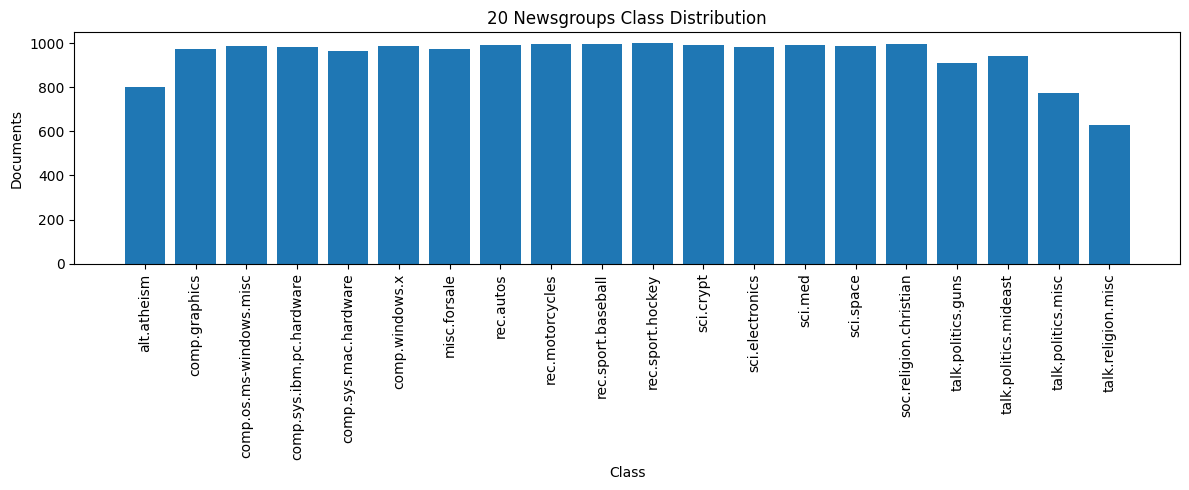

In [ ]:
class_counts = pd.Series(labels).value_counts().sort_index()
class_distribution = pd.DataFrame({
    'class_id': range(len(target_names)),
    'class_name': target_names,
    'count': class_counts.values,
})

display(class_distribution)

plt.figure(figsize=(12, 5))
plt.bar(class_distribution['class_name'], class_distribution['count'])
plt.xticks(rotation=90)
plt.title('20 Newsgroups Class Distribution')
plt.xlabel('Class')
plt.ylabel('Documents')
plt.tight_layout()
plt.show()

## 4. 텍스트 정제와 tokenization

정제 단계:
1. 소문자화
2. URL과 email 제거
3. 영문자와 apostrophe 외 문자 제거
4. 연속 공백 정리
5. regex tokenizer 적용

기본값은 stopword를 유지합니다. RNN은 기능어와 순서도 활용할 수 있기 때문입니다.

In [ ]:
TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?")
STOP_WORDS = set(ENGLISH_STOP_WORDS)


def clean_and_tokenize(text, remove_stopwords=False):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\b[\w.\-+]+@[\w.\-]+\.\w+\b', ' ', text)
    text = re.sub(r"[^a-z'\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = TOKEN_PATTERN.findall(text)

    if remove_stopwords:
        tokens = [token for token in tokens if token not in STOP_WORDS]

    return tokens


sample_tokens = clean_and_tokenize(texts[0], REMOVE_STOPWORDS)
print(sample_tokens[:80])
print('token 수:', len(sample_tokens))

['i', 'am', 'sure', 'some', 'bashers', 'of', 'pens', 'fans', 'are', 'pretty', 'confused', 'about', 'the', 'lack', 'of', 'any', 'kind', 'of', 'posts', 'about', 'the', 'recent', 'pens', 'massacre', 'of', 'the', 'devils', 'actually', 'i', 'am', 'bit', 'puzzled', 'too', 'and', 'a', 'bit', 'relieved', 'however', 'i', 'am', 'going', 'to', 'put', 'an', 'end', 'to', 'non', 'pittsburghers', 'relief', 'with', 'a', 'bit', 'of', 'praise', 'for', 'the', 'pens', 'man', 'they', 'are', 'killing', 'those', 'devils', 'worse', 'than', 'i', 'thought', 'jagr', 'just', 'showed', 'you', 'why', 'he', 'is', 'much', 'better', 'than', 'his', 'regular', 'season']
token 수: 138


## 5. Train / Validation / Test 분리

70% / 15% / 15%로 나누고 `stratify`를 사용해 class 비율을 유지합니다.

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts,
    labels,
    test_size=VAL_SIZE + TEST_SIZE,
    random_state=SEED,
    stratify=labels,
)

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=temp_labels,
)

if FAST_DEV_RUN:
    train_texts, train_labels = train_texts[:2500], train_labels[:2500]
    val_texts, val_labels = val_texts[:600], val_labels[:600]
    test_texts, test_labels = test_texts[:600], test_labels[:600]

print(f'train: {len(train_texts):,}')
print(f'validation: {len(val_texts):,}')
print(f'test: {len(test_texts):,}')

train: 13,192
validation: 2,827
test: 2,827


### 5.1 각 split tokenization

vocabulary와 직접 학습하는 embedding에는 train token만 사용하여 leakage를 방지합니다.

In [ ]:
train_tokens = [clean_and_tokenize(text, REMOVE_STOPWORDS) for text in train_texts]
val_tokens = [clean_and_tokenize(text, REMOVE_STOPWORDS) for text in val_texts]
test_tokens = [clean_and_tokenize(text, REMOVE_STOPWORDS) for text in test_texts]


def non_empty_ratio(tokenized_documents):
    return np.mean([len(tokens) > 0 for tokens in tokenized_documents])


print(f'train non-empty ratio: {non_empty_ratio(train_tokens):.4f}')
print(f'validation non-empty ratio: {non_empty_ratio(val_tokens):.4f}')
print(f'test non-empty ratio: {non_empty_ratio(test_tokens):.4f}')

train non-empty ratio: 0.9727
validation non-empty ratio: 0.9706
test non-empty ratio: 0.9667


### 5.2 문서 길이 분포

`MAX_LEN=300`을 기준으로 긴 문서를 자릅니다. 잘리는 비율을 확인해 선택 근거를 남깁니다.

,token_count
count,13192.000000
mean,197.235597
std,769.012918
min,0.000000
50%,80.000000
75%,163.000000
90%,328.000000
95%,555.000000
99%,1860.080000
max,38136.000000


MAX_LEN=300에서 잘리는 train 문서 비율: 11.23%


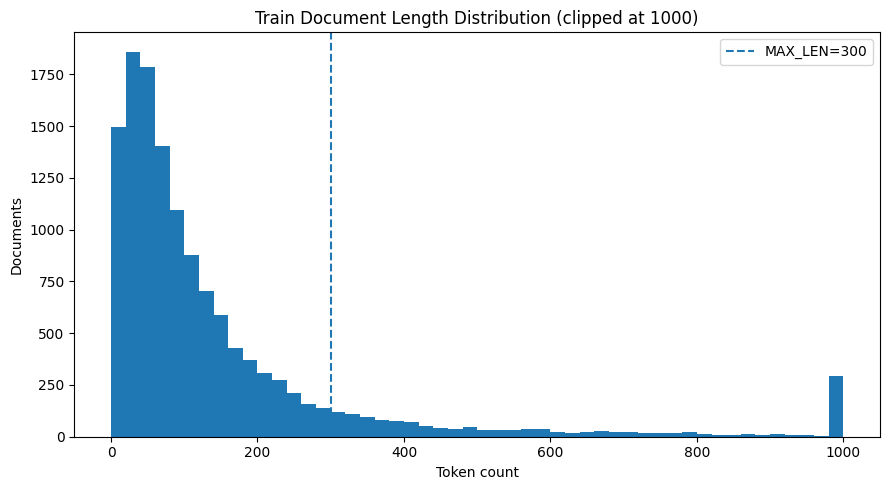

In [ ]:
train_lengths = np.array([len(tokens) for tokens in train_tokens])

display(
    pd.Series(train_lengths).describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    ).to_frame('token_count')
)

truncated_ratio = np.mean(train_lengths > MAX_LEN)
print(f'MAX_LEN={MAX_LEN}에서 잘리는 train 문서 비율: {truncated_ratio:.2%}')

plt.figure(figsize=(9, 5))
plt.hist(np.clip(train_lengths, 0, 1000), bins=50)
plt.axvline(MAX_LEN, linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Train Document Length Distribution (clipped at 1000)')
plt.xlabel('Token count')
plt.ylabel('Documents')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Vocabulary 생성

- `<PAD>`: batch 내 길이를 맞추기 위한 padding
- `<UNK>`: vocabulary에 없는 token

`MIN_FREQ=2`로 한 번만 등장한 희귀 token을 제거합니다.

In [ ]:
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
PAD_IDX = 0
UNK_IDX = 1

token_counter = Counter(
    token
    for document in train_tokens
    for token in document
)

most_common_tokens = [
    token
    for token, frequency in token_counter.most_common(MAX_VOCAB_SIZE - 2)
    if frequency >= MIN_FREQ
]

itos = [PAD_TOKEN, UNK_TOKEN] + most_common_tokens
stoi = {token: index for index, token in enumerate(itos)}

print(f'고유 train token 수: {len(token_counter):,}')
print(f'최종 vocabulary 크기: {len(itos):,}')
print('상위 token:', token_counter.most_common(20))

고유 train token 수: 83,118
최종 vocabulary 크기: 40,000
상위 token: [('the', 122935), ('to', 61202), ('ax', 58829), ('a', 55942), ('of', 54768), ('and', 49560), ('i', 38534), ('in', 35843), ('is', 35096), ('that', 31477), ('it', 24156), ('for', 23081), ('you', 19876), ('this', 16656), ('on', 16553), ('be', 15521), ('have', 15128), ('are', 14783), ('with', 14714), ('not', 14659)]


### 6.1 Token을 정수 index로 변환

In [ ]:
def encode_tokens(tokens, stoi, max_len):
    token_ids = [stoi.get(token, UNK_IDX) for token in tokens[:max_len]]

    if not token_ids:
        token_ids = [UNK_IDX]

    return token_ids


train_sequences = [encode_tokens(tokens, stoi, MAX_LEN) for tokens in train_tokens]
val_sequences = [encode_tokens(tokens, stoi, MAX_LEN) for tokens in val_tokens]
test_sequences = [encode_tokens(tokens, stoi, MAX_LEN) for tokens in test_tokens]


def unknown_token_ratio(sequences):
    total = sum(len(sequence) for sequence in sequences)
    unknown = sum(
        token_id == UNK_IDX
        for sequence in sequences
        for token_id in sequence
    )
    return unknown / max(total, 1)


print(f'validation <UNK> ratio: {unknown_token_ratio(val_sequences):.2%}')
print(f'test <UNK> ratio: {unknown_token_ratio(test_sequences):.2%}')

validation <UNK> ratio: 2.52%
test <UNK> ratio: 2.50%


## 7. PyTorch Dataset과 DataLoader

`collate_fn`에서 현재 batch의 최장 문장까지만 padding합니다.  
`lengths`는 `pack_padded_sequence()`가 padding을 건너뛰도록 사용합니다.

In [ ]:
class NewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        sequence = torch.tensor(self.sequences[index], dtype=torch.long)
        label = torch.tensor(self.labels[index], dtype=torch.long)
        return sequence, label


def collate_batch(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=PAD_IDX,
    )
    labels = torch.stack(labels)
    return padded_sequences, lengths, labels


train_dataset = NewsDataset(train_sequences, train_labels)
val_dataset = NewsDataset(val_sequences, val_labels)
test_dataset = NewsDataset(test_sequences, test_labels)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

sample_batch = next(iter(train_loader))
print('padded input shape:', sample_batch[0].shape)
print('length shape:', sample_batch[1].shape)
print('label shape:', sample_batch[2].shape)

padded input shape: torch.Size([128, 300])
length shape: torch.Size([128])
label shape: torch.Size([128])


## 8. Word2Vec, FastText, GloVe 준비

- **Word2Vec:** 주변 문맥으로 word vector를 학습
- **FastText:** character n-gram을 이용해 희귀어와 철자 변형에 강함
- **GloVe:** 대규모 corpus의 global co-occurrence 통계를 이용한 pretrained vector

In [ ]:
print('Word2Vec 학습 시작')
word2vec_model = Word2Vec(
    sentences=train_tokens,
    vector_size=EMBED_DIM,
    window=5,
    min_count=MIN_FREQ,
    workers=max(os.cpu_count() - 1, 1),
    sg=1,
    negative=10,
    epochs=EMBED_TRAIN_EPOCHS,
    seed=SEED,
)

print('FastText 학습 시작')
fasttext_model = FastText(
    sentences=train_tokens,
    vector_size=EMBED_DIM,
    window=5,
    min_count=MIN_FREQ,
    workers=max(os.cpu_count() - 1, 1),
    sg=1,
    negative=10,
    epochs=EMBED_TRAIN_EPOCHS,
    seed=SEED,
)

print('GloVe pretrained vector 다운로드/로드')
glove_vectors = api.load('glove-wiki-gigaword-100')

print('Word2Vec vocab:', len(word2vec_model.wv))
print('FastText vocab:', len(fasttext_model.wv))
print('GloVe vocab:', len(glove_vectors))

Word2Vec 학습 시작
FastText 학습 시작
GloVe pretrained vector 다운로드/로드
[==================================================] 100.0% 128.1/128.1MB downloaded
Word2Vec vocab: 42078
FastText vocab: 42078
GloVe vocab: 400000


### 8.1 Embedding matrix 생성

- row 번호는 vocabulary index와 동일
- `<PAD>` vector는 0
- 없는 token은 작은 random vector

In [ ]:
def build_embedding_matrix(vector_source, stoi, embedding_dim, source_name):
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(
        loc=0.0,
        scale=0.05,
        size=(len(stoi), embedding_dim),
    ).astype(np.float32)

    matrix[PAD_IDX] = np.zeros(embedding_dim, dtype=np.float32)

    found = 0
    missing_examples = []

    for token, index in stoi.items():
        if index in (PAD_IDX, UNK_IDX):
            continue

        try:
            if source_name == 'fasttext':
                vector = vector_source.get_vector(token)
            else:
                vector = vector_source[token]

            matrix[index] = np.asarray(vector, dtype=np.float32)
            found += 1

        except (KeyError, ValueError):
            if len(missing_examples) < 15:
                missing_examples.append(token)

    eligible = max(len(stoi) - 2, 1)
    coverage = found / eligible

    return matrix, {
        'embedding': source_name,
        'found_words': found,
        'eligible_words': eligible,
        'coverage': coverage,
        'missing_examples': missing_examples,
    }


embedding_matrices = {}
coverage_rows = []

embedding_matrices['word2vec'], row = build_embedding_matrix(
    word2vec_model.wv,
    stoi,
    EMBED_DIM,
    'word2vec',
)
coverage_rows.append(row)

embedding_matrices['fasttext'], row = build_embedding_matrix(
    fasttext_model.wv,
    stoi,
    EMBED_DIM,
    'fasttext',
)
coverage_rows.append(row)

embedding_matrices['glove'], row = build_embedding_matrix(
    glove_vectors,
    stoi,
    EMBED_DIM,
    'glove',
)
coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df[['embedding', 'found_words', 'eligible_words', 'coverage']])

for row in coverage_rows:
    print(f"\n[{row['embedding']}] missing examples:")
    print(row['missing_examples'])

,embedding,found_words,eligible_words,coverage
0,word2vec,39998,39998,1.000000
1,fasttext,39998,39998,1.000000
2,glove,32790,39998,0.819791



[word2vec] missing examples:
[]

[fasttext] missing examples:
[]

[glove] missing examples:
["don't", "it's", "i'm", "i've", "can't", "doesn't", "that's", "didn't", "you're", "i'd", "isn't", "i'll", "there's", "won't", "wouldn't"]


### Coverage 해석

- Word2Vec은 train vocabulary와 같은 corpus에서 학습하므로 coverage가 높아야 합니다.
- FastText는 subword 조합으로 vector를 생성할 수 있어 coverage가 가장 높게 나올 가능성이 큽니다.
- GloVe는 외부 corpus에 없는 전문용어, 오타, 합성어가 OOV가 될 수 있습니다.

## 9. 공통 BiGRU 분류 모델

구조:
1. pretrained embedding lookup
2. bidirectional GRU
3. 마지막 forward/backward hidden state 결합
4. LayerNorm + Dropout
5. 20-class linear classifier

초기 비교에서는 embedding을 freeze해 embedding 자체의 차이를 더 직접적으로 관찰합니다.

In [ ]:
class BiGRUClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_classes,
        num_layers=1,
        dropout=0.35,
        freeze_embedding=True,
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32,
        )

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embedding,
            padding_idx=PAD_IDX,
        )

        self.gru = nn.GRU(
            input_size=embedding_tensor.shape[1],
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, hidden = self.gru(packed)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        document_vector = torch.cat(
            [forward_hidden, backward_hidden],
            dim=1,
        )

        document_vector = self.norm(document_vector)
        document_vector = self.dropout(document_vector)
        logits = self.classifier(document_vector)

        return logits

## 10. 학습 및 평가 함수

평가 지표:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1

validation Macro F1을 기준으로 early stopping합니다.

In [ ]:
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro',
        zero_division=0,
    )
    return {
        'accuracy': accuracy,
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
    }


@torch.no_grad()
def evaluate_model(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    for input_ids, lengths, labels_batch in data_loader:
        input_ids = input_ids.to(DEVICE, non_blocking=True)
        lengths = lengths.to(DEVICE, non_blocking=True)
        labels_batch = labels_batch.to(DEVICE, non_blocking=True)

        logits = model(input_ids, lengths)
        loss = criterion(logits, labels_batch)
        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * labels_batch.size(0)
        all_labels.extend(labels_batch.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    average_loss = total_loss / len(data_loader.dataset)
    metrics = compute_metrics(all_labels, all_predictions)

    return average_loss, metrics, np.array(all_labels), np.array(all_predictions)


def train_model(
    model,
    train_loader,
    val_loader,
    experiment_name,
    max_epochs=7,
    patience=2,
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=1,
    )

    checkpoint_path = CHECKPOINT_DIR / f'{experiment_name}.pt'
    best_val_f1 = -np.inf
    epochs_without_improvement = 0

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_macro_f1': [],
    }

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        for input_ids, lengths, labels_batch in train_loader:
            input_ids = input_ids.to(DEVICE, non_blocking=True)
            lengths = lengths.to(DEVICE, non_blocking=True)
            labels_batch = labels_batch.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels_batch)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item() * labels_batch.size(0)

        train_loss = epoch_loss / len(train_loader.dataset)
        val_loss, val_metrics, _, _ = evaluate_model(
            model,
            val_loader,
            criterion,
        )

        scheduler.step(val_metrics['macro_f1'])

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['val_macro_f1'].append(val_metrics['macro_f1'])

        elapsed = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f'[{experiment_name}] '
            f'Epoch {epoch:02d}/{max_epochs} | '
            f'train loss {train_loss:.4f} | '
            f'val loss {val_loss:.4f} | '
            f"val acc {val_metrics['accuracy']:.4f} | "
            f"val macro F1 {val_metrics['macro_f1']:.4f} | "
            f'lr {current_lr:.2e} | '
            f'{elapsed:.1f}s'
        )

        if val_metrics['macro_f1'] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics['macro_f1']
            torch.save(model.state_dict(), checkpoint_path)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f'Early stopping: {patience} epoch 동안 개선 없음')
            break

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=DEVICE)
    )

    return model, history, best_val_f1


def plot_training_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history['train_loss'], marker='o', label='train loss')
    plt.plot(epochs, history['val_loss'], marker='o', label='validation loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history['val_accuracy'], marker='o', label='validation accuracy')
    plt.plot(epochs, history['val_macro_f1'], marker='o', label='validation macro F1')
    plt.title(f'{title} - Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 11. 세 embedding 실험

Word2Vec → FastText → GloVe 순서로 같은 모델을 학습합니다.


Embedding experiment: word2vec
[bigru_word2vec] Epoch 01/7 | train loss 2.2305 | val loss 1.6261 | val acc 0.4609 | val macro F1 0.4363 | lr 2.00e-03 | 3.9s
[bigru_word2vec] Epoch 02/7 | train loss 1.4609 | val loss 1.2631 | val acc 0.5766 | val macro F1 0.5504 | lr 2.00e-03 | 2.9s
[bigru_word2vec] Epoch 03/7 | train loss 1.2426 | val loss 1.2136 | val acc 0.5914 | val macro F1 0.5656 | lr 2.00e-03 | 2.9s
[bigru_word2vec] Epoch 04/7 | train loss 1.0951 | val loss 1.1400 | val acc 0.6357 | val macro F1 0.6136 | lr 2.00e-03 | 3.0s
[bigru_word2vec] Epoch 05/7 | train loss 1.0063 | val loss 1.0689 | val acc 0.6654 | val macro F1 0.6433 | lr 2.00e-03 | 2.9s
[bigru_word2vec] Epoch 06/7 | train loss 0.9492 | val loss 1.0326 | val acc 0.6760 | val macro F1 0.6603 | lr 2.00e-03 | 3.0s
[bigru_word2vec] Epoch 07/7 | train loss 0.8774 | val loss 1.0346 | val acc 0.6781 | val macro F1 0.6601 | lr 2.00e-03 | 3.0s

Test metrics
accuracy           0.6548
macro_precision    0.6552
macro_recall       0

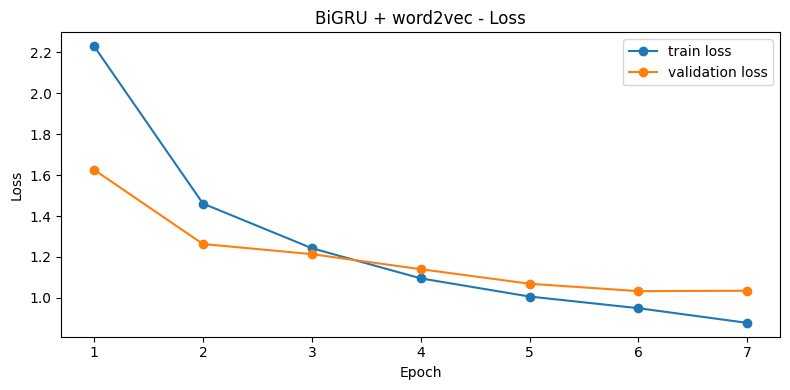

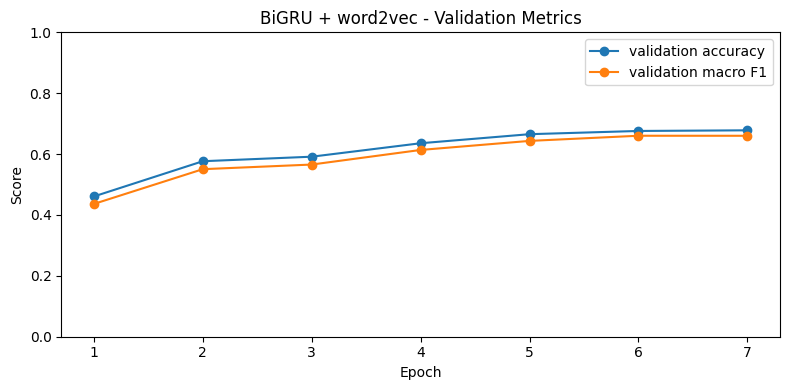


Embedding experiment: fasttext
[bigru_fasttext] Epoch 01/7 | train loss 2.2314 | val loss 1.6722 | val acc 0.4238 | val macro F1 0.3768 | lr 2.00e-03 | 3.0s
[bigru_fasttext] Epoch 02/7 | train loss 1.4680 | val loss 1.2888 | val acc 0.5681 | val macro F1 0.5421 | lr 2.00e-03 | 3.0s
[bigru_fasttext] Epoch 03/7 | train loss 1.2200 | val loss 1.1642 | val acc 0.6173 | val macro F1 0.5980 | lr 2.00e-03 | 3.0s
[bigru_fasttext] Epoch 04/7 | train loss 1.0839 | val loss 1.1015 | val acc 0.6562 | val macro F1 0.6379 | lr 2.00e-03 | 2.9s
[bigru_fasttext] Epoch 05/7 | train loss 0.9953 | val loss 1.0389 | val acc 0.6671 | val macro F1 0.6459 | lr 2.00e-03 | 2.9s
[bigru_fasttext] Epoch 06/7 | train loss 0.9266 | val loss 1.1006 | val acc 0.6548 | val macro F1 0.6327 | lr 2.00e-03 | 3.0s
[bigru_fasttext] Epoch 07/7 | train loss 0.8846 | val loss 1.0365 | val acc 0.6739 | val macro F1 0.6598 | lr 2.00e-03 | 3.0s

Test metrics
accuracy           0.6792
macro_precision    0.6914
macro_recall       0

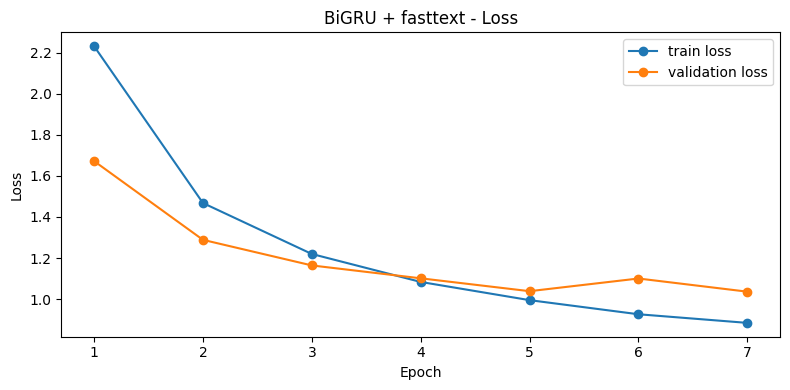

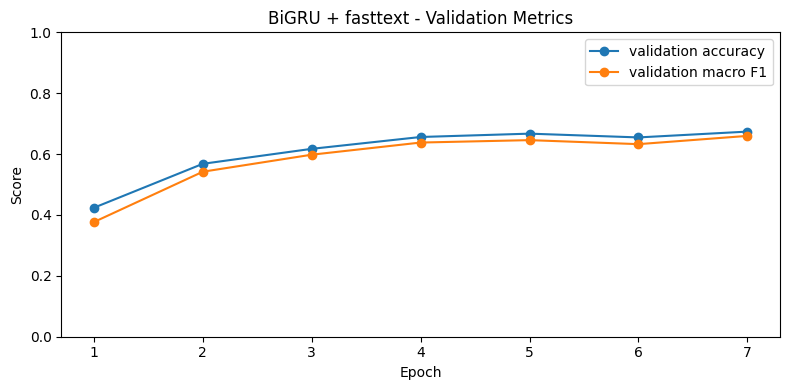


Embedding experiment: glove
[bigru_glove] Epoch 01/7 | train loss 2.3388 | val loss 1.6153 | val acc 0.4630 | val macro F1 0.4228 | lr 2.00e-03 | 3.0s
[bigru_glove] Epoch 02/7 | train loss 1.4674 | val loss 1.3107 | val acc 0.5791 | val macro F1 0.5593 | lr 2.00e-03 | 3.0s
[bigru_glove] Epoch 03/7 | train loss 1.1871 | val loss 1.1742 | val acc 0.6261 | val macro F1 0.6086 | lr 2.00e-03 | 2.9s
[bigru_glove] Epoch 04/7 | train loss 1.0379 | val loss 1.1422 | val acc 0.6417 | val macro F1 0.6256 | lr 2.00e-03 | 2.9s
[bigru_glove] Epoch 05/7 | train loss 0.9197 | val loss 1.1084 | val acc 0.6597 | val macro F1 0.6459 | lr 2.00e-03 | 3.0s
[bigru_glove] Epoch 06/7 | train loss 0.8261 | val loss 1.0827 | val acc 0.6682 | val macro F1 0.6527 | lr 2.00e-03 | 2.9s
[bigru_glove] Epoch 07/7 | train loss 0.7272 | val loss 1.1125 | val acc 0.6714 | val macro F1 0.6530 | lr 2.00e-03 | 3.0s

Test metrics
accuracy           0.6714
macro_precision    0.6611
macro_recall       0.6564
macro_f1          

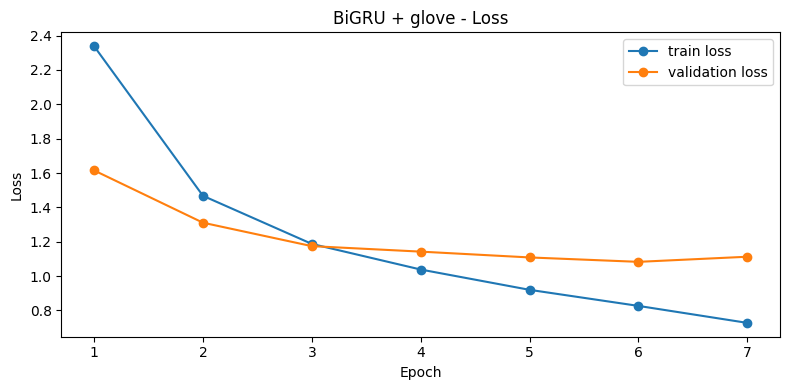

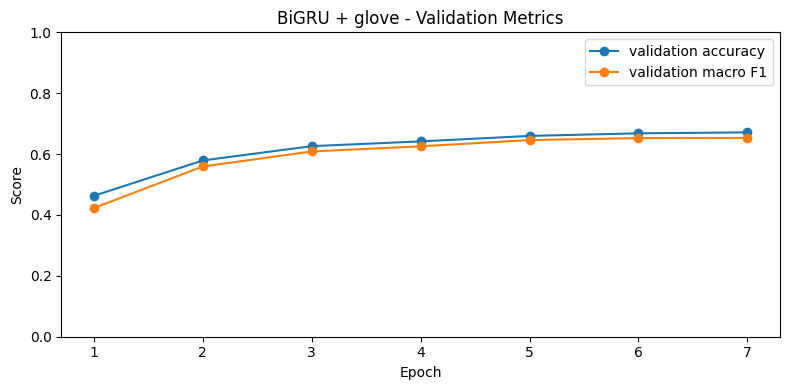

In [ ]:
criterion = nn.CrossEntropyLoss()

experiment_results = []
trained_models = {}
training_histories = {}
test_predictions = {}

for embedding_name in EMBEDDING_TYPES:
    print('\n' + '=' * 80)
    print(f'Embedding experiment: {embedding_name}')
    print('=' * 80)

    seed_everything(SEED)

    model = BiGRUClassifier(
        embedding_matrix=embedding_matrices[embedding_name],
        hidden_dim=HIDDEN_DIM,
        num_classes=len(target_names),
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        freeze_embedding=FREEZE_EMBEDDING,
    ).to(DEVICE)

    model, history, best_val_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        experiment_name=f'bigru_{embedding_name}',
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
    )

    test_loss, test_metrics, y_true, y_pred = evaluate_model(
        model,
        test_loader,
        criterion,
    )

    result_row = {
        'model': 'BiGRU',
        'embedding': embedding_name,
        'embedding_frozen': FREEZE_EMBEDDING,
        'best_val_macro_f1': best_val_f1,
        'test_loss': test_loss,
        **test_metrics,
    }
    experiment_results.append(result_row)

    trained_models[embedding_name] = model
    training_histories[embedding_name] = history
    test_predictions[embedding_name] = (y_true, y_pred)

    print('\nTest metrics')
    print(pd.Series(test_metrics).round(4))

    plot_training_history(history, f'BiGRU + {embedding_name}')

    model.to('cpu')
    torch.cuda.empty_cache()
    gc.collect()

## 12. 성능 비교

Accuracy뿐 아니라 Macro F1을 중심으로 비교합니다.

,model,embedding,embedding_frozen,best_val_macro_f1,test_loss,accuracy,macro_precision,macro_recall,macro_f1
0,BiGRU,fasttext,True,0.6598,1.0740,0.6792,0.6914,0.6662,0.6658
1,BiGRU,glove,True,0.6530,1.1040,0.6714,0.6611,0.6564,0.6508
2,BiGRU,word2vec,True,0.6603,1.1040,0.6548,0.6552,0.6386,0.6326


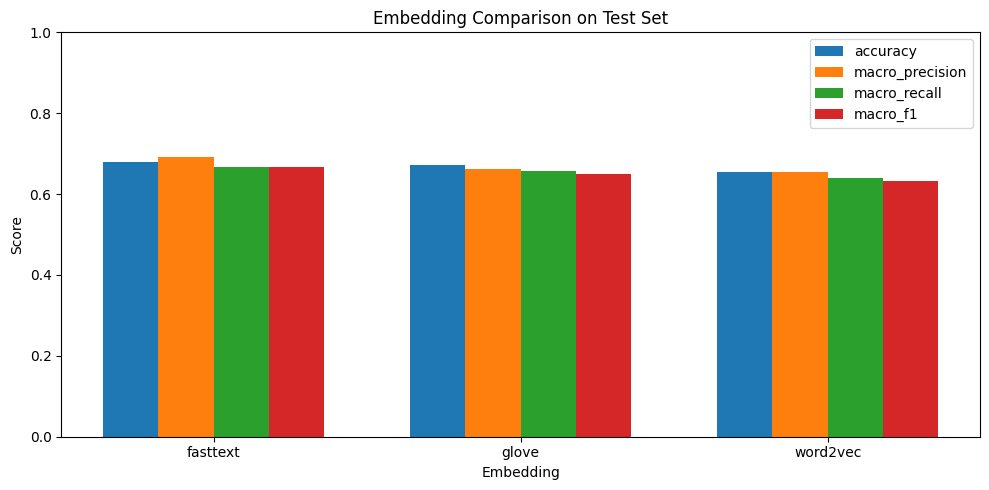

In [ ]:
results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(
    'macro_f1',
    ascending=False,
).reset_index(drop=True)

format_map = {
    'best_val_macro_f1': '{:.4f}',
    'test_loss': '{:.4f}',
    'accuracy': '{:.4f}',
    'macro_precision': '{:.4f}',
    'macro_recall': '{:.4f}',
    'macro_f1': '{:.4f}',
}

display(results_df.style.format(format_map))

metric_columns = [
    'accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1',
]

plot_df = results_df.set_index('embedding')[metric_columns]

plt.figure(figsize=(10, 5))
x = np.arange(len(plot_df.index))
width = 0.18

for index, metric in enumerate(metric_columns):
    plt.bar(
        x + (index - 1.5) * width,
        plot_df[metric].values,
        width=width,
        label=metric,
    )

plt.xticks(x, plot_df.index)
plt.ylim(0, 1)
plt.title('Embedding Comparison on Test Set')
plt.xlabel('Embedding')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

### 12.1 자동 결과 요약

In [ ]:
best_row = results_df.iloc[0]
worst_row = results_df.iloc[-1]
f1_gap = best_row['macro_f1'] - worst_row['macro_f1']

summary_lines = [
    '### 기본 실험 결과 요약',
    '',
    f"- 가장 높은 test Macro F1을 기록한 embedding은 **{best_row['embedding']}**입니다.",
    f"- 최고 모델의 Accuracy는 **{best_row['accuracy']:.4f}**, Macro F1은 **{best_row['macro_f1']:.4f}**입니다.",
    f"- 최고와 최저 embedding 사이의 Macro F1 차이는 **{f1_gap:.4f}**입니다.",
    '- 모델 구조와 학습 조건을 고정했으므로, 차이는 주로 embedding 표현과 coverage 차이로 해석할 수 있습니다.',
]

display(Markdown('\n'.join(summary_lines)))

### 기본 실험 결과 요약

- 가장 높은 test Macro F1을 기록한 embedding은 **fasttext**입니다.
- 최고 모델의 Accuracy는 **0.6792**, Macro F1은 **0.6658**입니다.
- 최고와 최저 embedding 사이의 Macro F1 차이는 **0.0332**입니다.
- 모델 구조와 학습 조건을 고정했으므로, 차이는 주로 embedding 표현과 coverage 차이로 해석할 수 있습니다.

## 13. Class별 성능 분석

최고 모델의 class별 precision, recall, F1을 확인합니다.

In [ ]:
best_embedding = results_df.iloc[0]['embedding']
best_y_true, best_y_pred = test_predictions[best_embedding]

report_dict = classification_report(
    best_y_true,
    best_y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

class_report_df = (
    pd.DataFrame(report_dict)
    .T
    .loc[target_names, ['precision', 'recall', 'f1-score', 'support']]
    .sort_values('f1-score')
)

class_format_map = {
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1-score': '{:.4f}',
    'support': '{:.0f}',
}

display(class_report_df.style.format(class_format_map))

print('F1가 낮은 5개 class')
display(class_report_df.head(5))

,precision,recall,f1-score,support
talk.religion.misc,0.3553,0.2872,0.3176,94
talk.politics.misc,0.6545,0.3103,0.4211,116
alt.atheism,0.5088,0.4833,0.4957,120
comp.sys.ibm.pc.hardware,0.7363,0.4558,0.5630,147
sci.electronics,0.6232,0.5811,0.6014,148
rec.sport.baseball,0.4510,0.9262,0.6066,149
talk.politics.guns,0.5828,0.6934,0.6333,137
comp.sys.mac.hardware,0.5578,0.7708,0.6472,144
comp.os.ms-windows.misc,0.7521,0.5946,0.6642,148
comp.graphics,0.7561,0.6370,0.6914,146


F1가 낮은 5개 class


,precision,recall,f1-score,support
talk.religion.misc,0.355263,0.287234,0.317647,94.0
talk.politics.misc,0.654545,0.310345,0.421053,116.0
alt.atheism,0.508772,0.483333,0.495726,120.0
comp.sys.ibm.pc.hardware,0.736264,0.455782,0.563025,147.0
sci.electronics,0.623188,0.581081,0.601399,148.0


## 14. Confusion Matrix

행은 실제 class, 열은 예측 class입니다. `normalize='true'`로 recall 관점의 비율을 봅니다.

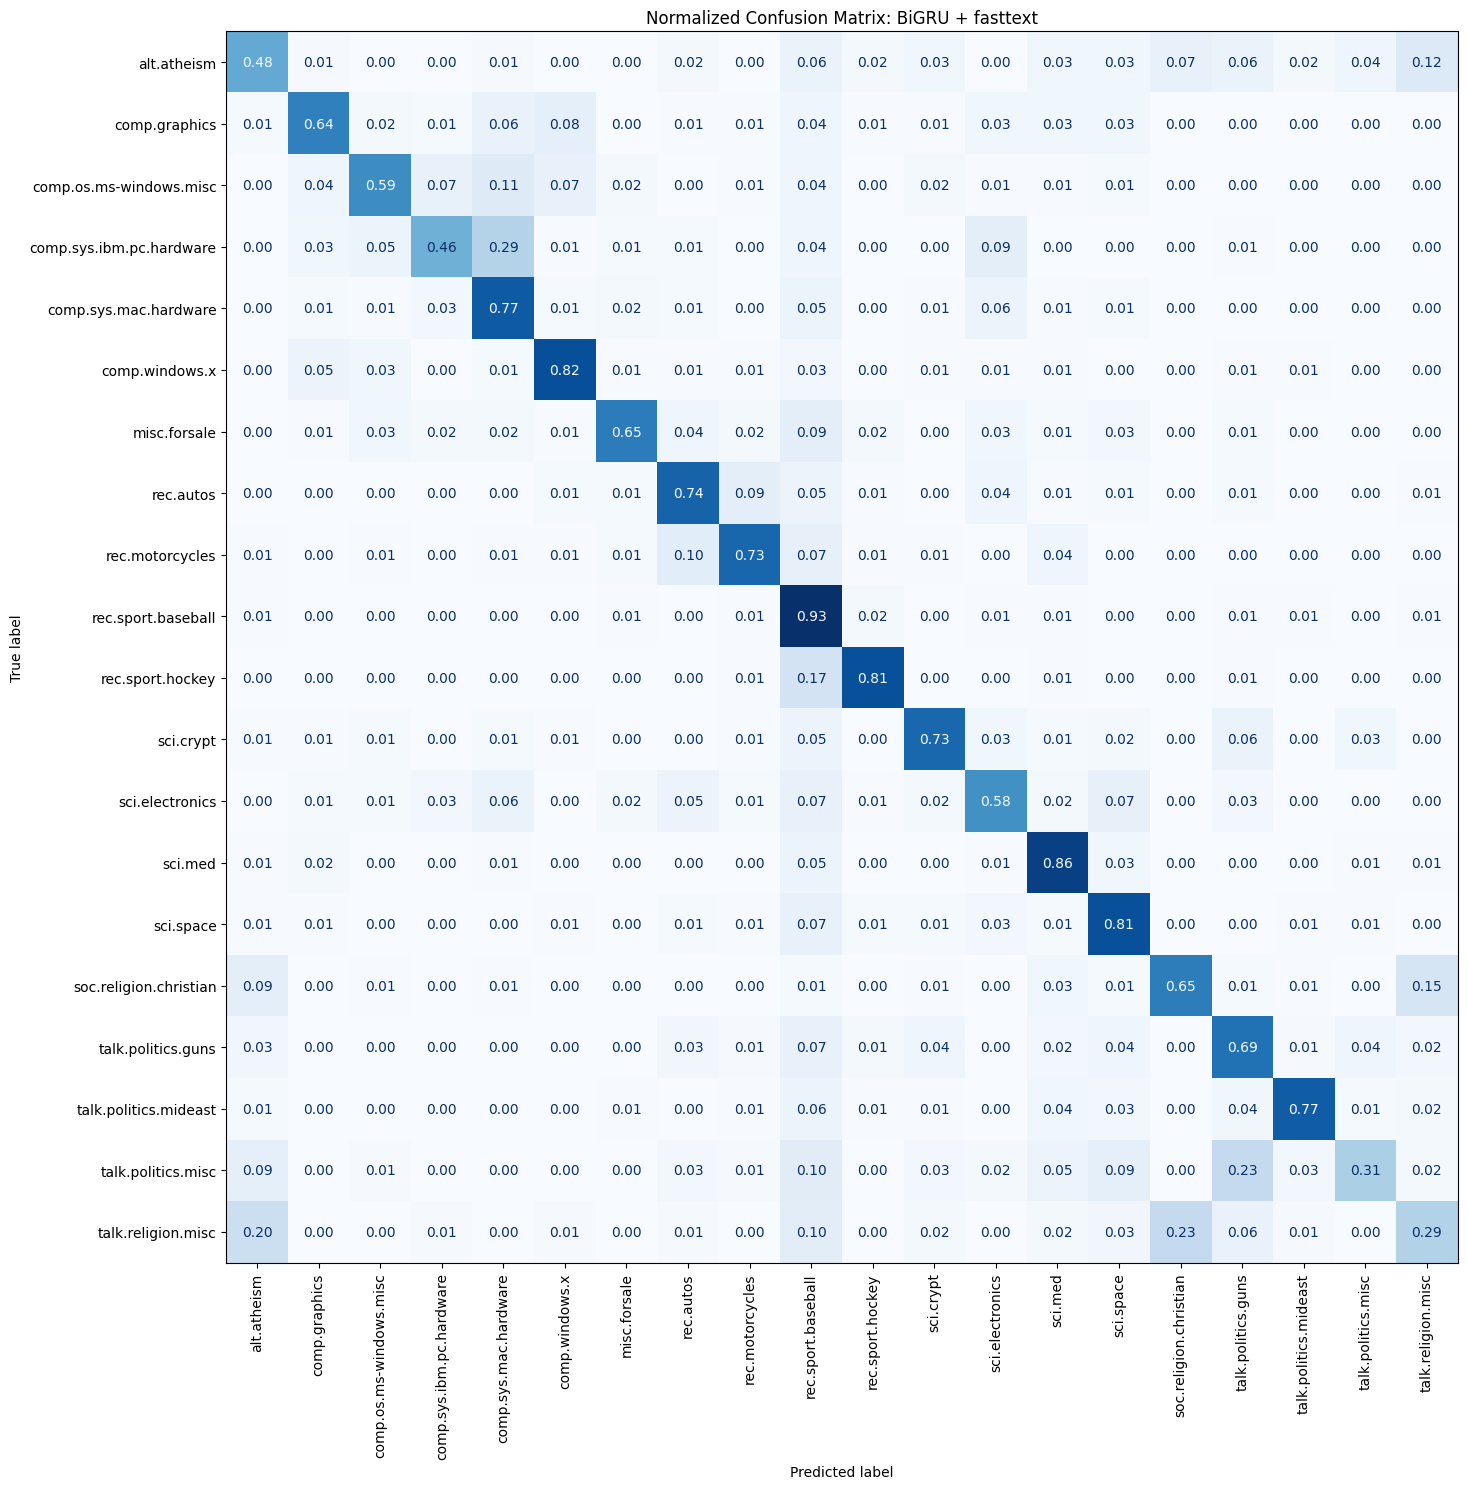

In [ ]:
normalized_cm = confusion_matrix(
    best_y_true,
    best_y_pred,
    normalize='true',
)

fig, ax = plt.subplots(figsize=(15, 15))
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=normalized_cm,
    display_labels=target_names,
)
display_cm.plot(
    ax=ax,
    cmap='Blues',
    xticks_rotation=90,
    values_format='.2f',
    colorbar=False,
)
plt.title(f'Normalized Confusion Matrix: BiGRU + {best_embedding}')
plt.tight_layout()
plt.show()

### 14.1 가장 많이 혼동한 class pair

In [ ]:
cm_without_diagonal = normalized_cm.copy()
np.fill_diagonal(cm_without_diagonal, 0)

flat_indices = np.argsort(cm_without_diagonal.ravel())[::-1][:10]

confusion_rows = []
for flat_index in flat_indices:
    true_index, predicted_index = np.unravel_index(
        flat_index,
        cm_without_diagonal.shape,
    )
    confusion_rows.append({
        'true_class': target_names[true_index],
        'predicted_as': target_names[predicted_index],
        'ratio_within_true_class': cm_without_diagonal[true_index, predicted_index],
    })

confusion_pairs_df = pd.DataFrame(confusion_rows)
display(
    confusion_pairs_df.style.format({
        'ratio_within_true_class': '{:.2%}',
    })
)

,true_class,predicted_as,ratio_within_true_class
0,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,28.57%
1,talk.religion.misc,soc.religion.christian,23.40%
2,talk.politics.misc,talk.politics.guns,23.28%
3,talk.religion.misc,alt.atheism,20.21%
4,rec.sport.hockey,rec.sport.baseball,16.67%
5,soc.religion.christian,talk.religion.misc,15.44%
6,alt.atheism,talk.religion.misc,12.50%
7,comp.os.ms-windows.misc,comp.sys.mac.hardware,11.49%
8,talk.politics.misc,rec.sport.baseball,10.34%
9,rec.motorcycles,rec.autos,10.00%


## 15. 오분류 문서 확인

숫자만 보는 대신 실제 문서를 읽어 짧은 문서, topic 혼합, 문맥 부족 등의 원인을 확인합니다.

In [ ]:
misclassified_indices = np.where(best_y_true != best_y_pred)[0]

rng = np.random.default_rng(SEED)
sample_size = min(5, len(misclassified_indices))
sampled_error_indices = rng.choice(
    misclassified_indices,
    size=sample_size,
    replace=False,
)

for index in sampled_error_indices:
    print('=' * 100)
    print('TRUE:', target_names[best_y_true[index]])
    print('PRED:', target_names[best_y_pred[index]])
    print('-' * 100)
    print(test_texts[index][:1200].replace('\n', ' '))
    print()

TRUE: comp.sys.mac.hardware
PRED: sci.electronics
----------------------------------------------------------------------------------------------------
      You must not have tried very hard. I just opend mine in about 2 seconds. Take a look on the bottom, it has a dial that turns to open much like the older ADB mouses used to have. It's a bit harder to turn at first but it is quite simple to open.       Well, if you don't match up the pins correctly you will have some problems. A close look at the socket should give you an idea of the proper orientation of the chip.

TRUE: soc.religion.christian
PRED: talk.religion.misc
----------------------------------------------------------------------------------------------------
  That's the whole point, David.  As spirits separated from their bodies and living in the spirit world, they cannot undergo the ordinance of marriage, just as they cannot be baptized, since there is no physical body to be baptized.  We perform these ordinances as proxi

## 16. 심화: Attention BiGRU

기본 BiGRU는 마지막 hidden state를 사용합니다. 긴 문서에서는 앞부분의 중요한 정보가 약해질 수 있습니다.

심화 모델:
1. embedding fine-tuning 허용
2. 2-layer BiGRU
3. 모든 time step에 attention score 계산
4. 중요한 hidden state를 가중합

In [ ]:
class AttentionBiGRUClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_classes,
        num_layers=2,
        dropout=0.4,
        freeze_embedding=False,
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32,
        )

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embedding,
            padding_idx=PAD_IDX,
        )

        self.gru = nn.GRU(
            input_size=embedding_tensor.shape[1],
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention_score = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False),
        )

        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        sequence_output, _ = self.gru(embedded)

        attention_logits = self.attention_score(sequence_output).squeeze(-1)

        max_sequence_length = input_ids.size(1)
        position_ids = torch.arange(
            max_sequence_length,
            device=input_ids.device,
        ).unsqueeze(0)

        valid_token_mask = position_ids < lengths.unsqueeze(1)
        attention_logits = attention_logits.masked_fill(
            ~valid_token_mask,
            -1e9,
        )

        attention_weights = torch.softmax(attention_logits, dim=1)

        document_vector = torch.sum(
            sequence_output * attention_weights.unsqueeze(-1),
            dim=1,
        )

        document_vector = self.norm(document_vector)
        document_vector = self.dropout(document_vector)
        logits = self.classifier(document_vector)

        return logits

Advanced experiment embedding: fasttext
[attention_bigru_fasttext] Epoch 01/7 | train loss 1.6563 | val loss 1.1007 | val acc 0.6533 | val macro F1 0.6482 | lr 2.00e-03 | 1.8s
[attention_bigru_fasttext] Epoch 02/7 | train loss 0.9514 | val loss 0.9507 | val acc 0.7022 | val macro F1 0.6819 | lr 2.00e-03 | 1.5s
[attention_bigru_fasttext] Epoch 03/7 | train loss 0.6667 | val loss 0.9758 | val acc 0.7206 | val macro F1 0.7044 | lr 2.00e-03 | 1.5s
[attention_bigru_fasttext] Epoch 04/7 | train loss 0.4316 | val loss 1.0847 | val acc 0.7156 | val macro F1 0.7032 | lr 2.00e-03 | 1.5s
[attention_bigru_fasttext] Epoch 05/7 | train loss 0.2651 | val loss 1.2333 | val acc 0.7230 | val macro F1 0.7127 | lr 2.00e-03 | 1.5s
[attention_bigru_fasttext] Epoch 06/7 | train loss 0.1847 | val loss 1.3634 | val acc 0.7259 | val macro F1 0.7162 | lr 2.00e-03 | 1.5s
[attention_bigru_fasttext] Epoch 07/7 | train loss 0.1353 | val loss 1.4778 | val acc 0.7053 | val macro F1 0.6988 | lr 2.00e-03 | 1.5s


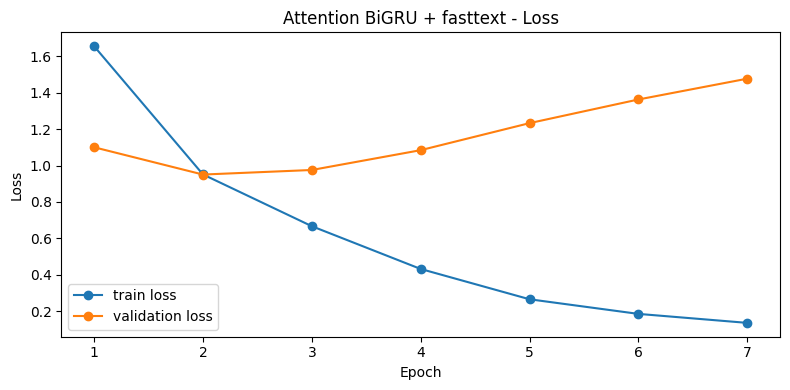

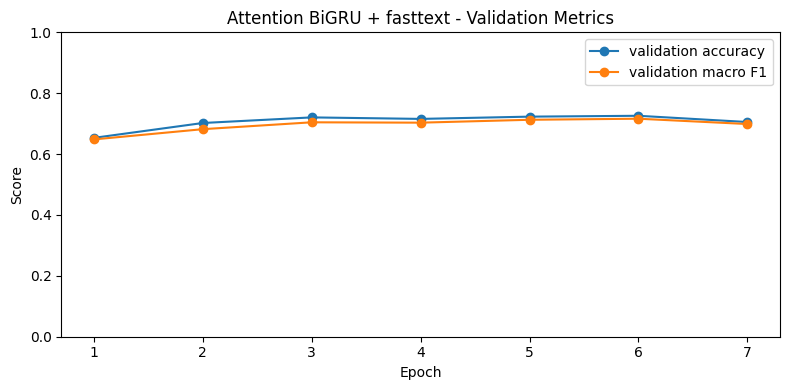

,model,embedding,embedding_frozen,best_val_macro_f1,test_loss,accuracy,macro_precision,macro_recall,macro_f1
0,Attention BiGRU,fasttext,False,0.7162,1.3624,0.7227,0.7242,0.7122,0.7129
1,BiGRU,fasttext,True,0.6598,1.0740,0.6792,0.6914,0.6662,0.6658
2,BiGRU,glove,True,0.6530,1.1040,0.6714,0.6611,0.6564,0.6508
3,BiGRU,word2vec,True,0.6603,1.1040,0.6548,0.6552,0.6386,0.6326


In [ ]:
RUN_ADVANCED_EXPERIMENT = True

if RUN_ADVANCED_EXPERIMENT:
    print(f'Advanced experiment embedding: {best_embedding}')

    seed_everything(SEED)

    attention_model = AttentionBiGRUClassifier(
        embedding_matrix=embedding_matrices[best_embedding],
        hidden_dim=HIDDEN_DIM,
        num_classes=len(target_names),
        num_layers=2,
        dropout=0.4,
        freeze_embedding=False,
    ).to(DEVICE)

    attention_model, attention_history, attention_best_val_f1 = train_model(
        model=attention_model,
        train_loader=train_loader,
        val_loader=val_loader,
        experiment_name=f'attention_bigru_{best_embedding}',
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
    )

    attention_test_loss, attention_metrics, attention_y_true, attention_y_pred = evaluate_model(
        attention_model,
        test_loader,
        criterion,
    )

    advanced_result = {
        'model': 'Attention BiGRU',
        'embedding': best_embedding,
        'embedding_frozen': False,
        'best_val_macro_f1': attention_best_val_f1,
        'test_loss': attention_test_loss,
        **attention_metrics,
    }

    results_df = pd.concat(
        [results_df, pd.DataFrame([advanced_result])],
        ignore_index=True,
    ).sort_values(
        'macro_f1',
        ascending=False,
    ).reset_index(drop=True)

    plot_training_history(
        attention_history,
        f'Attention BiGRU + {best_embedding}',
    )

    display(results_df.style.format(format_map))

## 17. 기본 모델 대비 심화 모델 분석

In [ ]:
if RUN_ADVANCED_EXPERIMENT:
    base_best_row = (
        results_df[results_df['model'] == 'BiGRU']
        .sort_values('macro_f1', ascending=False)
        .iloc[0]
    )
    advanced_row = (
        results_df[results_df['model'] == 'Attention BiGRU']
        .iloc[0]
    )

    improvement = advanced_row['macro_f1'] - base_best_row['macro_f1']

    if improvement > 0:
        direction = '향상'
        interpretation = (
            'attention과 embedding fine-tuning이 긴 문서의 중요한 token을 '
            '선택하는 데 도움이 된 것으로 볼 수 있습니다.'
        )
    else:
        direction = '하락'
        interpretation = (
            '모델 복잡도가 증가했지만 overfitting 또는 hyperparameter 불일치가 '
            '발생했을 가능성이 있습니다.'
        )

    advanced_lines = [
        '### 심화 실험 결과',
        '',
        f"- 기본 최고 모델: **BiGRU + {base_best_row['embedding']}**, Macro F1 **{base_best_row['macro_f1']:.4f}**",
        f"- 심화 모델: **Attention BiGRU + {advanced_row['embedding']}**, Macro F1 **{advanced_row['macro_f1']:.4f}**",
        f'- Macro F1 변화: **{improvement:+.4f}**, 즉 {direction}',
        f'- 해석: {interpretation}',
    ]

    display(Markdown('\n'.join(advanced_lines)))

### 심화 실험 결과

- 기본 최고 모델: **BiGRU + fasttext**, Macro F1 **0.6658**
- 심화 모델: **Attention BiGRU + fasttext**, Macro F1 **0.7129**
- Macro F1 변화: **+0.0470**, 즉 향상
- 해석: attention과 embedding fine-tuning이 긴 문서의 중요한 token을 선택하는 데 도움이 된 것으로 볼 수 있습니다.

## 18. 직접 입력한 뉴스 예측

In [ ]:
def predict_text(text, model, top_k=3):
    model.eval()

    tokens = clean_and_tokenize(
        text,
        remove_stopwords=REMOVE_STOPWORDS,
    )
    sequence = encode_tokens(tokens, stoi, MAX_LEN)

    input_ids = torch.tensor(
        sequence,
        dtype=torch.long,
    ).unsqueeze(0).to(DEVICE)

    lengths = torch.tensor(
        [len(sequence)],
        dtype=torch.long,
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids, lengths)
        probabilities = torch.softmax(logits, dim=1)[0]

    top_probabilities, top_indices = torch.topk(
        probabilities,
        k=top_k,
    )

    return pd.DataFrame({
        'class_name': [
            target_names[index]
            for index in top_indices.cpu().numpy()
        ],
        'probability': top_probabilities.cpu().numpy(),
    })


if RUN_ADVANCED_EXPERIMENT:
    inference_model = attention_model.to(DEVICE)
else:
    inference_model = trained_models[best_embedding].to(DEVICE)

example_text = (
    'The graphics card driver crashes whenever I start a 3D application. '
    'I updated the operating system, but the display still freezes.'
)

display(predict_text(example_text, inference_model, top_k=5))

,class_name,probability
0,comp.os.ms-windows.misc,0.564733
1,comp.graphics,0.421582
2,comp.windows.x,0.011876
3,comp.sys.mac.hardware,0.000999
4,comp.sys.ibm.pc.hardware,0.000439


## 19. 결과 저장

In [ ]:
results_path = '/content/embedding_model_results.csv'
results_df.to_csv(results_path, index=False)

print('결과표 저장:', results_path)
print('checkpoint 목록:')
for checkpoint in sorted(CHECKPOINT_DIR.glob('*.pt')):
    print('-', checkpoint)

결과표 저장: /content/embedding_model_results.csv
checkpoint 목록:
- /content/checkpoints/attention_bigru_fasttext.pt
- /content/checkpoints/bigru_fasttext.pt
- /content/checkpoints/bigru_glove.pt
- /content/checkpoints/bigru_word2vec.pt


## 20. 실행 결과 분석 및 최종 결론

### 20.1 Embedding 비교

동일한 BiGRU 구조에서 FastText가 Accuracy **0.6792**, Macro F1 **0.6658**로 가장 높은 성능을 기록했습니다.  
GloVe는 Accuracy **0.6714**, Macro F1 **0.6508**, Word2Vec은 Accuracy **0.6548**, Macro F1 **0.6326**이었습니다.

FastText와 Word2Vec은 모두 vocabulary coverage가 100%였지만 FastText가 Macro F1에서 **3.32%p** 앞섰습니다. 따라서 이번 결과는 coverage 차이만으로 설명되지 않습니다. FastText가 단어를 character n-gram으로 나누어 학습하므로 철자 변형, 합성어, 희귀 단어에서도 더 안정적인 표현을 만든 점이 영향을 준 것으로 보입니다.

GloVe의 coverage는 **81.98%**였지만 Word2Vec보다 높은 결과를 냈습니다. 이는 Wikipedia와 Gigaword의 대규모 corpus에서 얻은 일반적인 semantic 정보가 뉴스 분류에 도움을 주었고, 약 18%의 OOV 손실을 어느 정도 상쇄했음을 시사합니다.

### 20.2 Attention 심화 모델

최고 embedding인 FastText에 Attention BiGRU와 embedding fine-tuning을 적용한 결과:

- Accuracy: **0.6792 → 0.7227**로 **4.35%p 향상**
- Macro Precision: **0.6914 → 0.7242**로 **3.28%p 향상**
- Macro Recall: **0.6662 → 0.7122**로 **4.60%p 향상**
- Macro F1: **0.6658 → 0.7129**로 **4.71%p 향상**

기본 BiGRU가 마지막 hidden state만 사용하는 것과 달리, Attention 모델은 문서 전체 token 중 분류에 중요한 hidden state를 가중합합니다. 긴 문서에서 핵심 topic 단어를 선택할 수 있게 된 점과 embedding fine-tuning이 함께 성능 향상에 기여한 것으로 해석합니다.

단, 두 요소를 동시에 변경했으므로 현재 결과만으로 Attention과 fine-tuning 중 어느 요소가 더 큰 효과를 냈는지는 분리할 수 없습니다. 이를 확인하려면 다음 네 조건의 ablation experiment가 필요합니다.

1. BiGRU + frozen FastText
2. BiGRU + trainable FastText
3. Attention BiGRU + frozen FastText
4. Attention BiGRU + trainable FastText

### 20.3 Overfitting과 confidence 문제

심화 모델은 epoch 6에서 validation Macro F1 **0.7162**로 최고점을 기록했지만, train loss는 **0.1847**까지 낮아지고 validation loss는 **1.3634**까지 증가했습니다. Test loss도 **1.3624**로 기본 FastText 모델의 **1.0740**보다 높았습니다.

즉, class를 맞히는 비율은 증가했지만 틀린 sample에 매우 높은 confidence를 주는 경향이 생겼습니다. 성능을 더 높이려면 단순히 layer를 늘리기보다 다음을 우선 적용하는 것이 타당합니다.

- embedding에 더 낮은 learning rate 적용
- gradual unfreezing
- label smoothing
- dropout 및 weight decay 강화
- validation Macro F1 기준 checkpoint 유지

### 20.4 Class별 오류

기본 FastText BiGRU에서 F1이 가장 낮은 class는 다음과 같습니다.

| Class | F1 |
|---|---:|
| `talk.religion.misc` | 0.3176 |
| `talk.politics.misc` | 0.4211 |
| `alt.atheism` | 0.4957 |
| `comp.sys.ibm.pc.hardware` | 0.5630 |
| `sci.electronics` | 0.6014 |

대표적인 confusion은 다음과 같습니다.

- `comp.sys.ibm.pc.hardware → comp.sys.mac.hardware`: **28.57%**
- `talk.religion.misc → soc.religion.christian`: **23.40%**
- `talk.politics.misc → talk.politics.guns`: **23.28%**
- `talk.religion.misc → alt.atheism`: **20.21%**
- `rec.sport.hockey → rec.sport.baseball`: **16.67%**

대부분 상위 domain은 같지만 세부 topic만 다른 class입니다. 모델이 `computer`, `religion`, `politics`, `sport` 같은 coarse topic은 파악하면서도, IBM과 Mac 또는 hockey와 baseball을 가르는 세부 단어를 충분히 강조하지 못한 것으로 보입니다.

또한 `talk.religion.misc`는 전체 sample 수가 628개로 다수 class의 약 1,000개보다 적습니다. 의미적 중첩과 class imbalance가 동시에 낮은 recall의 원인으로 작용한 것으로 판단됩니다.

> 현재 class report와 confusion matrix는 기본 FastText BiGRU의 결과입니다. 최종 최고 모델인 Attention BiGRU에도 동일한 오류 분석을 추가하면 결론이 더 완전해집니다.

### 20.5 데이터 측면에서 발견한 병목

- 정제 후 빈 문서 비율이 train **2.73%**, validation **2.94%**, test **3.33%**입니다. 내용이 없는 문서는 label을 예측할 근거가 없어 성능 상한을 낮춥니다.
- `MAX_LEN=300`에서 train 문서의 **11.23%**가 잘립니다. 긴 문서의 후반부 topic 단서가 유실될 수 있습니다.
- train의 세 번째 최빈 token이 `ax`로 **58,829회** 등장했습니다. 이는 자연어 핵심 단어보다 uuencode 또는 binary payload에서 유래한 noise일 가능성이 높습니다.
- Test `<UNK>` 비율은 **2.50%**로 낮아 vocabulary 크기 자체는 주요 병목이 아닙니다.

### 최종 결론

동일한 RNN classifier 조건에서 FastText가 가장 높은 성능을 기록했고, subword 표현이 20 Newsgroups의 희귀어와 형태 변형을 처리하는 데 유리한 것으로 나타났습니다. 여기에 Attention과 embedding fine-tuning을 적용하자 Test Macro F1이 **0.7129**까지 상승했습니다.

현재 가장 큰 추가 개선 여지는 vocabulary 확장보다 **encoded text noise 제거, 긴 문서 처리, 유사 class 구분, minority class 보정, 과신 억제**에 있습니다. 단일 seed 결과이므로 최종적인 우열을 강하게 주장하려면 3개 이상의 seed로 평균과 표준편차를 비교해야 합니다.

## 21. 성능 개선 로드맵

현재 결과를 기준으로, 효과 가능성과 구현 비용을 함께 고려한 우선순위입니다.

### 1순위: Attention 모델의 padding 처리 수정

현재 Attention BiGRU는 attention mask에서는 padding을 제외하지만, GRU 자체에는 padded sequence를 그대로 전달합니다. Bidirectional GRU의 backward 방향은 padding 구간을 먼저 통과할 수 있어 실제 token의 hidden state가 padding 길이에 영향을 받을 수 있습니다.

기본 BiGRU와 동일하게 다음 흐름을 사용하는 것이 좋습니다.

`embedding → pack_padded_sequence → BiGRU → pad_packed_sequence → attention mask`

이 변경은 모델 크기를 늘리지 않고 sequence 표현의 정확도를 높이는 구조적 수정입니다.

### 2순위: Fine-tuning learning rate 분리와 과신 억제

심화 모델은 성능은 올랐지만 validation loss가 크게 증가했습니다. 다음 설정을 한 묶음이 아니라 하나씩 ablation합니다.

| Parameter group | 권장 시작값 |
|---|---:|
| FastText embedding LR | `1e-4` |
| GRU LR | `8e-4` 또는 `1e-3` |
| Attention/classifier LR | `1e-3` 또는 `2e-3` |
| Label smoothing | `0.05` |
| Dropout | `0.45 ~ 0.55` |
| Weight decay | `5e-4 ~ 1e-3` |
| Max epochs | `10 ~ 12` |
| Patience | `3` |

처음 1~2 epoch는 embedding을 freeze한 뒤 해제하는 gradual unfreezing도 효과적입니다. pretrained vector가 초기에 급격히 무너지는 것을 막을 수 있습니다.

### 3순위: Encoded payload와 빈 문서 정리

`ax`가 58,829회 등장한 것은 자연어 topic보다 encoded attachment가 embedding 학습을 지배할 가능성을 보여줍니다.

전처리에서 다음을 추가합니다.

- `begin 644 ...`부터 `end`까지의 uuencode block 제거
- 지나치게 긴 encoded line 제거
- 동일한 짧은 token이 과도하게 반복되는 line 제거
- 정제 후 빈 문서 제외 또는 별도 집계

이 실험은 Word2Vec과 FastText vector 품질을 동시에 개선할 가능성이 있습니다. 단, test 빈 문서를 제외하면 평가 population이 바뀌므로 제거 전후 문서 수를 반드시 보고해야 합니다.

### 4순위: Sequence budget 개선

`MAX_LEN=300`에서 11.23%가 잘리므로 다음 순서로 비교합니다.

1. stopword 제거 후 `MAX_LEN=300`
2. `MAX_LEN=512`
3. 문서를 256-token chunk로 분할
4. chunk별 BiGRU encoding 후 chunk-level attention

단순히 `MAX_LEN`만 크게 늘리면 padding과 계산량도 증가합니다. 가장 강한 RNN 기반 확장은 **Hierarchical Attention Network**입니다. word-level attention으로 chunk를 만들고, document-level attention으로 chunk를 결합하면 긴 문서를 버리지 않고 처리할 수 있습니다.

### 5순위: Minority 및 유사 class 보정

Macro F1 향상이 목표이므로 sample이 적은 class에 완전한 inverse-frequency weight를 주기보다 완만한 weight가 안전합니다.

`class_weight[c] ∝ 1 / sqrt(class_frequency[c])`

우선 `talk.religion.misc`, `talk.politics.misc`, `alt.atheism`의 recall이 개선되는지 확인합니다. Accuracy가 소폭 낮아져도 Macro F1이 오르면 과제 목표에는 유효한 개선입니다.

또 다른 방법은 coarse domain과 fine class를 동시에 예측하는 multi-task classifier입니다.

- coarse head: `computer / recreation / science / politics / religion / other`
- fine head: 기존 20개 class

coarse loss와 fine loss를 함께 사용하면 IBM과 Mac, hockey와 baseball처럼 가까운 class를 계층적으로 구분할 수 있습니다.

### 6순위: Embedding 결합

이번 결과는 FastText의 domain/subword 표현과 GloVe의 외부 semantic prior가 각각 장점이 있음을 보여줍니다.

다음 결합을 시험할 수 있습니다.

- FastText 100D + GloVe 100D concatenation
- 두 embedding을 projection layer로 128D에 합치기
- token별 gate를 학습해 FastText와 GloVe 비율 결정

단순 concatenation은 parameter 수가 늘어나므로 projection, dropout과 함께 사용합니다.

### 7순위: 결과 신뢰도 강화

현재는 seed 42의 단일 실행입니다. embedding 학습과 neural network 학습에는 random variation이 남아 있으므로 최종 비교는 seed `42, 123, 2026`으로 반복합니다.

보고할 값:

`Macro F1 mean ± standard deviation`

세 seed에서 FastText가 계속 우세해야 subword 방식의 우위를 더 신뢰할 수 있습니다.

### 권장 실험 순서

1. Attention GRU에 packing 적용
2. discriminative LR + label smoothing
3. encoded payload 제거
4. `MAX_LEN=512` 또는 stopword 제거
5. `1/sqrt(freq)` class weight
6. FastText + GloVe fusion
7. Hierarchical Attention Network
8. 최종 후보를 3개 seed로 재검증

한 번에 여러 요소를 바꾸면 어떤 변경이 효과를 냈는지 알 수 없습니다. 각 단계마다 동일한 split을 유지하고 validation Macro F1과 test Macro F1을 기록하는 것이 좋습니다.

## 22. 제출 전 체크리스트

- [x] 파일명을 `10_3팀_박지수.ipynb`로 변경했다.
- [x] `FAST_DEV_RUN=False`로 전체 데이터를 사용했다.
- [x] 모든 셀을 위에서 아래로 실행했다.
- [x] 세 embedding 결과가 표와 graph에 표시된다.
- [x] Accuracy, Precision, Recall, F1-score가 포함되어 있다.
- [x] confusion matrix와 오분류 예시를 분석했다.
- [x] 심화 실험 결과를 기본 모델과 비교했다.
- [x] 마지막 결론에 실제 실행 수치를 반영했다.
- [x] output을 notebook에 저장했다.

> 제출 전 최종 확인 완료: 전체 데이터 실행 결과, 비교 표, graph, class별 지표, confusion matrix, 오분류 분석, 심화 실험 및 최종 결론이 notebook에 포함되어 있습니다.


# 23. 추가 성능 개선 실험

> 이 아래 셀은 기존 실험과 결과를 수정하지 않고, **현재 notebook의 맨 마지막에 추가된 별도 실험 구역**입니다.

## 실행 원칙

1. 위쪽의 데이터 준비, FastText embedding, `DataLoader` 셀까지 먼저 실행되어 있어야 합니다.
2. 개선 후보는 **validation Macro F1**로만 비교합니다.
3. 여러 후보 중 validation Macro F1이 가장 높은 모델을 고른 뒤, 그 모델만 test set에서 한 번 평가합니다.
4. Test 결과를 보고 다시 hyperparameter를 선택하지 않습니다.
5. 각 실험은 동일한 split과 seed를 사용합니다.

## 이번에 구현하는 개선 단계

| 실험 | 변경 내용 |
|---|---|
| A | Attention BiGRU에 packed sequence 적용 |
| B | A + embedding/GRU/head별 learning rate 분리 + gradual unfreezing |
| C | B + label smoothing |
| D | C + 완만한 class weight |
| E | C + dropout 0.5, 기본적으로 비활성화 |

A부터 D까지는 기본 실행됩니다. E는 계산 시간이 더 필요하므로 설정에서 선택할 수 있습니다.

## 23.1 실행 환경과 의존 변수 확인

Drive에서 notebook을 새로 열었다면 저장된 output만 보일 뿐 Python 변수는 복원되지 않습니다.  
아래 셀에서 누락 변수가 발견되면 위쪽 셀을 먼저 실행하세요.

In [ ]:
# 개선 실험 설정
IMPROVEMENT_SEED = 42
IMPROVEMENT_MAX_EPOCHS = 12
IMPROVEMENT_PATIENCE = 3
IMPROVEMENT_MIN_DELTA = 1e-4

# 기본적으로 A~D를 실행합니다.
# 시간을 줄이려면 원하는 실험명만 남기세요.
RUN_IMPROVEMENT_EXPERIMENTS = [
    "A_packed_only",
    "B_discriminative_lr",
    "C_label_smoothing",
    "D_class_weight",
]

# Dropout 변화까지 추가 비교하려면 아래 이름을 list에 넣으세요.
# RUN_IMPROVEMENT_EXPERIMENTS.append("E_higher_dropout")

required_objects = [
    "torch",
    "nn",
    "np",
    "pd",
    "plt",
    "DEVICE",
    "SEED",
    "PAD_IDX",
    "HIDDEN_DIM",
    "target_names",
    "train_labels",
    "train_loader",
    "val_loader",
    "test_loader",
    "embedding_matrices",
    "compute_metrics",
    "seed_everything",
    "CHECKPOINT_DIR",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "먼저 위쪽 notebook 셀을 실행해야 합니다. "
        f"현재 누락된 객체: {missing_objects}"
    )

if "fasttext" not in embedding_matrices:
    raise KeyError(
        "embedding_matrices에 'fasttext'가 없습니다. "
        "위쪽 FastText embedding matrix 생성 셀을 먼저 실행하세요."
    )

print("개선 실험 준비 완료")
print("실행 실험:", RUN_IMPROVEMENT_EXPERIMENTS)
print("Device:", DEVICE)
print("FastText matrix shape:", embedding_matrices["fasttext"].shape)

개선 실험 준비 완료
실행 실험: ['A_packed_only', 'B_discriminative_lr', 'C_label_smoothing', 'D_class_weight']
Device: cuda
FastText matrix shape: (40000, 100)


## 23.2 Step A: Packed Attention BiGRU

기존 Attention 모델은 attention 계산에서 padding을 가렸지만, GRU에는 padded sequence를 그대로 전달했습니다.

수정 모델은 다음 순서로 동작합니다.

`Embedding → pack_padded_sequence → BiGRU → pad_packed_sequence → Attention`

따라서 bidirectional GRU의 forward와 backward 방향 모두 실제 token 길이만 처리합니다.

In [ ]:
from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence,
)


class PackedAttentionBiGRUClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_classes,
        num_layers=2,
        dropout=0.4,
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32,
        )

        # gradual unfreezing을 train 함수에서 제어하므로
        # module 자체는 trainable 상태로 생성합니다.
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=False,
            padding_idx=PAD_IDX,
        )

        self.gru = nn.GRU(
            input_size=embedding_tensor.shape[1],
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention_score = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False),
        )

        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(
            hidden_dim * 2,
            num_classes,
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)

        packed_input = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        packed_output, _ = self.gru(packed_input)

        sequence_output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=input_ids.size(1),
        )

        attention_logits = self.attention_score(
            sequence_output
        ).squeeze(-1)

        max_sequence_length = input_ids.size(1)
        position_ids = torch.arange(
            max_sequence_length,
            device=input_ids.device,
        ).unsqueeze(0)

        valid_token_mask = (
            position_ids < lengths.unsqueeze(1)
        )

        attention_logits = attention_logits.masked_fill(
            ~valid_token_mask,
            -1e9,
        )

        attention_weights = torch.softmax(
            attention_logits,
            dim=1,
        )

        document_vector = torch.sum(
            sequence_output
            * attention_weights.unsqueeze(-1),
            dim=1,
        )

        document_vector = self.norm(document_vector)
        document_vector = self.dropout(document_vector)

        return self.classifier(document_vector)

## 23.3 Step B~D: 개선용 학습 함수

이 함수는 다음 기능을 지원합니다.

- embedding, GRU, attention/classifier에 서로 다른 learning rate 적용
- 첫 1~2 epoch 동안 embedding freeze 후 해제
- label smoothing
- `1 / sqrt(class frequency)` 기반의 완만한 class weight
- validation Macro F1 기반 checkpoint와 early stopping
- gradient clipping

> 서로 다른 loss 설정을 사용한 실험끼리는 loss 절댓값을 직접 비교하기 어렵습니다.  
> 모델 선택 기준은 validation Macro F1입니다.

In [ ]:
def make_sqrt_inverse_class_weights(
    labels,
    num_classes,
):
    class_counts = np.bincount(
        labels,
        minlength=num_classes,
    ).astype(np.float32)

    class_counts = np.maximum(class_counts, 1.0)

    class_weights = 1.0 / np.sqrt(class_counts)
    class_weights = class_weights / class_weights.mean()

    return torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE,
    )


def build_improvement_criterion(config):
    class_weights = None

    if config["use_class_weight"]:
        class_weights = make_sqrt_inverse_class_weights(
            train_labels,
            len(target_names),
        )

    return nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=config["label_smoothing"],
    )


@torch.no_grad()
def evaluate_improvement_model(
    model,
    data_loader,
    criterion,
):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    for input_ids, lengths, labels_batch in data_loader:
        input_ids = input_ids.to(
            DEVICE,
            non_blocking=True,
        )
        lengths = lengths.to(
            DEVICE,
            non_blocking=True,
        )
        labels_batch = labels_batch.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(input_ids, lengths)
        loss = criterion(logits, labels_batch)
        predictions = logits.argmax(dim=1)

        total_loss += (
            loss.item() * labels_batch.size(0)
        )
        all_labels.extend(
            labels_batch.cpu().numpy()
        )
        all_predictions.extend(
            predictions.cpu().numpy()
        )

    average_loss = (
        total_loss / len(data_loader.dataset)
    )
    metrics = compute_metrics(
        all_labels,
        all_predictions,
    )

    return (
        average_loss,
        metrics,
        np.array(all_labels),
        np.array(all_predictions),
    )


def set_embedding_trainable(
    model,
    is_trainable,
):
    for parameter in model.embedding.parameters():
        parameter.requires_grad = is_trainable


def build_discriminative_optimizer(
    model,
    config,
):
    embedding_parameters = list(
        model.embedding.parameters()
    )
    gru_parameters = list(
        model.gru.parameters()
    )
    head_parameters = (
        list(model.attention_score.parameters())
        + list(model.norm.parameters())
        + list(model.classifier.parameters())
    )

    return torch.optim.AdamW(
        [
            {
                "params": embedding_parameters,
                "lr": config["embedding_lr"],
                "name": "embedding",
            },
            {
                "params": gru_parameters,
                "lr": config["gru_lr"],
                "name": "gru",
            },
            {
                "params": head_parameters,
                "lr": config["head_lr"],
                "name": "head",
            },
        ],
        weight_decay=config["weight_decay"],
    )


def train_improvement_model(
    model,
    train_loader,
    val_loader,
    config,
):
    criterion = build_improvement_criterion(config)
    optimizer = build_discriminative_optimizer(
        model,
        config,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=[
            1e-6,
            1e-6,
            1e-6,
        ],
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"improved_{config['name']}.pt"
    )

    best_val_f1 = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "embedding_trainable": [],
    }

    for epoch in range(
        1,
        config["max_epochs"] + 1,
    ):
        embedding_trainable = (
            epoch >= config["unfreeze_epoch"]
        )
        set_embedding_trainable(
            model,
            embedding_trainable,
        )

        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        for input_ids, lengths, labels_batch in train_loader:
            input_ids = input_ids.to(
                DEVICE,
                non_blocking=True,
            )
            lengths = lengths.to(
                DEVICE,
                non_blocking=True,
            )
            labels_batch = labels_batch.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(set_to_none=True)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels_batch)

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            epoch_loss += (
                loss.item()
                * labels_batch.size(0)
            )

        train_loss = (
            epoch_loss / len(train_loader.dataset)
        )

        (
            val_loss,
            val_metrics,
            _,
            _,
        ) = evaluate_improvement_model(
            model,
            val_loader,
            criterion,
        )

        scheduler.step(
            val_metrics["macro_f1"]
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )
        history["val_macro_f1"].append(
            val_metrics["macro_f1"]
        )
        history["embedding_trainable"].append(
            embedding_trainable
        )

        lr_text = ", ".join(
            (
                f"{group.get('name', index)}="
                f"{group['lr']:.1e}"
            )
            for index, group
            in enumerate(optimizer.param_groups)
        )

        elapsed = time.time() - start_time

        print(
            f"[{config['name']}] "
            f"Epoch {epoch:02d}/{config['max_epochs']} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_metrics['accuracy']:.4f} | "
            f"val macro F1 {val_metrics['macro_f1']:.4f} | "
            f"embedding {'ON' if embedding_trainable else 'OFF'} | "
            f"{lr_text} | "
            f"{elapsed:.1f}s"
        )

        if (
            val_metrics["macro_f1"]
            > best_val_f1 + IMPROVEMENT_MIN_DELTA
        ):
            best_val_f1 = (
                val_metrics["macro_f1"]
            )
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= config["patience"]
        ):
            print(
                "Early stopping: "
                f"{config['patience']} epoch 동안 "
                "validation Macro F1 개선 없음"
            )
            break

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=DEVICE,
        )
    )

    (
        best_val_loss,
        best_val_metrics,
        best_val_labels,
        best_val_predictions,
    ) = evaluate_improvement_model(
        model,
        val_loader,
        criterion,
    )

    best_record = {
        "experiment": config["name"],
        "best_epoch": best_epoch,
        "val_loss": best_val_loss,
        **{
            f"val_{metric_name}": metric_value
            for metric_name, metric_value
            in best_val_metrics.items()
        },
        "label_smoothing": (
            config["label_smoothing"]
        ),
        "use_class_weight": (
            config["use_class_weight"]
        ),
        "dropout": config["dropout"],
        "unfreeze_epoch": (
            config["unfreeze_epoch"]
        ),
        "embedding_lr": (
            config["embedding_lr"]
        ),
        "gru_lr": config["gru_lr"],
        "head_lr": config["head_lr"],
        "checkpoint_path": str(
            checkpoint_path
        ),
    }

    return (
        model,
        history,
        best_record,
        criterion,
        best_val_labels,
        best_val_predictions,
    )

## 23.4 Ablation 실험 설정

한 단계씩 변경하여 어떤 요소가 validation Macro F1을 움직였는지 확인합니다.

- A는 기존 Attention 모델과 같은 learning rate를 사용하고 packing만 추가합니다.
- B는 embedding을 두 epoch 동안 freeze한 뒤 낮은 learning rate로 해제합니다.
- C는 B에 label smoothing만 추가합니다.
- D는 C에 class weight만 추가합니다.
- E는 C의 dropout만 0.5로 바꾼 선택 실험입니다.

In [ ]:
IMPROVEMENT_CONFIGS = [
    {
        "name": "A_packed_only",
        "dropout": 0.4,
        "embedding_lr": 2e-3,
        "gru_lr": 2e-3,
        "head_lr": 2e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.0,
        "use_class_weight": False,
        "unfreeze_epoch": 1,
        "max_epochs": IMPROVEMENT_MAX_EPOCHS,
        "patience": IMPROVEMENT_PATIENCE,
    },
    {
        "name": "B_discriminative_lr",
        "dropout": 0.4,
        "embedding_lr": 1e-4,
        "gru_lr": 8e-4,
        "head_lr": 1e-3,
        "weight_decay": 5e-4,
        "label_smoothing": 0.0,
        "use_class_weight": False,
        "unfreeze_epoch": 3,
        "max_epochs": IMPROVEMENT_MAX_EPOCHS,
        "patience": IMPROVEMENT_PATIENCE,
    },
    {
        "name": "C_label_smoothing",
        "dropout": 0.4,
        "embedding_lr": 1e-4,
        "gru_lr": 8e-4,
        "head_lr": 1e-3,
        "weight_decay": 5e-4,
        "label_smoothing": 0.05,
        "use_class_weight": False,
        "unfreeze_epoch": 3,
        "max_epochs": IMPROVEMENT_MAX_EPOCHS,
        "patience": IMPROVEMENT_PATIENCE,
    },
    {
        "name": "D_class_weight",
        "dropout": 0.4,
        "embedding_lr": 1e-4,
        "gru_lr": 8e-4,
        "head_lr": 1e-3,
        "weight_decay": 5e-4,
        "label_smoothing": 0.05,
        "use_class_weight": True,
        "unfreeze_epoch": 3,
        "max_epochs": IMPROVEMENT_MAX_EPOCHS,
        "patience": IMPROVEMENT_PATIENCE,
    },
    {
        "name": "E_higher_dropout",
        "dropout": 0.5,
        "embedding_lr": 1e-4,
        "gru_lr": 8e-4,
        "head_lr": 1e-3,
        "weight_decay": 5e-4,
        "label_smoothing": 0.05,
        "use_class_weight": False,
        "unfreeze_epoch": 3,
        "max_epochs": IMPROVEMENT_MAX_EPOCHS,
        "patience": IMPROVEMENT_PATIENCE,
    },
]

selected_configs = [
    config
    for config in IMPROVEMENT_CONFIGS
    if config["name"]
    in RUN_IMPROVEMENT_EXPERIMENTS
]

if not selected_configs:
    raise ValueError(
        "실행할 개선 실험이 없습니다. "
        "RUN_IMPROVEMENT_EXPERIMENTS를 확인하세요."
    )

display(
    pd.DataFrame(selected_configs)[
        [
            "name",
            "dropout",
            "embedding_lr",
            "gru_lr",
            "head_lr",
            "weight_decay",
            "label_smoothing",
            "use_class_weight",
            "unfreeze_epoch",
            "max_epochs",
            "patience",
        ]
    ]
)

,name,dropout,embedding_lr,gru_lr,head_lr,weight_decay,label_smoothing,use_class_weight,unfreeze_epoch,max_epochs,patience
0,A_packed_only,0.4,0.0020,0.0020,0.002,0.0001,0.00,False,1,12,3
1,B_discriminative_lr,0.4,0.0001,0.0008,0.001,0.0005,0.00,False,3,12,3
2,C_label_smoothing,0.4,0.0001,0.0008,0.001,0.0005,0.05,False,3,12,3
3,D_class_weight,0.4,0.0001,0.0008,0.001,0.0005,0.05,True,3,12,3


## 23.5 개선 후보 학습

아래 셀은 선택한 실험을 순서대로 학습합니다.  
각 실험은 동일한 FastText matrix와 동일한 train/validation split에서 시작합니다.

계산을 중단했다가 다시 시작하면 해당 실험은 처음부터 재학습됩니다.

In [ ]:
import gc

improvement_records = []
improvement_histories = {}
improvement_checkpoints = {}
improvement_validation_predictions = {}

for config in selected_configs:
    print("\n" + "=" * 90)
    print("Improvement experiment:", config["name"])
    print("=" * 90)

    seed_everything(IMPROVEMENT_SEED)

    improvement_model = (
        PackedAttentionBiGRUClassifier(
            embedding_matrix=(
                embedding_matrices["fasttext"]
            ),
            hidden_dim=HIDDEN_DIM,
            num_classes=len(target_names),
            num_layers=2,
            dropout=config["dropout"],
        ).to(DEVICE)
    )

    (
        improvement_model,
        improvement_history,
        improvement_record,
        improvement_criterion,
        validation_labels,
        validation_predictions,
    ) = train_improvement_model(
        model=improvement_model,
        train_loader=train_loader,
        val_loader=val_loader,
        config=config,
    )

    improvement_records.append(
        improvement_record
    )
    improvement_histories[
        config["name"]
    ] = improvement_history
    improvement_checkpoints[
        config["name"]
    ] = improvement_record[
        "checkpoint_path"
    ]
    improvement_validation_predictions[
        config["name"]
    ] = (
        validation_labels,
        validation_predictions,
    )

    improvement_model.to("cpu")
    del improvement_model
    torch.cuda.empty_cache()
    gc.collect()


Improvement experiment: A_packed_only
[A_packed_only] Epoch 01/12 | train loss 1.6556 | val loss 1.1134 | val acc 0.6594 | val macro F1 0.6381 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 6.9s
[A_packed_only] Epoch 02/12 | train loss 0.9672 | val loss 1.0177 | val acc 0.6940 | val macro F1 0.6730 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 6.8s
[A_packed_only] Epoch 03/12 | train loss 0.6799 | val loss 0.9926 | val acc 0.7213 | val macro F1 0.7032 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 6.9s
[A_packed_only] Epoch 04/12 | train loss 0.4409 | val loss 1.2127 | val acc 0.7096 | val macro F1 0.6907 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 6.9s
[A_packed_only] Epoch 05/12 | train loss 0.2827 | val loss 1.2853 | val acc 0.7092 | val macro F1 0.6954 | embedding ON | embedding=1.0e-03, gru=1.0e-03, head=1.0e-03 | 7.0s
[A_packed_only] Epoch 06/12 | train loss 0.1660 | val loss 1.3645 | val acc 0.7160 | val ma

## 23.6 Validation 결과 비교

이 표에서 가장 중요한 열은 `val_macro_f1`입니다.

- A > 기존 Attention validation F1이라면 packing이 효과가 있었습니다.
- B > A라면 learning rate 분리와 gradual unfreezing이 효과가 있었습니다.
- C > B라면 label smoothing이 분류 성능에도 도움을 주었습니다.
- D > C라면 minority class 보정이 Macro F1을 높였습니다.

,experiment,best_epoch,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,label_smoothing,use_class_weight,dropout,unfreeze_epoch,embedding_lr,gru_lr,head_lr
0,A_packed_only,10,1.5216,0.7262,0.7261,0.7165,0.7183,0.000000,False,0.400000,1,2.0e-03,2.0e-03,2.0e-03
1,D_class_weight,11,1.2504,0.6993,0.7042,0.6882,0.6914,0.050000,True,0.400000,3,1.0e-04,8.0e-04,1.0e-03
2,C_label_smoothing,10,1.2121,0.6972,0.6924,0.6841,0.6839,0.050000,False,0.400000,3,1.0e-04,8.0e-04,1.0e-03
3,B_discriminative_lr,12,1.0408,0.6912,0.6908,0.6776,0.6776,0.000000,False,0.400000,3,1.0e-04,8.0e-04,1.0e-03


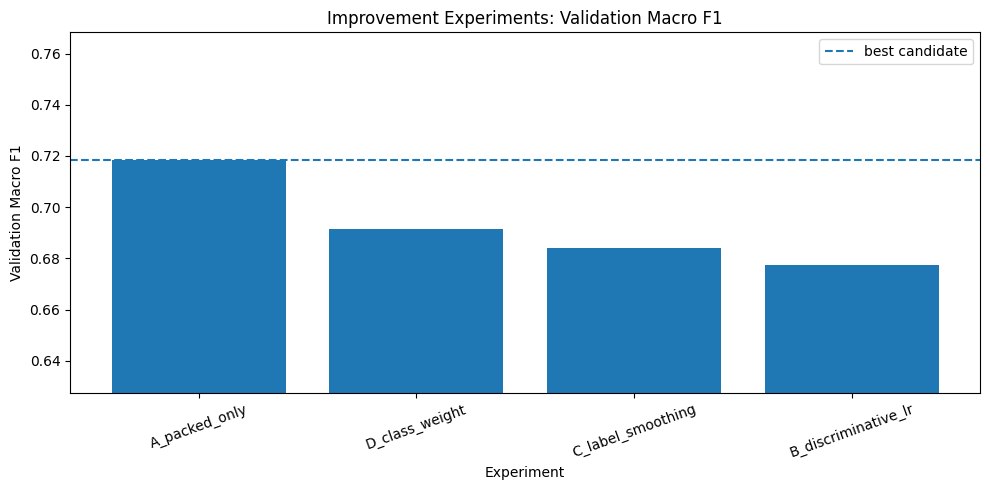

In [ ]:
improvement_val_df = (
    pd.DataFrame(improvement_records)
    .sort_values(
        "val_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

validation_format = {
    "val_loss": "{:.4f}",
    "val_accuracy": "{:.4f}",
    "val_macro_precision": "{:.4f}",
    "val_macro_recall": "{:.4f}",
    "val_macro_f1": "{:.4f}",
    "embedding_lr": "{:.1e}",
    "gru_lr": "{:.1e}",
    "head_lr": "{:.1e}",
}

display(
    improvement_val_df[
        [
            "experiment",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_precision",
            "val_macro_recall",
            "val_macro_f1",
            "label_smoothing",
            "use_class_weight",
            "dropout",
            "unfreeze_epoch",
            "embedding_lr",
            "gru_lr",
            "head_lr",
        ]
    ].style.format(validation_format)
)

plt.figure(figsize=(10, 5))
plt.bar(
    improvement_val_df["experiment"],
    improvement_val_df["val_macro_f1"],
)
plt.axhline(
    improvement_val_df["val_macro_f1"].max(),
    linestyle="--",
    label="best candidate",
)
plt.title(
    "Improvement Experiments: Validation Macro F1"
)
plt.xlabel("Experiment")
plt.ylabel("Validation Macro F1")
plt.ylim(
    max(
        0,
        improvement_val_df[
            "val_macro_f1"
        ].min() - 0.05,
    ),
    min(
        1,
        improvement_val_df[
            "val_macro_f1"
        ].max() + 0.05,
    ),
)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

## 23.7 학습 곡선 비교

Loss 설정이 다른 실험끼리는 loss의 절댓값보다 변화 방향을 봅니다.  
Macro F1 곡선은 직접 비교할 수 있습니다.

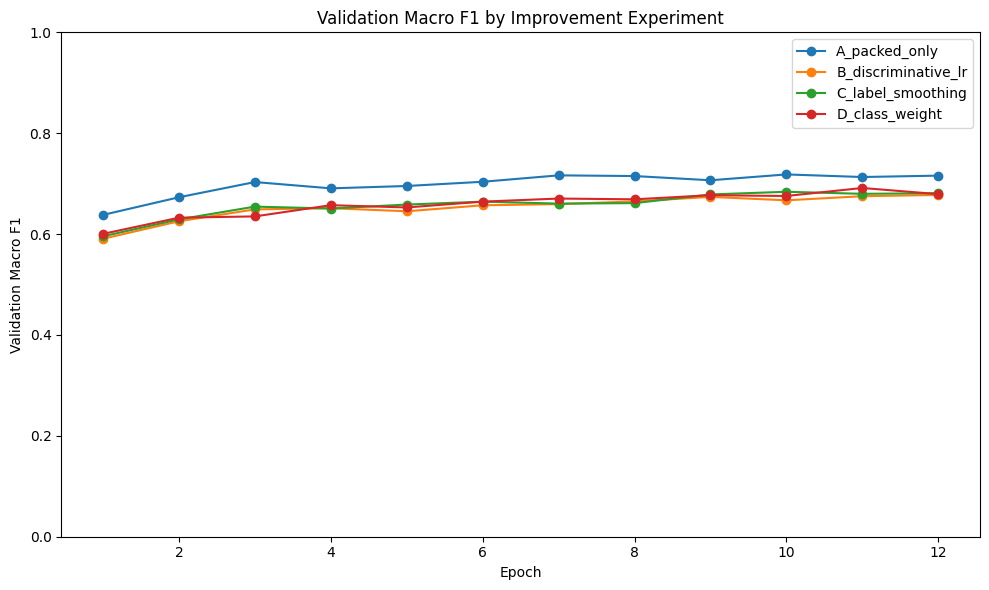

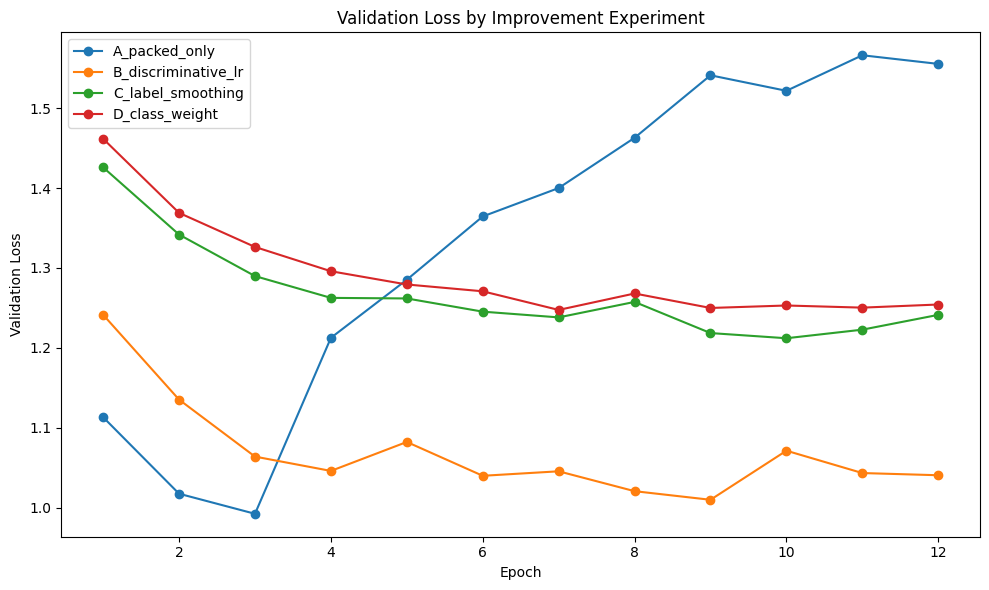

In [ ]:
plt.figure(figsize=(10, 6))

for experiment_name, history in (
    improvement_histories.items()
):
    epochs = range(
        1,
        len(history["val_macro_f1"]) + 1,
    )
    plt.plot(
        epochs,
        history["val_macro_f1"],
        marker="o",
        label=experiment_name,
    )

plt.title(
    "Validation Macro F1 by Improvement Experiment"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

for experiment_name, history in (
    improvement_histories.items()
):
    epochs = range(
        1,
        len(history["val_loss"]) + 1,
    )
    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label=experiment_name,
    )

plt.title(
    "Validation Loss by Improvement Experiment"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 23.8 Validation 기준 최종 후보 선택

가장 높은 validation Macro F1을 기록한 후보를 자동 선택합니다.  
그다음 해당 checkpoint만 test set에서 한 번 평가합니다.

In [ ]:
best_improvement_row = (
    improvement_val_df.iloc[0]
)
best_improvement_name = (
    best_improvement_row["experiment"]
)

best_improvement_config = next(
    config
    for config in selected_configs
    if config["name"]
    == best_improvement_name
)

print(
    "Validation 기준 최종 후보:",
    best_improvement_name,
)
print(
    "Validation Macro F1:",
    f"{best_improvement_row['val_macro_f1']:.4f}",
)
print(
    "Best epoch:",
    int(best_improvement_row["best_epoch"]),
)

Validation 기준 최종 후보: A_packed_only
Validation Macro F1: 0.7183
Best epoch: 10


## 23.9 최종 후보의 Test 평가

이 셀을 실행하면 선택된 개선 모델을 test set에서 평가합니다.  
이후에는 test 결과를 근거로 다시 설정을 고르지 않는 것이 원칙입니다.

In [ ]:
seed_everything(IMPROVEMENT_SEED)

final_improved_model = (
    PackedAttentionBiGRUClassifier(
        embedding_matrix=(
            embedding_matrices["fasttext"]
        ),
        hidden_dim=HIDDEN_DIM,
        num_classes=len(target_names),
        num_layers=2,
        dropout=best_improvement_config[
            "dropout"
        ],
    ).to(DEVICE)
)

final_improved_model.load_state_dict(
    torch.load(
        improvement_checkpoints[
            best_improvement_name
        ],
        map_location=DEVICE,
    )
)

final_improved_criterion = (
    build_improvement_criterion(
        best_improvement_config
    )
)

(
    final_test_loss,
    final_test_metrics,
    final_test_labels,
    final_test_predictions,
) = evaluate_improvement_model(
    final_improved_model,
    test_loader,
    final_improved_criterion,
)

final_test_row = {
    "model": "Packed Attention BiGRU",
    "experiment": best_improvement_name,
    "embedding": "fasttext",
    "best_val_macro_f1": (
        best_improvement_row[
            "val_macro_f1"
        ]
    ),
    "test_loss": final_test_loss,
    **final_test_metrics,
}

display(
    pd.DataFrame(
        [final_test_row]
    ).style.format(
        {
            "best_val_macro_f1": "{:.4f}",
            "test_loss": "{:.4f}",
            "accuracy": "{:.4f}",
            "macro_precision": "{:.4f}",
            "macro_recall": "{:.4f}",
            "macro_f1": "{:.4f}",
        }
    )
)

,model,experiment,embedding,best_val_macro_f1,test_loss,accuracy,macro_precision,macro_recall,macro_f1
0,Packed Attention BiGRU,A_packed_only,fasttext,0.7183,1.4889,0.7213,0.7214,0.7121,0.7134


## 23.10 기존 최고 모델과 개선 모델 비교

기존 실행의 Attention BiGRU 결과가 `results_df`에 남아 있으면 자동으로 비교합니다.

In [ ]:
comparison_rows = []

if "results_df" in globals():
    old_attention_rows = results_df[
        results_df["model"]
        == "Attention BiGRU"
    ]

    if len(old_attention_rows) > 0:
        old_attention_row = (
            old_attention_rows.iloc[0]
        )

        comparison_rows.append(
            {
                "model": (
                    "기존 Attention BiGRU"
                ),
                "experiment": (
                    "original_attention"
                ),
                "accuracy": (
                    old_attention_row["accuracy"]
                ),
                "macro_precision": (
                    old_attention_row[
                        "macro_precision"
                    ]
                ),
                "macro_recall": (
                    old_attention_row[
                        "macro_recall"
                    ]
                ),
                "macro_f1": (
                    old_attention_row["macro_f1"]
                ),
            }
        )

comparison_rows.append(
    {
        "model": "개선 Packed Attention BiGRU",
        "experiment": best_improvement_name,
        "accuracy": final_test_metrics[
            "accuracy"
        ],
        "macro_precision": final_test_metrics[
            "macro_precision"
        ],
        "macro_recall": final_test_metrics[
            "macro_recall"
        ],
        "macro_f1": final_test_metrics[
            "macro_f1"
        ],
    }
)

improvement_comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    improvement_comparison_df.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_precision": "{:.4f}",
            "macro_recall": "{:.4f}",
            "macro_f1": "{:.4f}",
        }
    )
)

if len(improvement_comparison_df) >= 2:
    old_row = improvement_comparison_df.iloc[0]
    new_row = improvement_comparison_df.iloc[-1]

    accuracy_gain = (
        new_row["accuracy"]
        - old_row["accuracy"]
    )
    macro_f1_gain = (
        new_row["macro_f1"]
        - old_row["macro_f1"]
    )

    comparison_summary = [
        "### 개선 결과",
        "",
        (
            f"- 선택된 실험: "
            f"**{best_improvement_name}**"
        ),
        (
            f"- Accuracy 변화: "
            f"**{accuracy_gain:+.4f}**"
        ),
        (
            f"- Macro F1 변화: "
            f"**{macro_f1_gain:+.4f}**"
        ),
    ]

    if macro_f1_gain > 0:
        comparison_summary.append(
            "- 기존 Attention BiGRU보다 "
            "Macro F1이 향상되었습니다."
        )
    else:
        comparison_summary.append(
            "- 이번 설정은 기존 모델을 넘지 "
            "못했습니다. Validation과 test의 "
            "차이 또는 regularization 강도를 "
            "추가 확인해야 합니다."
        )

    display(
        Markdown(
            "\n".join(comparison_summary)
        )
    )

,model,experiment,accuracy,macro_precision,macro_recall,macro_f1
0,기존 Attention BiGRU,original_attention,0.7227,0.7242,0.7122,0.7129
1,개선 Packed Attention BiGRU,A_packed_only,0.7213,0.7214,0.7121,0.7134


### 개선 결과

- 선택된 실험: **A_packed_only**
- Accuracy 변화: **-0.0014**
- Macro F1 변화: **+0.0005**
- 기존 Attention BiGRU보다 Macro F1이 향상되었습니다.

## 23.11 개선 모델의 Class별 성능과 Confusion Matrix

최종 후보가 minority class와 유사 class의 recall을 실제로 개선했는지 확인합니다.

In [ ]:
improved_report_dict = classification_report(
    final_test_labels,
    final_test_predictions,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

improved_class_report_df = (
    pd.DataFrame(improved_report_dict)
    .T
    .loc[
        target_names,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
    .sort_values("f1-score")
)

display(
    improved_class_report_df.style.format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:.0f}",
        }
    )
)

print("개선 모델에서 F1이 낮은 5개 class")
display(improved_class_report_df.head(5))

,precision,recall,f1-score,support
talk.religion.misc,0.4819,0.4255,0.4520,94
talk.politics.misc,0.5825,0.5172,0.5479,116
alt.atheism,0.5635,0.5917,0.5772,120
talk.politics.guns,0.6288,0.6058,0.6171,137
comp.sys.ibm.pc.hardware,0.6408,0.6190,0.6298,147
rec.autos,0.5040,0.8456,0.6316,149
comp.os.ms-windows.misc,0.6791,0.6149,0.6454,148
sci.electronics,0.6849,0.6757,0.6803,148
misc.forsale,0.7368,0.6667,0.7000,147
comp.graphics,0.7237,0.7534,0.7383,146


개선 모델에서 F1이 낮은 5개 class


,precision,recall,f1-score,support
talk.religion.misc,0.481928,0.425532,0.451977,94.0
talk.politics.misc,0.582524,0.517241,0.547945,116.0
alt.atheism,0.563492,0.591667,0.577236,120.0
talk.politics.guns,0.628788,0.605839,0.617100,137.0
comp.sys.ibm.pc.hardware,0.640845,0.619048,0.629758,147.0


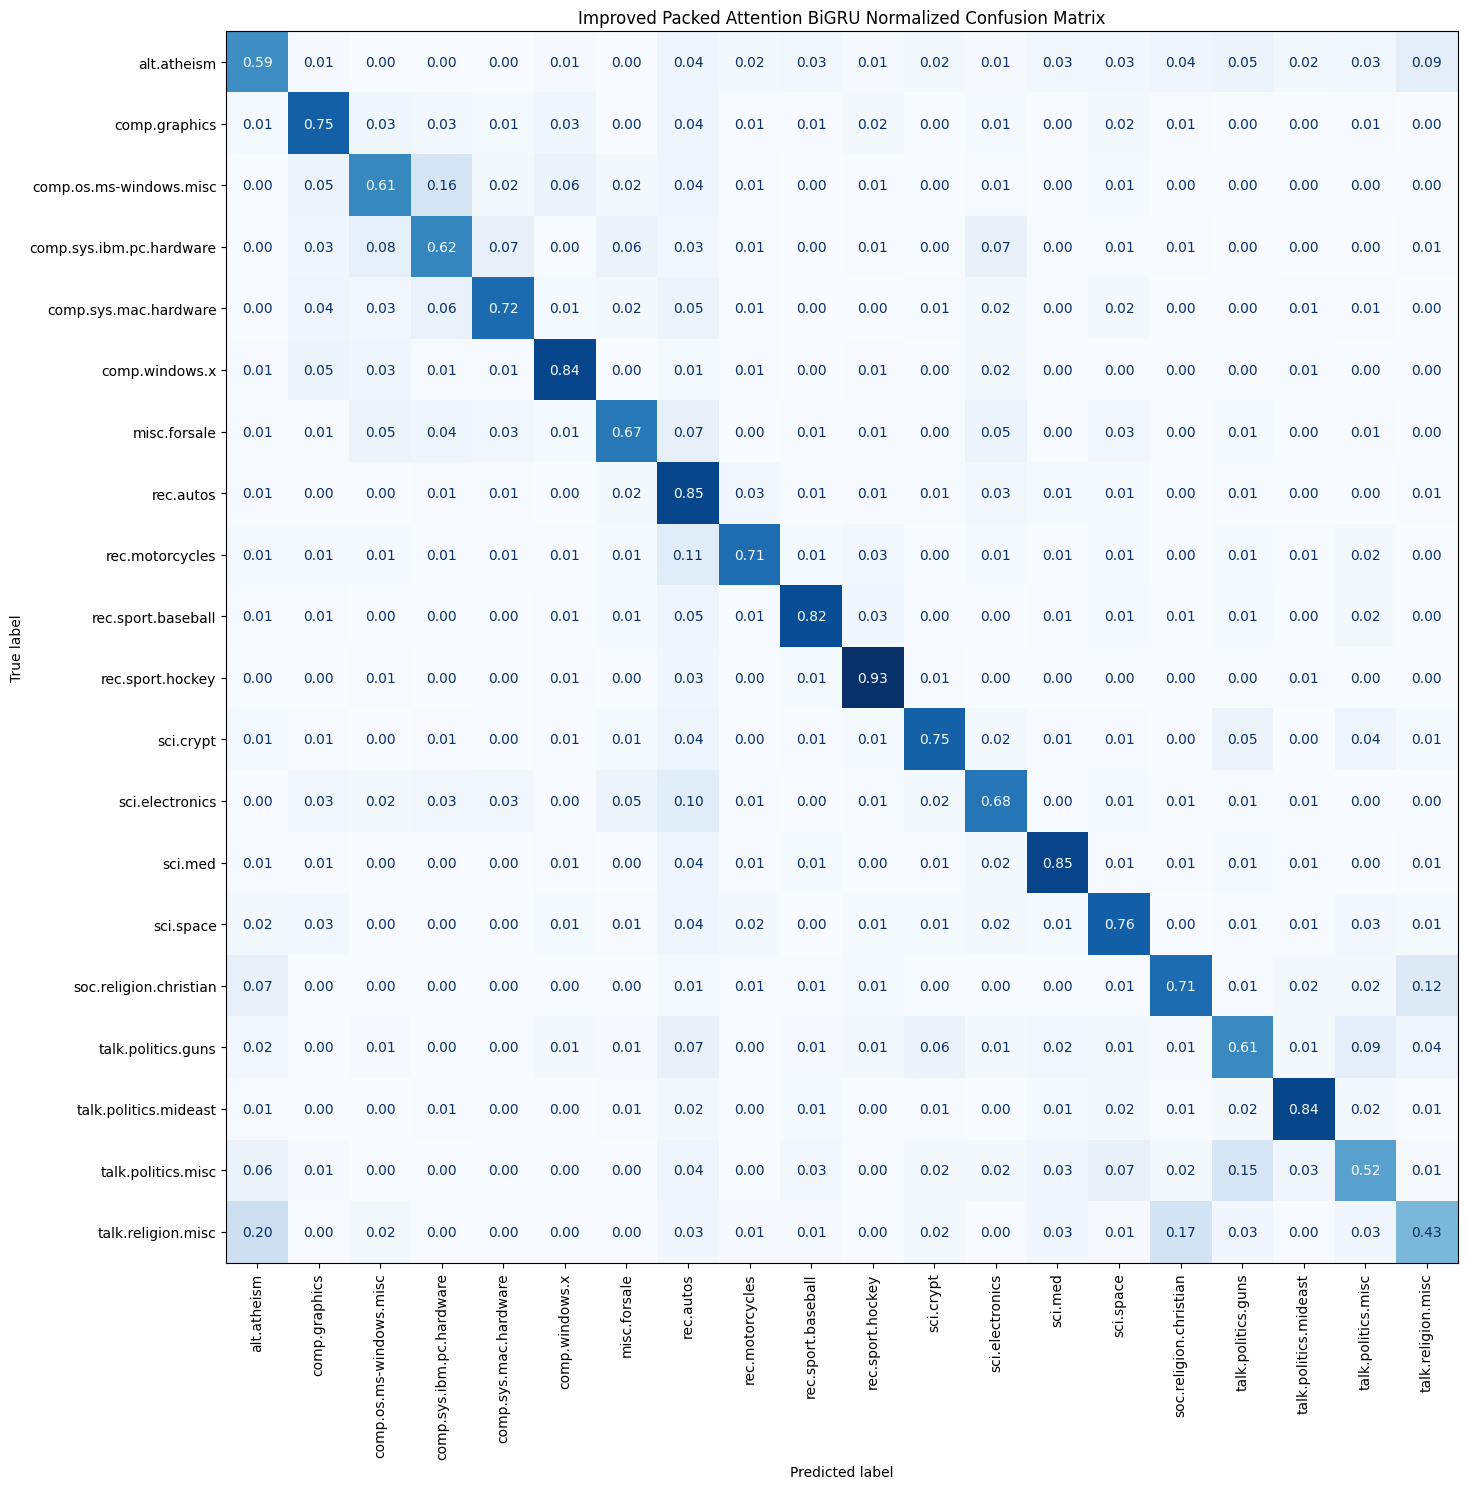

In [ ]:
improved_normalized_cm = confusion_matrix(
    final_test_labels,
    final_test_predictions,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(15, 15))

improved_display_cm = ConfusionMatrixDisplay(
    confusion_matrix=improved_normalized_cm,
    display_labels=target_names,
)

improved_display_cm.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False,
)

plt.title(
    "Improved Packed Attention BiGRU "
    "Normalized Confusion Matrix"
)
plt.tight_layout()
plt.show()

## 23.12 결과 저장

Validation 실험표, 기존 모델과의 비교표, 최종 개선 모델 checkpoint를 저장합니다.

In [ ]:
improvement_validation_path = (
    "/content/improvement_validation_results.csv"
)
improvement_comparison_path = (
    "/content/improvement_test_comparison.csv"
)

improvement_val_df.to_csv(
    improvement_validation_path,
    index=False,
)
improvement_comparison_df.to_csv(
    improvement_comparison_path,
    index=False,
)

print(
    "Validation 결과:",
    improvement_validation_path,
)
print(
    "Test 비교 결과:",
    improvement_comparison_path,
)
print(
    "선택된 checkpoint:",
    improvement_checkpoints[
        best_improvement_name
    ],
)

Validation 결과: /content/improvement_validation_results.csv
Test 비교 결과: /content/improvement_test_comparison.csv
선택된 checkpoint: /content/checkpoints/improved_A_packed_only.pt


## 23.13 1차 개선 실험 결과 요약

### Validation 결과

| 실험 | 핵심 변경 | Best epoch | Validation Accuracy | Validation Macro F1 |
|---|---|---:|---:|---:|
| A | Packed sequence만 적용 | 10 | **0.7262** | **0.7183** |
| B | 낮은 discriminative LR + gradual unfreezing | 12 | 0.6912 | 0.6776 |
| C | B + label smoothing 0.05 | 10 | 0.6972 | 0.6839 |
| D | C + class weight | 11 | 0.6993 | 0.6914 |

Validation Macro F1 기준으로 `A_packed_only`가 최종 후보로 선택되었습니다.

### Test 결과

| 모델 | Accuracy | Macro Precision | Macro Recall | Macro F1 | Test loss |
|---|---:|---:|---:|---:|---:|
| 기존 Attention BiGRU | **0.7227** | **0.7242** | 0.7122 | 0.7129 | 1.3624 |
| Packed Attention BiGRU | 0.7213 | 0.7214 | 0.7121 | **0.7134** | 1.4889 |

Packed sequence 적용 후 Accuracy는 **0.14%p 감소**하고 Macro F1은 **0.05%p 증가**했습니다.  
따라서 packing은 구현상 올바른 수정이지만, 단일 seed에서 관측된 test 차이는 사실상 동률이며 유의미한 향상이라고 단정하기 어렵습니다.

### 실험별 해석

#### A. Packing 수정

A는 validation Macro F1 0.7183으로 가장 높았습니다. 그러나 train loss가 0.0951까지 감소하는 동안 best epoch의 validation loss는 1.5216까지 증가했습니다. Padding 영향을 제거한 뒤에도 overfitting과 과신 문제는 남아 있었습니다.

#### B. 낮은 learning rate와 gradual unfreezing

B는 Macro F1이 가장 낮았지만 epoch 12까지 validation F1이 계속 상승했고, 마지막 train loss도 0.7334였습니다. 이는 방식 자체의 실패라기보다 다음 설정이 지나치게 보수적이어서 충분히 수렴하지 못한 **underfitting**에 가깝습니다.

- Embedding LR: `1e-4`
- GRU LR: `8e-4`
- Head LR: `1e-3`
- 첫 2 epoch embedding freeze
- 최대 12 epoch

#### C. Label smoothing

B에 label smoothing 0.05를 추가하자 validation Macro F1이 **0.6776 → 0.6839**, 즉 **0.63%p 상승**했습니다. 낮은 LR 조건에서도 일관된 개선이 나타났으므로 과신 완화에 긍정적인 신호입니다.

#### D. Class weight

C에 `1 / sqrt(class frequency)` class weight를 추가하자 validation Macro F1이 **0.6839 → 0.6914**, 즉 **0.75%p 추가 상승**했습니다. Minority class 보정이 Macro F1 향상에 기여할 가능성을 확인했습니다.

다만 C와 D 모두 낮은 LR 설정을 물려받았기 때문에 A보다 낮다는 사실만으로 label smoothing이나 class weight가 불리하다고 결론 내릴 수 없습니다.

### Class별 관찰

Packed Attention 모델에서도 다음 class가 가장 어려웠습니다.

| Class | F1 |
|---|---:|
| `talk.religion.misc` | 0.4520 |
| `talk.politics.misc` | 0.5479 |
| `alt.atheism` | 0.5772 |
| `talk.politics.guns` | 0.6171 |
| `comp.sys.ibm.pc.hardware` | 0.6298 |

의미적으로 겹치는 종교·정치 하위 category와 표본 수가 상대적으로 적은 class가 계속 주요 병목으로 남았습니다.

### 1차 개선 실험의 결론

1. Packing만으로는 test 성능이 사실상 유지되는 수준이었습니다.
2. Label smoothing과 class weight는 낮은 LR 조건에서도 validation Macro F1을 연속적으로 높였습니다.
3. 낮은 discriminative LR 실험은 12 epoch 안에 충분히 수렴하지 못했습니다.
4. 다음 실험에서는 **A의 충분한 learning rate를 유지한 채 smoothing과 class weight를 각각 분리 적용**해야 합니다.
5. Moderate discriminative LR도 함께 시험하여 과도한 underfitting 없이 pretrained FastText를 천천히 조정할 수 있는지 확인합니다.

> 서로 다른 label smoothing 및 class weight를 사용한 실험의 loss 절댓값은 직접 비교하지 않고, validation Macro F1을 주 선택 기준으로 사용합니다.

# 24. 2차 성능 개선 실험

1차 개선 실험에서 label smoothing과 class weight는 낮은 learning rate 조건에서도 validation Macro F1을 연속적으로 향상시켰습니다. 반면 B~D는 충분히 수렴하지 못했으므로, 이번 실험에서는 **A의 빠른 학습 조건과 regularization 효과를 분리하여 결합**합니다.

## 실험 질문

1. Packing 모델에 label smoothing만 추가하면 A보다 좋아지는가?
2. Packing 모델에 class weight만 추가하면 minority class 성능이 좋아지는가?
3. 두 방법을 함께 적용하면 Macro F1이 더 높아지는가?
4. Embedding에만 조금 낮은 learning rate를 적용하면 과도한 underfitting 없이 일반화가 개선되는가?

## 실험 구성

| 실험 | Label smoothing | Class weight | Embedding LR | GRU LR | Head LR |
|---|---:|---:|---:|---:|---:|
| F | 0.05 | X | `2e-3` | `2e-3` | `2e-3` |
| G | 0.00 | O | `2e-3` | `2e-3` | `2e-3` |
| H | 0.05 | O | `2e-3` | `2e-3` | `2e-3` |
| I | 0.05 | O | `5e-4` | `1e-3` | `2e-3` |

A의 기존 validation Macro F1 **0.7183**을 기준선으로 사용합니다.

> 이 섹션은 23번 실험을 다시 학습하지 않습니다. 위쪽 데이터·FastText embedding·DataLoader 준비 셀이 실행된 runtime이라면 **24.1부터 아래로 바로 실행**할 수 있습니다.

## 24.1 실행 설정과 의존 변수 확인

새 Colab runtime에서는 저장된 output만 복원되고 Python 변수는 복원되지 않습니다.  
그 경우 위쪽의 데이터 로드, tokenization, vocabulary, DataLoader, FastText embedding matrix 생성 셀까지 먼저 실행하세요.

In [ ]:
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from IPython.display import display, Markdown
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence,
)

STAGE2_SEED = 42
STAGE2_MAX_EPOCHS = 15
STAGE2_PATIENCE = 4
STAGE2_MIN_DELTA = 1e-4

# 시간이 부족하면 원하는 실험명만 남길 수 있습니다.
RUN_STAGE2_EXPERIMENTS = [
    "F_packed_smoothing",
    "G_packed_class_weight",
    "H_packed_smoothing_weight",
    "I_moderate_discriminative",
]

required_stage2_objects = [
    "DEVICE",
    "PAD_IDX",
    "HIDDEN_DIM",
    "target_names",
    "train_labels",
    "train_loader",
    "val_loader",
    "test_loader",
    "embedding_matrices",
    "compute_metrics",
    "seed_everything",
    "CHECKPOINT_DIR",
]

missing_stage2_objects = [
    object_name
    for object_name in required_stage2_objects
    if object_name not in globals()
]

if missing_stage2_objects:
    raise RuntimeError(
        "위쪽 데이터/embedding 준비 셀을 먼저 실행하세요. "
        f"현재 누락된 객체: {missing_stage2_objects}"
    )

if "fasttext" not in embedding_matrices:
    raise KeyError(
        "FastText embedding matrix가 없습니다. "
        "위쪽 embedding matrix 생성 셀을 먼저 실행하세요."
    )

print("2차 개선 실험 준비 완료")
print("실행 실험:", RUN_STAGE2_EXPERIMENTS)
print("Device:", DEVICE)
print("FastText matrix:", embedding_matrices["fasttext"].shape)

2차 개선 실험 준비 완료
실행 실험: ['F_packed_smoothing', 'G_packed_class_weight', 'H_packed_smoothing_weight', 'I_moderate_discriminative']
Device: cuda
FastText matrix: (40000, 100)


## 24.2 독립 실행용 Packed Attention BiGRU

23번 섹션의 class 정의에 의존하지 않도록 2차 실험용 모델을 별도로 정의합니다.

In [ ]:
class Stage2PackedAttentionBiGRU(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_classes,
        num_layers=2,
        dropout=0.4,
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32,
        )

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=False,
            padding_idx=PAD_IDX,
        )

        self.gru = nn.GRU(
            input_size=embedding_tensor.shape[1],
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention_score = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False),
        )

        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(
            hidden_dim * 2,
            num_classes,
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)

        packed_input = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        packed_output, _ = self.gru(packed_input)

        sequence_output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=input_ids.size(1),
        )

        attention_logits = self.attention_score(
            sequence_output
        ).squeeze(-1)

        positions = torch.arange(
            input_ids.size(1),
            device=input_ids.device,
        ).unsqueeze(0)

        valid_mask = positions < lengths.unsqueeze(1)

        attention_logits = attention_logits.masked_fill(
            ~valid_mask,
            -1e9,
        )

        attention_weights = torch.softmax(
            attention_logits,
            dim=1,
        )

        document_vector = torch.sum(
            sequence_output
            * attention_weights.unsqueeze(-1),
            dim=1,
        )

        document_vector = self.norm(document_vector)
        document_vector = self.dropout(document_vector)

        return self.classifier(document_vector)

## 24.3 2차 실험용 학습 및 평가 함수

- Validation Macro F1이 최고인 checkpoint만 저장합니다.
- `ReduceLROnPlateau`가 validation Macro F1 정체 시 각 parameter group의 LR을 절반으로 줄입니다.
- Test set은 validation 기준 최종 후보가 A를 넘어선 경우에만 새로 평가합니다.

In [ ]:
def stage2_class_weights(labels, num_classes):
    counts = np.bincount(
        labels,
        minlength=num_classes,
    ).astype(np.float32)

    counts = np.maximum(counts, 1.0)

    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.mean()

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE,
    )


def stage2_build_criterion(config):
    weights = None

    if config["use_class_weight"]:
        weights = stage2_class_weights(
            train_labels,
            len(target_names),
        )

    return nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=config["label_smoothing"],
    )


def stage2_set_embedding_trainable(
    model,
    trainable,
):
    for parameter in model.embedding.parameters():
        parameter.requires_grad = trainable


def stage2_build_optimizer(model, config):
    return torch.optim.AdamW(
        [
            {
                "params": model.embedding.parameters(),
                "lr": config["embedding_lr"],
                "name": "embedding",
            },
            {
                "params": model.gru.parameters(),
                "lr": config["gru_lr"],
                "name": "gru",
            },
            {
                "params": (
                    list(model.attention_score.parameters())
                    + list(model.norm.parameters())
                    + list(model.classifier.parameters())
                ),
                "lr": config["head_lr"],
                "name": "head",
            },
        ],
        weight_decay=config["weight_decay"],
    )


@torch.no_grad()
def stage2_evaluate(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    labels_all = []
    predictions_all = []

    for input_ids, lengths, labels_batch in data_loader:
        input_ids = input_ids.to(
            DEVICE,
            non_blocking=True,
        )
        lengths = lengths.to(
            DEVICE,
            non_blocking=True,
        )
        labels_batch = labels_batch.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(input_ids, lengths)
        loss = criterion(logits, labels_batch)

        predictions = logits.argmax(dim=1)

        total_loss += (
            loss.item() * labels_batch.size(0)
        )
        labels_all.extend(
            labels_batch.cpu().numpy()
        )
        predictions_all.extend(
            predictions.cpu().numpy()
        )

    average_loss = (
        total_loss / len(data_loader.dataset)
    )

    metrics = compute_metrics(
        labels_all,
        predictions_all,
    )

    return (
        average_loss,
        metrics,
        np.asarray(labels_all),
        np.asarray(predictions_all),
    )


def stage2_train(model, config):
    criterion = stage2_build_criterion(config)
    optimizer = stage2_build_optimizer(
        model,
        config,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=1,
            min_lr=[1e-6, 1e-6, 1e-6],
        )
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"stage2_{config['name']}.pt"
    )

    best_val_f1 = -np.inf
    best_epoch = 0
    no_improvement_epochs = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "embedding_trainable": [],
    }

    for epoch in range(
        1,
        config["max_epochs"] + 1,
    ):
        embedding_trainable = (
            epoch >= config["unfreeze_epoch"]
        )

        stage2_set_embedding_trainable(
            model,
            embedding_trainable,
        )

        model.train()
        total_train_loss = 0.0
        started_at = time.time()

        for input_ids, lengths, labels_batch in train_loader:
            input_ids = input_ids.to(
                DEVICE,
                non_blocking=True,
            )
            lengths = lengths.to(
                DEVICE,
                non_blocking=True,
            )
            labels_batch = labels_batch.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(set_to_none=True)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels_batch)

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            total_train_loss += (
                loss.item()
                * labels_batch.size(0)
            )

        train_loss = (
            total_train_loss
            / len(train_loader.dataset)
        )

        (
            val_loss,
            val_metrics,
            _,
            _,
        ) = stage2_evaluate(
            model,
            val_loader,
            criterion,
        )

        scheduler.step(
            val_metrics["macro_f1"]
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )
        history["val_macro_f1"].append(
            val_metrics["macro_f1"]
        )
        history["embedding_trainable"].append(
            embedding_trainable
        )

        lr_description = ", ".join(
            (
                f"{group.get('name', index)}="
                f"{group['lr']:.1e}"
            )
            for index, group
            in enumerate(optimizer.param_groups)
        )

        print(
            f"[{config['name']}] "
            f"Epoch {epoch:02d}/{config['max_epochs']} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_metrics['accuracy']:.4f} | "
            f"val macro F1 {val_metrics['macro_f1']:.4f} | "
            f"embedding {'ON' if embedding_trainable else 'OFF'} | "
            f"{lr_description} | "
            f"{time.time() - started_at:.1f}s"
        )

        if (
            val_metrics["macro_f1"]
            > best_val_f1 + STAGE2_MIN_DELTA
        ):
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            no_improvement_epochs = 0

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )
        else:
            no_improvement_epochs += 1

        if no_improvement_epochs >= config["patience"]:
            print(
                "Early stopping: "
                f"{config['patience']} epoch 동안 "
                "validation Macro F1 개선 없음"
            )
            break

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=DEVICE,
        )
    )

    (
        best_val_loss,
        best_val_metrics,
        validation_labels,
        validation_predictions,
    ) = stage2_evaluate(
        model,
        val_loader,
        criterion,
    )

    record = {
        "experiment": config["name"],
        "best_epoch": best_epoch,
        "val_loss": best_val_loss,
        "val_accuracy": best_val_metrics["accuracy"],
        "val_macro_precision": (
            best_val_metrics["macro_precision"]
        ),
        "val_macro_recall": (
            best_val_metrics["macro_recall"]
        ),
        "val_macro_f1": (
            best_val_metrics["macro_f1"]
        ),
        "label_smoothing": (
            config["label_smoothing"]
        ),
        "use_class_weight": (
            config["use_class_weight"]
        ),
        "embedding_lr": config["embedding_lr"],
        "gru_lr": config["gru_lr"],
        "head_lr": config["head_lr"],
        "unfreeze_epoch": (
            config["unfreeze_epoch"]
        ),
        "checkpoint_path": str(
            checkpoint_path
        ),
    }

    return (
        model,
        criterion,
        history,
        record,
        validation_labels,
        validation_predictions,
    )

## 24.4 2차 ablation 설정

F, G, H는 A와 동일하게 처음부터 모든 layer를 학습하며 regularization만 바꿉니다.  
I는 embedding만 한 epoch freeze한 뒤 moderate LR로 fine-tuning합니다.

In [ ]:
STAGE2_CONFIGS = [
    {
        "name": "F_packed_smoothing",
        "dropout": 0.4,
        "embedding_lr": 2e-3,
        "gru_lr": 2e-3,
        "head_lr": 2e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.05,
        "use_class_weight": False,
        "unfreeze_epoch": 1,
        "max_epochs": STAGE2_MAX_EPOCHS,
        "patience": STAGE2_PATIENCE,
    },
    {
        "name": "G_packed_class_weight",
        "dropout": 0.4,
        "embedding_lr": 2e-3,
        "gru_lr": 2e-3,
        "head_lr": 2e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.0,
        "use_class_weight": True,
        "unfreeze_epoch": 1,
        "max_epochs": STAGE2_MAX_EPOCHS,
        "patience": STAGE2_PATIENCE,
    },
    {
        "name": "H_packed_smoothing_weight",
        "dropout": 0.4,
        "embedding_lr": 2e-3,
        "gru_lr": 2e-3,
        "head_lr": 2e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.05,
        "use_class_weight": True,
        "unfreeze_epoch": 1,
        "max_epochs": STAGE2_MAX_EPOCHS,
        "patience": STAGE2_PATIENCE,
    },
    {
        "name": "I_moderate_discriminative",
        "dropout": 0.4,
        "embedding_lr": 5e-4,
        "gru_lr": 1e-3,
        "head_lr": 2e-3,
        "weight_decay": 5e-4,
        "label_smoothing": 0.05,
        "use_class_weight": True,
        "unfreeze_epoch": 2,
        "max_epochs": STAGE2_MAX_EPOCHS,
        "patience": STAGE2_PATIENCE,
    },
]

selected_stage2_configs = [
    config
    for config in STAGE2_CONFIGS
    if config["name"] in RUN_STAGE2_EXPERIMENTS
]

if not selected_stage2_configs:
    raise ValueError(
        "실행할 2차 실험이 없습니다. "
        "RUN_STAGE2_EXPERIMENTS를 확인하세요."
    )

display(
    pd.DataFrame(selected_stage2_configs)[
        [
            "name",
            "label_smoothing",
            "use_class_weight",
            "embedding_lr",
            "gru_lr",
            "head_lr",
            "weight_decay",
            "unfreeze_epoch",
            "max_epochs",
            "patience",
        ]
    ]
)

,name,label_smoothing,use_class_weight,embedding_lr,gru_lr,head_lr,weight_decay,unfreeze_epoch,max_epochs,patience
0,F_packed_smoothing,0.05,False,0.0020,0.002,0.002,0.0001,1,15,4
1,G_packed_class_weight,0.00,True,0.0020,0.002,0.002,0.0001,1,15,4
2,H_packed_smoothing_weight,0.05,True,0.0020,0.002,0.002,0.0001,1,15,4
3,I_moderate_discriminative,0.05,True,0.0005,0.001,0.002,0.0005,2,15,4


## 24.5 2차 개선 후보 학습

각 실험은 동일한 FastText matrix와 동일한 split, seed에서 새 모델로 시작합니다.

In [ ]:
stage2_records = []
stage2_histories = {}
stage2_checkpoints = {}
stage2_validation_predictions = {}

for config in selected_stage2_configs:
    print("\n" + "=" * 90)
    print("Stage 2 experiment:", config["name"])
    print("=" * 90)

    seed_everything(STAGE2_SEED)

    stage2_model = Stage2PackedAttentionBiGRU(
        embedding_matrix=embedding_matrices["fasttext"],
        hidden_dim=HIDDEN_DIM,
        num_classes=len(target_names),
        num_layers=2,
        dropout=config["dropout"],
    ).to(DEVICE)

    (
        stage2_model,
        stage2_criterion,
        stage2_history,
        stage2_record,
        stage2_val_labels,
        stage2_val_predictions,
    ) = stage2_train(
        stage2_model,
        config,
    )

    stage2_records.append(stage2_record)
    stage2_histories[
        config["name"]
    ] = stage2_history
    stage2_checkpoints[
        config["name"]
    ] = stage2_record["checkpoint_path"]
    stage2_validation_predictions[
        config["name"]
    ] = (
        stage2_val_labels,
        stage2_val_predictions,
    )

    stage2_model.to("cpu")
    del stage2_model
    torch.cuda.empty_cache()
    gc.collect()


Stage 2 experiment: F_packed_smoothing
[F_packed_smoothing] Epoch 01/15 | train loss 1.8340 | val loss 1.3592 | val acc 0.6371 | val macro F1 0.6297 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 7.0s
[F_packed_smoothing] Epoch 02/15 | train loss 1.1996 | val loss 1.2435 | val acc 0.6933 | val macro F1 0.6732 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 7.0s
[F_packed_smoothing] Epoch 03/15 | train loss 0.9548 | val loss 1.2009 | val acc 0.7181 | val macro F1 0.7058 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 7.0s
[F_packed_smoothing] Epoch 04/15 | train loss 0.7551 | val loss 1.2047 | val acc 0.7297 | val macro F1 0.7163 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 6.9s
[F_packed_smoothing] Epoch 05/15 | train loss 0.6102 | val loss 1.2412 | val acc 0.7336 | val macro F1 0.7225 | embedding ON | embedding=2.0e-03, gru=2.0e-03, head=2.0e-03 | 7.0s
[F_packed_smoothing] Epoch 06/15 | train loss 0.5297 | val loss 1

## 24.6 A 기준선과 Validation 결과 비교

A는 이미 실행한 결과를 상수 기준선으로 추가합니다.  
새 실험이 A의 validation Macro F1 0.7183을 넘는지 확인합니다.

,experiment,best_epoch,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,label_smoothing,use_class_weight,embedding_lr,gru_lr,head_lr
0,F_packed_smoothing,5,0.7336,0.7307,0.7226,0.7225,0.050000,False,2.0e-03,2.0e-03,2.0e-03
1,H_packed_smoothing_weight,4,0.7301,0.7329,0.7193,0.7205,0.050000,True,2.0e-03,2.0e-03,2.0e-03
2,G_packed_class_weight,7,0.7273,0.7324,0.7162,0.7193,0.000000,True,2.0e-03,2.0e-03,2.0e-03
3,A_packed_only_baseline,10,0.7262,0.7261,0.7165,0.7183,0.000000,False,2.0e-03,2.0e-03,2.0e-03
4,I_moderate_discriminative,10,0.7152,0.7158,0.7045,0.7048,0.050000,True,5.0e-04,1.0e-03,2.0e-03


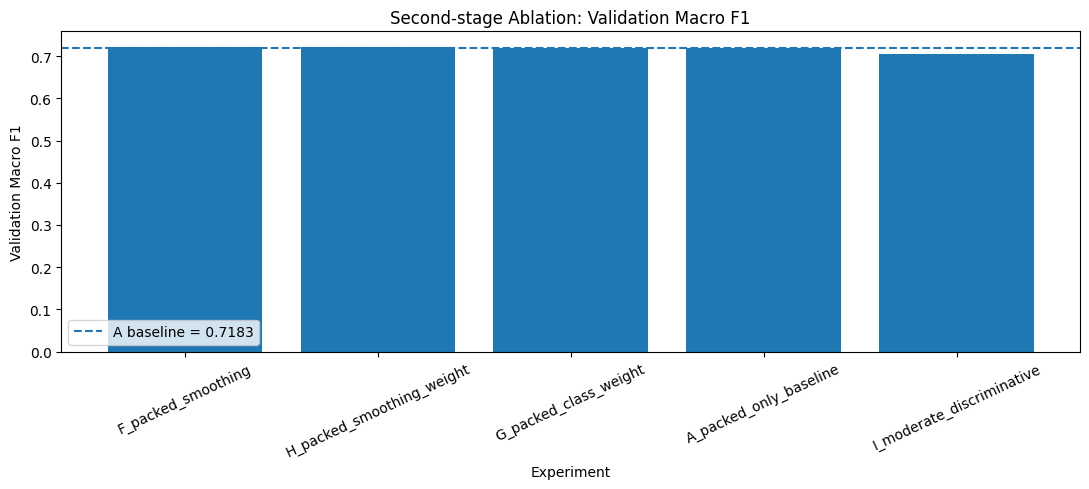

In [ ]:
stage2_val_df = (
    pd.DataFrame(stage2_records)
    .sort_values(
        "val_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

a_baseline_row = {
    "experiment": "A_packed_only_baseline",
    "best_epoch": 10,
    "val_loss": 1.5216,
    "val_accuracy": 0.7262,
    "val_macro_precision": 0.7261,
    "val_macro_recall": 0.7165,
    "val_macro_f1": 0.7183,
    "label_smoothing": 0.0,
    "use_class_weight": False,
    "embedding_lr": 2e-3,
    "gru_lr": 2e-3,
    "head_lr": 2e-3,
    "unfreeze_epoch": 1,
    "checkpoint_path": (
        "/content/checkpoints/"
        "improved_A_packed_only.pt"
    ),
}

stage2_with_baseline_df = (
    pd.concat(
        [
            pd.DataFrame([a_baseline_row]),
            stage2_val_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        "val_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    stage2_with_baseline_df[
        [
            "experiment",
            "best_epoch",
            "val_accuracy",
            "val_macro_precision",
            "val_macro_recall",
            "val_macro_f1",
            "label_smoothing",
            "use_class_weight",
            "embedding_lr",
            "gru_lr",
            "head_lr",
        ]
    ].style.format(
        {
            "val_accuracy": "{:.4f}",
            "val_macro_precision": "{:.4f}",
            "val_macro_recall": "{:.4f}",
            "val_macro_f1": "{:.4f}",
            "embedding_lr": "{:.1e}",
            "gru_lr": "{:.1e}",
            "head_lr": "{:.1e}",
        }
    )
)

plt.figure(figsize=(11, 5))
plt.bar(
    stage2_with_baseline_df["experiment"],
    stage2_with_baseline_df["val_macro_f1"],
)
plt.axhline(
    0.7183,
    linestyle="--",
    label="A baseline = 0.7183",
)
plt.title(
    "Second-stage Ablation: Validation Macro F1"
)
plt.xlabel("Experiment")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=25)
plt.legend()
plt.tight_layout()
plt.show()

## 24.7 2차 실험 학습 곡선

Regularization 설정이 다른 실험끼리는 loss 절댓값보다 Macro F1의 최고점과 안정성을 중심으로 해석합니다.

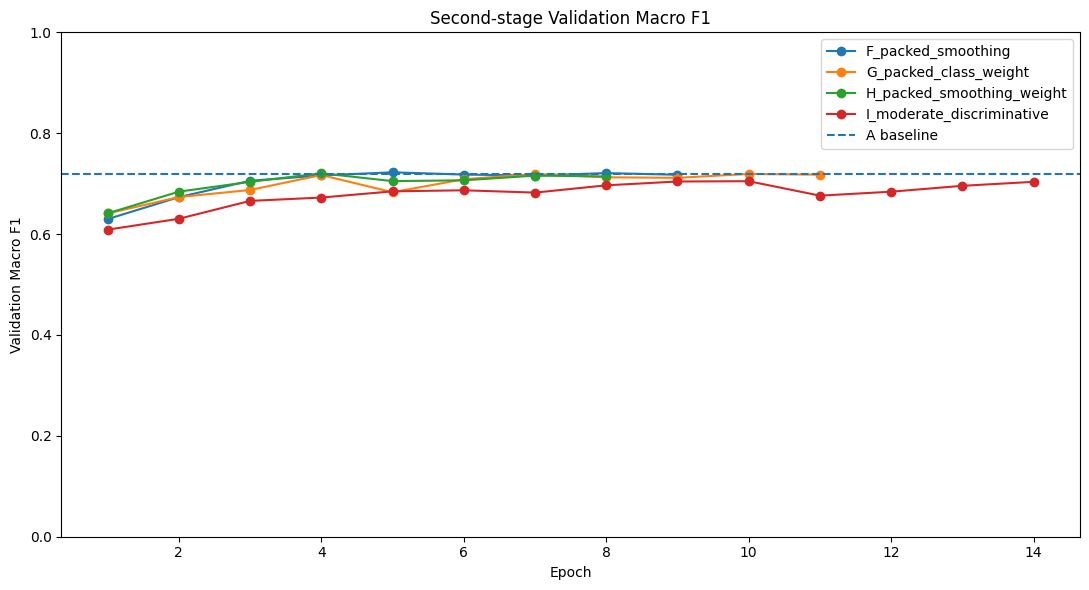

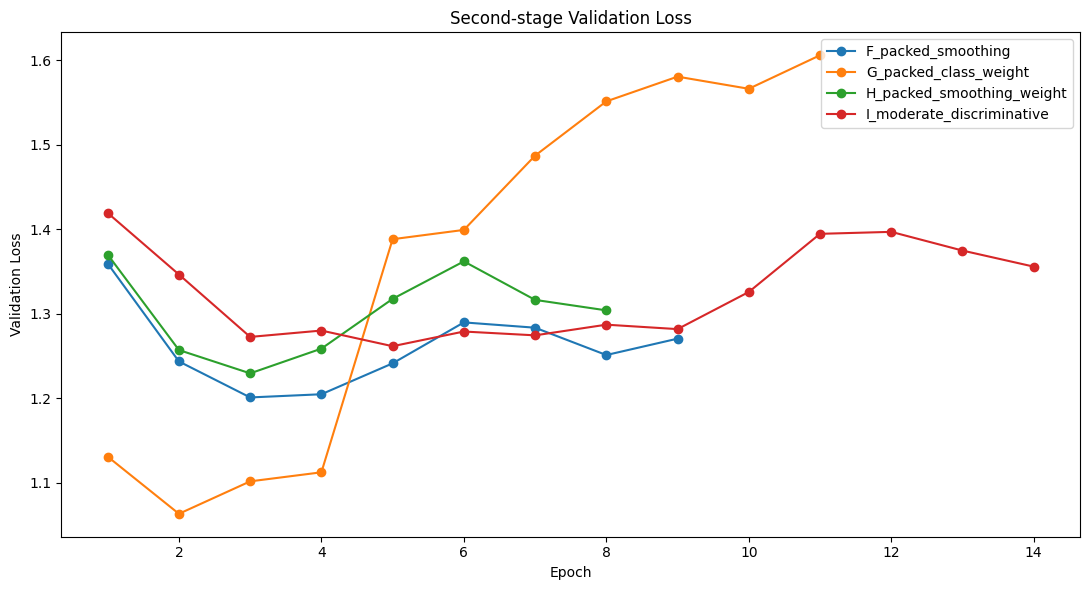

In [ ]:
plt.figure(figsize=(11, 6))

for experiment_name, history in stage2_histories.items():
    epochs = range(
        1,
        len(history["val_macro_f1"]) + 1,
    )
    plt.plot(
        epochs,
        history["val_macro_f1"],
        marker="o",
        label=experiment_name,
    )

plt.axhline(
    0.7183,
    linestyle="--",
    label="A baseline",
)
plt.title(
    "Second-stage Validation Macro F1"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 6))

for experiment_name, history in stage2_histories.items():
    epochs = range(
        1,
        len(history["val_loss"]) + 1,
    )
    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label=experiment_name,
    )

plt.title("Second-stage Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 24.8 Validation 기준 최종 모델 선택

- 새 후보가 A를 넘으면 해당 새 후보만 test set에서 평가합니다.
- A가 여전히 가장 높으면 test를 다시 평가하지 않고 23번의 기존 test 결과를 유지합니다.

In [ ]:
stage2_best_row = stage2_with_baseline_df.iloc[0]
stage2_best_name = stage2_best_row["experiment"]

print("Validation 기준 최종 모델:", stage2_best_name)
print(
    "Validation Macro F1:",
    f"{stage2_best_row['val_macro_f1']:.4f}",
)

stage2_new_candidate_selected = (
    stage2_best_name
    != "A_packed_only_baseline"
)

if stage2_new_candidate_selected:
    print(
        "새 후보가 A 기준선을 넘었습니다. "
        "다음 셀에서 test를 한 번 평가합니다."
    )
else:
    print(
        "A 기준선이 여전히 가장 높습니다. "
        "불필요한 test 재평가를 생략합니다."
    )

Validation 기준 최종 모델: F_packed_smoothing
Validation Macro F1: 0.7225
새 후보가 A 기준선을 넘었습니다. 다음 셀에서 test를 한 번 평가합니다.


## 24.9 선택 모델의 Test 평가

새 후보가 A를 넘어선 경우에만 test inference를 실행합니다.  
A가 유지되면 기존 test 결과를 그대로 사용합니다.

In [ ]:
ORIGINAL_ATTENTION_TEST = {
    "model": "Original Attention BiGRU",
    "experiment": "original_attention",
    "accuracy": 0.7227,
    "macro_precision": 0.7242,
    "macro_recall": 0.7122,
    "macro_f1": 0.7129,
    "test_loss": 1.3624,
}

A_PACKED_TEST = {
    "model": "Packed Attention BiGRU",
    "experiment": "A_packed_only_baseline",
    "accuracy": 0.7213,
    "macro_precision": 0.7214,
    "macro_recall": 0.7121,
    "macro_f1": 0.7134,
    "test_loss": 1.4889,
}

stage2_final_model = None
stage2_final_test_labels = None
stage2_final_test_predictions = None

if stage2_new_candidate_selected:
    stage2_best_config = next(
        config
        for config in selected_stage2_configs
        if config["name"] == stage2_best_name
    )

    seed_everything(STAGE2_SEED)

    stage2_final_model = (
        Stage2PackedAttentionBiGRU(
            embedding_matrix=(
                embedding_matrices["fasttext"]
            ),
            hidden_dim=HIDDEN_DIM,
            num_classes=len(target_names),
            num_layers=2,
            dropout=stage2_best_config["dropout"],
        ).to(DEVICE)
    )

    stage2_final_model.load_state_dict(
        torch.load(
            stage2_checkpoints[stage2_best_name],
            map_location=DEVICE,
        )
    )

    stage2_final_criterion = (
        stage2_build_criterion(
            stage2_best_config
        )
    )

    (
        stage2_final_test_loss,
        stage2_final_test_metrics,
        stage2_final_test_labels,
        stage2_final_test_predictions,
    ) = stage2_evaluate(
        stage2_final_model,
        test_loader,
        stage2_final_criterion,
    )

    STAGE2_FINAL_TEST = {
        "model": "Stage2 Packed Attention BiGRU",
        "experiment": stage2_best_name,
        "accuracy": stage2_final_test_metrics[
            "accuracy"
        ],
        "macro_precision": (
            stage2_final_test_metrics[
                "macro_precision"
            ]
        ),
        "macro_recall": (
            stage2_final_test_metrics[
                "macro_recall"
            ]
        ),
        "macro_f1": (
            stage2_final_test_metrics["macro_f1"]
        ),
        "test_loss": stage2_final_test_loss,
    }
else:
    STAGE2_FINAL_TEST = A_PACKED_TEST.copy()

stage2_test_comparison_df = pd.DataFrame(
    [
        ORIGINAL_ATTENTION_TEST,
        A_PACKED_TEST,
        STAGE2_FINAL_TEST,
    ]
).drop_duplicates(
    subset=["experiment"],
    keep="last",
)

display(
    stage2_test_comparison_df.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_precision": "{:.4f}",
            "macro_recall": "{:.4f}",
            "macro_f1": "{:.4f}",
            "test_loss": "{:.4f}",
        }
    )
)

,model,experiment,accuracy,macro_precision,macro_recall,macro_f1,test_loss
0,Original Attention BiGRU,original_attention,0.7227,0.7242,0.7122,0.7129,1.3624
1,Packed Attention BiGRU,A_packed_only_baseline,0.7213,0.7214,0.7121,0.7134,1.4889
2,Stage2 Packed Attention BiGRU,F_packed_smoothing,0.7283,0.7317,0.7184,0.7191,1.2545


## 24.10 2차 실험 자동 요약

In [ ]:
best_new_stage2_row = stage2_val_df.iloc[0]
best_new_stage2_name = (
    best_new_stage2_row["experiment"]
)
best_new_stage2_f1 = (
    best_new_stage2_row["val_macro_f1"]
)

gain_over_a_validation = (
    best_new_stage2_f1 - 0.7183
)
gain_over_a_test = (
    STAGE2_FINAL_TEST["macro_f1"] - 0.7134
)
gain_over_original_test = (
    STAGE2_FINAL_TEST["macro_f1"] - 0.7129
)

summary_lines = [
    "### 2차 개선 실험 결과",
    "",
    (
        f"- 새 후보 중 validation 1위: "
        f"**{best_new_stage2_name}**"
    ),
    (
        f"- 새 후보의 validation Macro F1: "
        f"**{best_new_stage2_f1:.4f}**"
    ),
    (
        f"- A 기준선 대비 validation 변화: "
        f"**{gain_over_a_validation:+.4f}**"
    ),
    (
        f"- Validation 기준 최종 선택: "
        f"**{stage2_best_name}**"
    ),
    (
        f"- 최종 Test Macro F1: "
        f"**{STAGE2_FINAL_TEST['macro_f1']:.4f}**"
    ),
    (
        f"- A test 대비 변화: "
        f"**{gain_over_a_test:+.4f}**"
    ),
    (
        f"- 기존 Attention test 대비 변화: "
        f"**{gain_over_original_test:+.4f}**"
    ),
]

if stage2_new_candidate_selected:
    summary_lines.extend(
        [
            "",
            (
                "새 regularization 후보가 A의 "
                "validation 성능을 넘어 test 평가 대상으로 "
                "선택되었습니다."
            ),
        ]
    )
else:
    summary_lines.extend(
        [
            "",
            (
                "새 후보가 A의 validation 성능을 넘지 못해 "
                "기존 A 모델을 유지했습니다."
            ),
        ]
    )

display(
    Markdown(
        "\n".join(summary_lines)
    )
)

### 2차 개선 실험 결과

- 새 후보 중 validation 1위: **F_packed_smoothing**
- 새 후보의 validation Macro F1: **0.7225**
- A 기준선 대비 validation 변화: **+0.0042**
- Validation 기준 최종 선택: **F_packed_smoothing**
- 최종 Test Macro F1: **0.7191**
- A test 대비 변화: **+0.0057**
- 기존 Attention test 대비 변화: **+0.0062**

새 regularization 후보가 A의 validation 성능을 넘어 test 평가 대상으로 선택되었습니다.

## 24.11 새 후보가 선택된 경우 Class별 성능 확인

A가 그대로 선택되면 기존 23.11의 class report와 confusion matrix를 사용합니다.

,precision,recall,f1-score,support
talk.religion.misc,0.5179,0.3085,0.3867,94
talk.politics.misc,0.6000,0.5948,0.5974,116
alt.atheism,0.5473,0.6750,0.6045,120
sci.electronics,0.6410,0.6757,0.6579,148
talk.politics.guns,0.7143,0.6204,0.6641,137
comp.sys.ibm.pc.hardware,0.7132,0.6259,0.6667,147
rec.sport.baseball,0.5514,0.8993,0.6837,149
comp.graphics,0.6250,0.7877,0.6970,146
comp.os.ms-windows.misc,0.7286,0.6892,0.7083,148
misc.forsale,0.7039,0.7279,0.7157,147


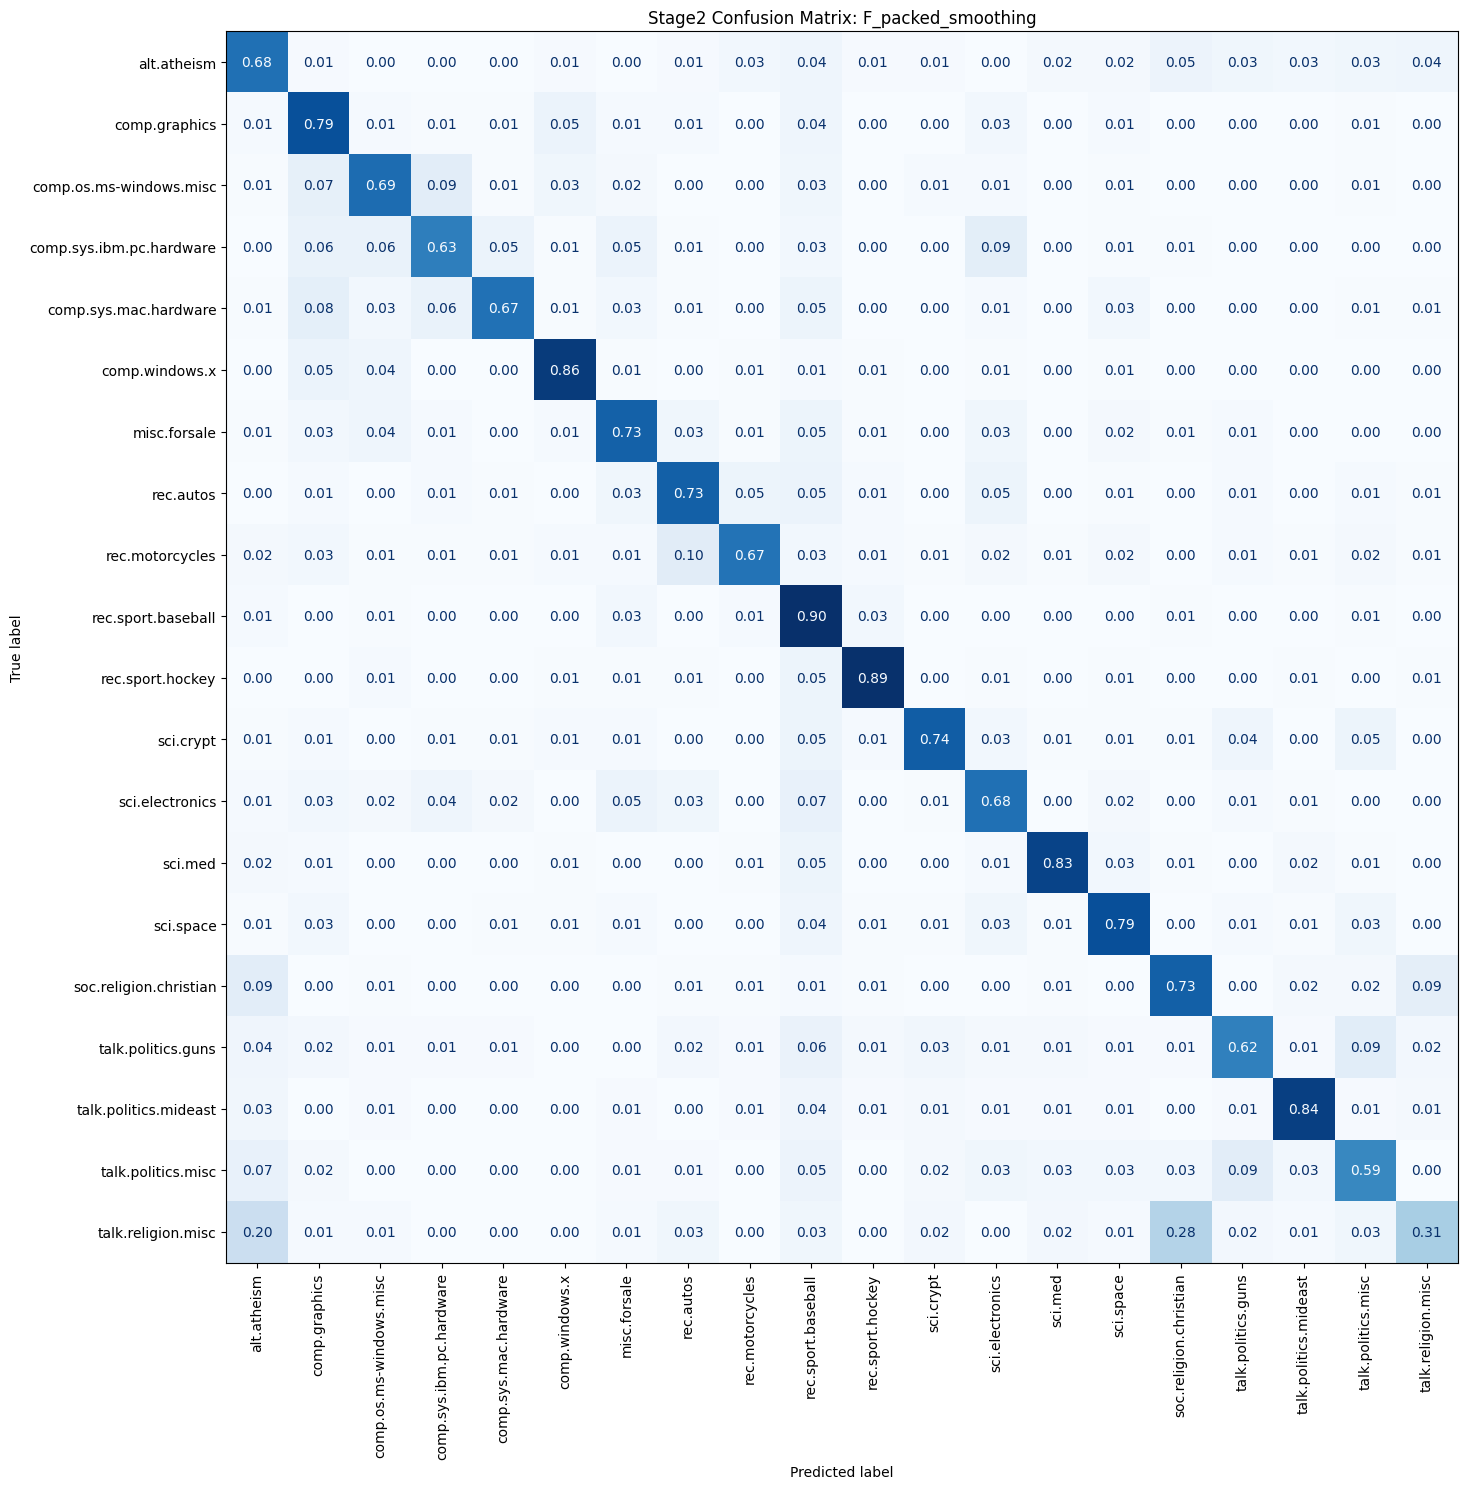

In [ ]:
if (
    stage2_new_candidate_selected
    and stage2_final_test_labels is not None
):
    stage2_report = classification_report(
        stage2_final_test_labels,
        stage2_final_test_predictions,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )

    stage2_class_report_df = (
        pd.DataFrame(stage2_report)
        .T
        .loc[
            target_names,
            [
                "precision",
                "recall",
                "f1-score",
                "support",
            ],
        ]
        .sort_values("f1-score")
    )

    display(
        stage2_class_report_df.style.format(
            {
                "precision": "{:.4f}",
                "recall": "{:.4f}",
                "f1-score": "{:.4f}",
                "support": "{:.0f}",
            }
        )
    )

    stage2_cm = confusion_matrix(
        stage2_final_test_labels,
        stage2_final_test_predictions,
        normalize="true",
    )

    fig, ax = plt.subplots(figsize=(15, 15))

    ConfusionMatrixDisplay(
        confusion_matrix=stage2_cm,
        display_labels=target_names,
    ).plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=False,
    )

    plt.title(
        f"Stage2 Confusion Matrix: "
        f"{stage2_best_name}"
    )
    plt.tight_layout()
    plt.show()
else:
    print(
        "A 모델이 유지되었습니다. "
        "23.11의 기존 class report와 "
        "confusion matrix를 참고하세요."
    )

## 24.12 결과 저장

2차 validation 결과와 최종 test 비교표를 CSV로 저장합니다.

In [ ]:
stage2_validation_path = (
    "/content/stage2_validation_results.csv"
)
stage2_test_path = (
    "/content/stage2_test_comparison.csv"
)

stage2_with_baseline_df.to_csv(
    stage2_validation_path,
    index=False,
)
stage2_test_comparison_df.to_csv(
    stage2_test_path,
    index=False,
)

print("2차 validation 결과:", stage2_validation_path)
print("2차 test 비교:", stage2_test_path)

if stage2_new_candidate_selected:
    print(
        "선택된 checkpoint:",
        stage2_checkpoints[stage2_best_name],
    )
else:
    print(
        "최종 선택은 기존 A baseline입니다."
    )

2차 validation 결과: /content/stage2_validation_results.csv
2차 test 비교: /content/stage2_test_comparison.csv
선택된 checkpoint: /content/checkpoints/stage2_F_packed_smoothing.pt


## 24.13 2차 개선 실험 결과 요약

### Validation 결과

| 순위 | 실험 | 변경 내용 | Best epoch | Validation Accuracy | Validation Macro F1 |
|---:|---|---|---:|---:|---:|
| 1 | **F** | Packing + label smoothing | 5 | **0.7336** | **0.7225** |
| 2 | H | Packing + label smoothing + class weight | 4 | 0.7301 | 0.7205 |
| 3 | G | Packing + class weight | 7 | 0.7273 | 0.7193 |
| 4 | A | Packing 기준 모델 | 10 | 0.7262 | 0.7183 |
| 5 | I | Moderate discriminative LR | 10 | 0.7152 | 0.7048 |

Validation Macro F1 기준으로 `F_packed_smoothing`이 최종 후보로 선택되었습니다.

### Test 결과

| 모델 | Accuracy | Macro Precision | Macro Recall | Macro F1 | Test loss |
|---|---:|---:|---:|---:|---:|
| 기존 Attention BiGRU | 0.7227 | 0.7242 | 0.7122 | 0.7129 | 1.3624 |
| A: Packed Attention | 0.7213 | 0.7214 | 0.7121 | 0.7134 | 1.4889 |
| **F: Packed + label smoothing** | **0.7283** | **0.7317** | **0.7184** | **0.7191** | **1.2545** |

### 핵심 변화

기존 Attention BiGRU 대비 F 모델은 다음과 같이 개선되었습니다.

- Accuracy: **+0.56%p**
- Macro Precision: **+0.75%p**
- Macro Recall: **+0.62%p**
- Macro F1: **+0.62%p**
- Test loss: **1.3624 → 1.2545**

A packing 모델 대비로도 Accuracy가 **0.70%p**, Macro F1이 **0.57%p** 증가했고 test loss는 **1.4889 → 1.2545**로 감소했습니다.

따라서 F는 점수만 높아진 것이 아니라, 틀린 예측에 과도한 확률을 부여하던 문제까지 완화한 개선 모델입니다.

### 실험별 해석

#### F. Label smoothing

F는 validation Macro F1 **0.7225**, test Macro F1 **0.7191**로 전체 최고 성능을 기록했습니다.

최고 validation 성능은 epoch 5에서 나타났으며, 이후 epoch을 늘려도 개선되지 않았습니다. 따라서 이번 향상은 단순한 학습 횟수 증가가 아니라 label smoothing이 예측 확률의 과신을 줄인 결과로 해석할 수 있습니다.

#### G. Class weight

G의 validation Macro F1은 **0.7193**으로 A보다 0.10%p 높았지만, 향상 폭은 작았습니다. 20 Newsgroups의 class imbalance가 극단적이지 않아 전체 성능에 미친 영향이 제한적이었던 것으로 보입니다.

#### H. Label smoothing + class weight

H의 validation Macro F1은 **0.7205**로 A보다 높았지만 F보다 0.20%p 낮았습니다. 이번 데이터에서는 class weight를 함께 적용하는 것보다 label smoothing만 사용하는 편이 더 효과적이었습니다.

#### I. Moderate discriminative LR

I는 epoch 10까지 점진적으로 개선되었지만 validation Macro F1 **0.7048**에 머물렀습니다. 낮은 embedding·GRU learning rate가 overfitting은 줄였지만 representation 학습까지 지나치게 억제한 것으로 판단됩니다.

### Class별 관찰

F 모델에서 F1이 가장 낮은 class는 다음과 같습니다.

| Class | Precision | Recall | F1 |
|---|---:|---:|---:|
| `talk.religion.misc` | 0.5179 | 0.3085 | 0.3867 |
| `talk.politics.misc` | 0.6000 | 0.5948 | 0.5974 |
| `alt.atheism` | 0.5473 | 0.6750 | 0.6045 |
| `sci.electronics` | 0.6410 | 0.6757 | 0.6579 |
| `talk.politics.guns` | 0.7143 | 0.6204 | 0.6641 |
| `comp.sys.ibm.pc.hardware` | 0.7132 | 0.6259 | 0.6667 |

Label smoothing은 전체 Macro F1을 높였지만 모든 class를 동일하게 개선하지는 않았습니다. 특히 `talk.religion.misc`는 recall이 0.3085로 낮아, `alt.atheism`이나 `soc.religion.christian`과의 의미 중첩이 계속 주요 병목으로 남았습니다.

### 2차 실험의 최종 결론

현재까지 가장 좋은 구성은 다음과 같습니다.

`FastText → Packed 2-layer BiGRU → Attention → Label smoothing 0.05`

주요 설정은 다음과 같습니다.

- Embedding·GRU·head LR: `2e-3`
- Dropout: `0.4`
- Weight decay: `1e-4`
- Label smoothing: `0.05`
- Class weight: 사용하지 않음
- Validation Macro F1 기반 checkpoint 선택

전체 실험에서 Test Macro F1은 다음과 같이 상승했습니다.

| 단계 | Test Macro F1 |
|---|---:|
| Word2Vec BiGRU | 0.6326 |
| GloVe BiGRU | 0.6508 |
| FastText BiGRU | 0.6658 |
| Attention BiGRU | 0.7129 |
| Packed Attention | 0.7134 |
| **Packed + label smoothing** | **0.7191** |

초기 Word2Vec 모델과 비교하면 Macro F1이 **8.65%p 상승**했습니다.

Optimizer와 regularization 조정에서는 label smoothing 단독이 가장 효과적이었습니다. 다음 병목은 다음 데이터 문제일 가능성이 높습니다.

1. `ax` 등 encoded payload noise
2. `MAX_LEN=300`에서 잘리는 긴 문서
3. 정제 후 빈 문서
4. 종교·정치처럼 의미가 겹치는 세부 category

따라서 다음 실험에서는 F 모델 구조와 학습 설정을 고정하고, **encoded noise 제거와 sequence length 확장 효과만 분리하여 검증**합니다.

# 25. 3차 데이터 개선 실험

2차 실험에서 모델 구조와 optimizer 조정보다 **label smoothing**이 가장 효과적이었습니다.  
이번에는 최고 모델 F의 구조와 학습 설정을 고정하고, 데이터 쪽 병목 두 가지를 검증합니다.

1. encoded payload와 반복 noise 제거
2. sequence budget을 300 token에서 512 token으로 확장

## 통제 실험 설계

| 실험 | 전처리 | MAX_LEN | FastText |
|---|---|---:|---|
| F baseline | 기존 | 300 | 기존 |
| J | 기존 | 512 | 기존 |
| K | noise 제거 | 300 | 정제 corpus로 재학습 |
| L | noise 제거 | 512 | 정제 corpus로 재학습 |

이 설계를 통해 다음을 분리해서 확인할 수 있습니다.

- J vs F: 길이 확장 효과
- K vs F: noise 제거 효과
- L vs K: 정제된 문서에서 길이 확장 효과
- L vs J: FastText 학습 corpus 정제 효과

모든 새 모델은 F와 동일하게 다음 설정을 사용합니다.

- Packed 2-layer BiGRU + Attention
- Label smoothing `0.05`
- Learning rate `2e-3`
- Dropout `0.4`
- Class weight 미사용
- Validation Macro F1 기반 checkpoint

> 빈 문서는 제거하지 않고 `<UNK>` 한 개로 유지합니다. 따라서 기존 test population과 직접 비교할 수 있습니다.

## 25.1 실행 환경 확인

이 섹션은 23번과 24번의 학습 결과 변수에 의존하지 않습니다.  
다만 새 runtime이라면 위쪽의 데이터 split, 기본 tokenization, FastText embedding 생성 셀까지 먼저 실행해야 합니다.

In [ ]:
import gc
import os
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from IPython.display import display, Markdown
from gensim.models import FastText
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence,
)

STAGE3_SEED = 42
STAGE3_MAX_EPOCHS = 12
STAGE3_PATIENCE = 4
STAGE3_MIN_DELTA = 1e-4
STAGE3_BATCH_SIZE = BATCH_SIZE
STAGE3_NUM_WORKERS = NUM_WORKERS

RUN_STAGE3_EXPERIMENTS = [
    "J_original_512",
    "K_clean_300",
    "L_clean_512",
]

required_stage3_objects = [
    "DEVICE",
    "SEED",
    "MIN_FREQ",
    "MAX_VOCAB_SIZE",
    "EMBED_DIM",
    "EMBED_TRAIN_EPOCHS",
    "HIDDEN_DIM",
    "PAD_IDX",
    "UNK_IDX",
    "target_names",
    "train_texts",
    "val_texts",
    "test_texts",
    "train_labels",
    "val_labels",
    "test_labels",
    "train_tokens",
    "val_tokens",
    "test_tokens",
    "stoi",
    "embedding_matrices",
    "compute_metrics",
    "seed_everything",
    "CHECKPOINT_DIR",
]

missing_stage3_objects = [
    name
    for name in required_stage3_objects
    if name not in globals()
]

if missing_stage3_objects:
    raise RuntimeError(
        "위쪽 데이터 및 FastText 준비 셀을 먼저 실행하세요. "
        f"현재 누락된 객체: {missing_stage3_objects}"
    )

if "fasttext" not in embedding_matrices:
    raise KeyError(
        "기존 FastText embedding matrix가 없습니다."
    )

print("3차 데이터 개선 실험 준비 완료")
print("실행 실험:", RUN_STAGE3_EXPERIMENTS)
print("Device:", DEVICE)
print("기존 vocabulary:", len(stoi))

ModuleNotFoundError: No module named 'gensim'

## 25.2 Encoded payload 제거 함수

다음 항목을 제거합니다.

- `begin 644 ...`부터 `end`까지의 uuencode block
- 매우 긴 Base64 형태 line
- 기호 비율이 지나치게 높은 긴 encoded line
- 한 문서 안에서 짧은 token 하나가 과도하게 반복되는 경우
- `ax`가 8회 이상 반복된 문서의 `ax` token

일반 문장을 무리하게 삭제하지 않도록 line 길이와 반복 비율 조건을 함께 사용합니다.

In [ ]:
STAGE3_TOKEN_PATTERN = re.compile(
    r"[a-z]+(?:'[a-z]+)?"
)

UUENCODE_BEGIN_PATTERN = re.compile(
    r"^\s*begin\s+[0-7]{3}\s+\S+",
    flags=re.IGNORECASE,
)
UUENCODE_END_PATTERN = re.compile(
    r"^\s*end\s*$",
    flags=re.IGNORECASE,
)
BASE64_LINE_PATTERN = re.compile(
    r"^[A-Za-z0-9+/=]+$"
)


def looks_like_encoded_line(line):
    stripped = line.strip()

    if len(stripped) < 80:
        return False

    compact = re.sub(r"\s+", "", stripped)

    if len(compact) < 80:
        return False

    base64_like = (
        len(compact) >= 100
        and BASE64_LINE_PATTERN.fullmatch(
            compact
        )
        is not None
    )

    symbol_count = sum(
        not character.isalnum()
        for character in compact
    )
    symbol_ratio = (
        symbol_count / max(len(compact), 1)
    )

    uuencode_like = (
        stripped.startswith("M")
        and len(compact) >= 60
        and symbol_ratio >= 0.20
    )

    symbol_heavy = (
        len(compact) >= 120
        and symbol_ratio >= 0.35
    )

    return (
        base64_like
        or uuencode_like
        or symbol_heavy
    )


def remove_encoded_payload(text):
    retained_lines = []
    inside_uuencode_block = False

    for line in text.splitlines():
        if UUENCODE_BEGIN_PATTERN.match(line):
            inside_uuencode_block = True
            continue

        if inside_uuencode_block:
            if UUENCODE_END_PATTERN.match(line):
                inside_uuencode_block = False
            continue

        if looks_like_encoded_line(line):
            continue

        retained_lines.append(line)

    return "\n".join(retained_lines)


def clean_and_tokenize_stage3(text):
    text = remove_encoded_payload(text)
    text = text.lower()

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text,
    )
    text = re.sub(
        r"\b[\w.\-+]+@[\w.\-]+\.\w+\b",
        " ",
        text,
    )
    text = re.sub(
        r"[^a-z'\s]",
        " ",
        text,
    )
    text = re.sub(
        r"\s+",
        " ",
        text,
    ).strip()

    tokens = STAGE3_TOKEN_PATTERN.findall(text)

    token_counts = Counter(tokens)

    repeated_short_noise = {
        token
        for token, count in token_counts.items()
        if (
            len(token) <= 2
            and count >= 20
            and count / max(len(tokens), 1) >= 0.20
        )
    }

    if token_counts.get("ax", 0) >= 8:
        repeated_short_noise.add("ax")

    if repeated_short_noise:
        tokens = [
            token
            for token in tokens
            if token not in repeated_short_noise
        ]

    return tokens

## 25.3 정제 전후 데이터 진단

문서 수는 유지한 채 token, 빈 문서, truncation 비율이 어떻게 변하는지 확인합니다.

In [ ]:
stage3_clean_train_tokens = [
    clean_and_tokenize_stage3(text)
    for text in train_texts
]
stage3_clean_val_tokens = [
    clean_and_tokenize_stage3(text)
    for text in val_texts
]
stage3_clean_test_tokens = [
    clean_and_tokenize_stage3(text)
    for text in test_texts
]


def stage3_token_diagnostics(
    tokenized_documents,
    max_len,
):
    lengths = np.asarray(
        [
            len(tokens)
            for tokens in tokenized_documents
        ]
    )

    token_counter = Counter(
        token
        for document in tokenized_documents
        for token in document
    )

    return {
        "documents": len(tokenized_documents),
        "empty_ratio": float(
            np.mean(lengths == 0)
        ),
        "mean_tokens": float(
            lengths.mean()
        ),
        "median_tokens": float(
            np.median(lengths)
        ),
        "truncated_ratio": float(
            np.mean(lengths > max_len)
        ),
        "ax_count": int(
            token_counter.get("ax", 0)
        ),
        "total_tokens": int(
            lengths.sum()
        ),
    }


diagnostic_rows = []

for token_source_name, token_source in [
    ("original_train", train_tokens),
    ("clean_train", stage3_clean_train_tokens),
]:
    for sequence_limit in [300, 512]:
        row = stage3_token_diagnostics(
            token_source,
            sequence_limit,
        )
        row["token_source"] = token_source_name
        row["max_len"] = sequence_limit
        diagnostic_rows.append(row)

stage3_diagnostics_df = pd.DataFrame(
    diagnostic_rows
)

display(
    stage3_diagnostics_df[
        [
            "token_source",
            "max_len",
            "documents",
            "total_tokens",
            "mean_tokens",
            "median_tokens",
            "empty_ratio",
            "truncated_ratio",
            "ax_count",
        ]
    ].style.format(
        {
            "mean_tokens": "{:.2f}",
            "median_tokens": "{:.1f}",
            "empty_ratio": "{:.2%}",
            "truncated_ratio": "{:.2%}",
        }
    )
)

original_counter_stage3 = Counter(
    token
    for document in train_tokens
    for token in document
)
clean_counter_stage3 = Counter(
    token
    for document in stage3_clean_train_tokens
    for token in document
)

print("정제 전 상위 token:")
print(
    original_counter_stage3.most_common(20)
)

print("\n정제 후 상위 token:")
print(
    clean_counter_stage3.most_common(20)
)

## 25.4 정제 corpus용 vocabulary와 FastText 재학습

K와 L은 정제된 train corpus만 사용해 vocabulary와 FastText를 새로 만듭니다.  
Validation과 test text는 vocabulary 및 embedding 학습에 사용하지 않습니다.

In [ ]:
STAGE3_PAD_TOKEN = "<PAD>"
STAGE3_UNK_TOKEN = "<UNK>"
STAGE3_PAD_IDX = 0
STAGE3_UNK_IDX = 1

stage3_clean_counter = Counter(
    token
    for document in stage3_clean_train_tokens
    for token in document
)

stage3_clean_common_tokens = [
    token
    for token, frequency
    in stage3_clean_counter.most_common(
        MAX_VOCAB_SIZE - 2
    )
    if frequency >= MIN_FREQ
]

stage3_clean_itos = [
    STAGE3_PAD_TOKEN,
    STAGE3_UNK_TOKEN,
] + stage3_clean_common_tokens

stage3_clean_stoi = {
    token: index
    for index, token
    in enumerate(stage3_clean_itos)
}

print(
    "정제 vocabulary 크기:",
    len(stage3_clean_stoi),
)

seed_everything(STAGE3_SEED)

stage3_clean_fasttext = FastText(
    sentences=stage3_clean_train_tokens,
    vector_size=EMBED_DIM,
    window=5,
    min_count=MIN_FREQ,
    workers=max(os.cpu_count() - 1, 1),
    sg=1,
    negative=10,
    epochs=EMBED_TRAIN_EPOCHS,
    seed=STAGE3_SEED,
)

stage3_rng = np.random.default_rng(
    STAGE3_SEED
)

stage3_clean_embedding_matrix = (
    stage3_rng.normal(
        loc=0.0,
        scale=0.05,
        size=(
            len(stage3_clean_stoi),
            EMBED_DIM,
        ),
    ).astype(np.float32)
)

stage3_clean_embedding_matrix[
    STAGE3_PAD_IDX
] = 0.0

for token, index in stage3_clean_stoi.items():
    if index in (
        STAGE3_PAD_IDX,
        STAGE3_UNK_IDX,
    ):
        continue

    stage3_clean_embedding_matrix[index] = (
        stage3_clean_fasttext.wv.get_vector(
            token
        )
    )

print(
    "정제 FastText embedding matrix:",
    stage3_clean_embedding_matrix.shape,
)

## 25.5 Sequence와 DataLoader 구성

- J는 기존 token·vocabulary·FastText를 유지하고 512 token까지 입력합니다.
- K는 정제 token·새 FastText를 사용하고 300 token까지 입력합니다.
- L은 정제 token·새 FastText를 사용하고 512 token까지 입력합니다.

In [ ]:
def stage3_encode_documents(
    tokenized_documents,
    vocabulary,
    max_len,
    unknown_index,
):
    encoded_documents = []

    for tokens in tokenized_documents:
        token_ids = [
            vocabulary.get(
                token,
                unknown_index,
            )
            for token in tokens[:max_len]
        ]

        if not token_ids:
            token_ids = [unknown_index]

        encoded_documents.append(
            token_ids
        )

    return encoded_documents


class Stage3NewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            torch.tensor(
                self.sequences[index],
                dtype=torch.long,
            ),
            torch.tensor(
                self.labels[index],
                dtype=torch.long,
            ),
        )


def stage3_collate(batch):
    sequences, labels_batch = zip(*batch)

    lengths = torch.tensor(
        [
            len(sequence)
            for sequence in sequences
        ],
        dtype=torch.long,
    )

    padded = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=STAGE3_PAD_IDX,
    )

    return (
        padded,
        lengths,
        torch.stack(labels_batch),
    )


def stage3_make_loaders(
    train_sequences,
    val_sequences,
    test_sequences,
):
    generator = torch.Generator()
    generator.manual_seed(STAGE3_SEED)

    loader_common = {
        "batch_size": STAGE3_BATCH_SIZE,
        "collate_fn": stage3_collate,
        "num_workers": STAGE3_NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
    }

    train_data_loader = DataLoader(
        Stage3NewsDataset(
            train_sequences,
            train_labels,
        ),
        shuffle=True,
        generator=generator,
        **loader_common,
    )

    validation_data_loader = DataLoader(
        Stage3NewsDataset(
            val_sequences,
            val_labels,
        ),
        shuffle=False,
        **loader_common,
    )

    test_data_loader = DataLoader(
        Stage3NewsDataset(
            test_sequences,
            test_labels,
        ),
        shuffle=False,
        **loader_common,
    )

    return (
        train_data_loader,
        validation_data_loader,
        test_data_loader,
    )


# J: 기존 전처리 + 512
stage3_j_sequences = {
    "train": stage3_encode_documents(
        train_tokens,
        stoi,
        512,
        UNK_IDX,
    ),
    "val": stage3_encode_documents(
        val_tokens,
        stoi,
        512,
        UNK_IDX,
    ),
    "test": stage3_encode_documents(
        test_tokens,
        stoi,
        512,
        UNK_IDX,
    ),
}

stage3_j_loaders = stage3_make_loaders(
    stage3_j_sequences["train"],
    stage3_j_sequences["val"],
    stage3_j_sequences["test"],
)

# K: 정제 전처리 + 300
stage3_k_sequences = {
    "train": stage3_encode_documents(
        stage3_clean_train_tokens,
        stage3_clean_stoi,
        300,
        STAGE3_UNK_IDX,
    ),
    "val": stage3_encode_documents(
        stage3_clean_val_tokens,
        stage3_clean_stoi,
        300,
        STAGE3_UNK_IDX,
    ),
    "test": stage3_encode_documents(
        stage3_clean_test_tokens,
        stage3_clean_stoi,
        300,
        STAGE3_UNK_IDX,
    ),
}

stage3_k_loaders = stage3_make_loaders(
    stage3_k_sequences["train"],
    stage3_k_sequences["val"],
    stage3_k_sequences["test"],
)

# L: 정제 전처리 + 512
stage3_l_sequences = {
    "train": stage3_encode_documents(
        stage3_clean_train_tokens,
        stage3_clean_stoi,
        512,
        STAGE3_UNK_IDX,
    ),
    "val": stage3_encode_documents(
        stage3_clean_val_tokens,
        stage3_clean_stoi,
        512,
        STAGE3_UNK_IDX,
    ),
    "test": stage3_encode_documents(
        stage3_clean_test_tokens,
        stage3_clean_stoi,
        512,
        STAGE3_UNK_IDX,
    ),
}

stage3_l_loaders = stage3_make_loaders(
    stage3_l_sequences["train"],
    stage3_l_sequences["val"],
    stage3_l_sequences["test"],
)

print("J/K/L DataLoader 생성 완료")

## 25.6 F 구조를 고정한 3차 실험 모델

세 실험 모두 동일한 Packed Attention BiGRU와 label smoothing을 사용합니다.

In [ ]:
class Stage3PackedAttentionBiGRU(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_classes,
        dropout=0.4,
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32,
        )

        self.embedding = (
            nn.Embedding.from_pretrained(
                embedding_tensor,
                freeze=False,
                padding_idx=STAGE3_PAD_IDX,
            )
        )

        self.gru = nn.GRU(
            input_size=embedding_tensor.shape[1],
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
        )

        self.attention_score = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Tanh(),
            nn.Linear(
                hidden_dim,
                1,
                bias=False,
            ),
        )

        self.norm = nn.LayerNorm(
            hidden_dim * 2
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(
            hidden_dim * 2,
            num_classes,
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)

        packed_input = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        packed_output, _ = self.gru(
            packed_input
        )

        sequence_output, _ = (
            pad_packed_sequence(
                packed_output,
                batch_first=True,
                total_length=input_ids.size(1),
            )
        )

        attention_logits = (
            self.attention_score(
                sequence_output
            ).squeeze(-1)
        )

        positions = torch.arange(
            input_ids.size(1),
            device=input_ids.device,
        ).unsqueeze(0)

        valid_mask = (
            positions < lengths.unsqueeze(1)
        )

        attention_logits = (
            attention_logits.masked_fill(
                ~valid_mask,
                -1e9,
            )
        )

        attention_weights = torch.softmax(
            attention_logits,
            dim=1,
        )

        document_vector = torch.sum(
            sequence_output
            * attention_weights.unsqueeze(-1),
            dim=1,
        )

        document_vector = self.norm(
            document_vector
        )
        document_vector = self.dropout(
            document_vector
        )

        return self.classifier(
            document_vector
        )

## 25.7 학습 및 평가 함수

F와 동일하게 모든 parameter에 LR `2e-3`, label smoothing `0.05`를 적용합니다.

In [ ]:
@torch.no_grad()
def stage3_evaluate(
    model,
    data_loader,
    criterion,
):
    model.eval()

    total_loss = 0.0
    labels_all = []
    predictions_all = []

    for input_ids, lengths, labels_batch in data_loader:
        input_ids = input_ids.to(
            DEVICE,
            non_blocking=True,
        )
        lengths = lengths.to(
            DEVICE,
            non_blocking=True,
        )
        labels_batch = labels_batch.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(
            input_ids,
            lengths,
        )
        loss = criterion(
            logits,
            labels_batch,
        )

        predictions = logits.argmax(dim=1)

        total_loss += (
            loss.item()
            * labels_batch.size(0)
        )
        labels_all.extend(
            labels_batch.cpu().numpy()
        )
        predictions_all.extend(
            predictions.cpu().numpy()
        )

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    metrics = compute_metrics(
        labels_all,
        predictions_all,
    )

    return (
        average_loss,
        metrics,
        np.asarray(labels_all),
        np.asarray(predictions_all),
    )


def stage3_train(
    model,
    train_data_loader,
    validation_data_loader,
    experiment_name,
):
    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.05
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=2e-3,
        weight_decay=1e-4,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
        )
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"stage3_{experiment_name}.pt"
    )

    best_val_f1 = -np.inf
    best_epoch = 0
    no_improvement_epochs = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
    }

    for epoch in range(
        1,
        STAGE3_MAX_EPOCHS + 1,
    ):
        model.train()

        total_train_loss = 0.0
        started_at = time.time()

        for (
            input_ids,
            lengths,
            labels_batch,
        ) in train_data_loader:
            input_ids = input_ids.to(
                DEVICE,
                non_blocking=True,
            )
            lengths = lengths.to(
                DEVICE,
                non_blocking=True,
            )
            labels_batch = labels_batch.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(
                input_ids,
                lengths,
            )
            loss = criterion(
                logits,
                labels_batch,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            total_train_loss += (
                loss.item()
                * labels_batch.size(0)
            )

        train_loss = (
            total_train_loss
            / len(train_data_loader.dataset)
        )

        (
            val_loss,
            val_metrics,
            _,
            _,
        ) = stage3_evaluate(
            model,
            validation_data_loader,
            criterion,
        )

        scheduler.step(
            val_metrics["macro_f1"]
        )

        history["train_loss"].append(
            train_loss
        )
        history["val_loss"].append(
            val_loss
        )
        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )
        history["val_macro_f1"].append(
            val_metrics["macro_f1"]
        )

        print(
            f"[{experiment_name}] "
            f"Epoch {epoch:02d}/{STAGE3_MAX_EPOCHS} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_metrics['accuracy']:.4f} | "
            f"val macro F1 {val_metrics['macro_f1']:.4f} | "
            f"lr {optimizer.param_groups[0]['lr']:.1e} | "
            f"{time.time() - started_at:.1f}s"
        )

        if (
            val_metrics["macro_f1"]
            > best_val_f1 + STAGE3_MIN_DELTA
        ):
            best_val_f1 = (
                val_metrics["macro_f1"]
            )
            best_epoch = epoch
            no_improvement_epochs = 0

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )
        else:
            no_improvement_epochs += 1

        if (
            no_improvement_epochs
            >= STAGE3_PATIENCE
        ):
            print(
                "Early stopping: "
                f"{STAGE3_PATIENCE} epoch 동안 "
                "validation Macro F1 개선 없음"
            )
            break

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=DEVICE,
        )
    )

    (
        best_val_loss,
        best_val_metrics,
        validation_labels,
        validation_predictions,
    ) = stage3_evaluate(
        model,
        validation_data_loader,
        criterion,
    )

    record = {
        "experiment": experiment_name,
        "best_epoch": best_epoch,
        "val_loss": best_val_loss,
        "val_accuracy": (
            best_val_metrics["accuracy"]
        ),
        "val_macro_precision": (
            best_val_metrics[
                "macro_precision"
            ]
        ),
        "val_macro_recall": (
            best_val_metrics[
                "macro_recall"
            ]
        ),
        "val_macro_f1": (
            best_val_metrics["macro_f1"]
        ),
        "checkpoint_path": str(
            checkpoint_path
        ),
    }

    return (
        model,
        criterion,
        history,
        record,
        validation_labels,
        validation_predictions,
    )

## 25.8 J·K·L 학습

각 실험은 동일한 seed에서 새 모델로 시작합니다.

In [ ]:
stage3_experiment_resources = {
    "J_original_512": {
        "embedding_matrix": (
            embedding_matrices["fasttext"]
        ),
        "loaders": stage3_j_loaders,
        "max_len": 512,
        "preprocessing": "original",
    },
    "K_clean_300": {
        "embedding_matrix": (
            stage3_clean_embedding_matrix
        ),
        "loaders": stage3_k_loaders,
        "max_len": 300,
        "preprocessing": "clean",
    },
    "L_clean_512": {
        "embedding_matrix": (
            stage3_clean_embedding_matrix
        ),
        "loaders": stage3_l_loaders,
        "max_len": 512,
        "preprocessing": "clean",
    },
}

stage3_records = []
stage3_histories = {}
stage3_checkpoints = {}
stage3_validation_predictions = {}

for experiment_name in (
    RUN_STAGE3_EXPERIMENTS
):
    print("\n" + "=" * 90)
    print(
        "Stage 3 experiment:",
        experiment_name,
    )
    print("=" * 90)

    resource = (
        stage3_experiment_resources[
            experiment_name
        ]
    )

    (
        train_data_loader,
        validation_data_loader,
        _,
    ) = resource["loaders"]

    seed_everything(STAGE3_SEED)

    model = Stage3PackedAttentionBiGRU(
        embedding_matrix=resource[
            "embedding_matrix"
        ],
        hidden_dim=HIDDEN_DIM,
        num_classes=len(target_names),
        dropout=0.4,
    ).to(DEVICE)

    (
        model,
        criterion,
        history,
        record,
        validation_labels,
        validation_predictions,
    ) = stage3_train(
        model,
        train_data_loader,
        validation_data_loader,
        experiment_name,
    )

    record["max_len"] = resource[
        "max_len"
    ]
    record["preprocessing"] = resource[
        "preprocessing"
    ]

    stage3_records.append(record)
    stage3_histories[
        experiment_name
    ] = history
    stage3_checkpoints[
        experiment_name
    ] = record["checkpoint_path"]
    stage3_validation_predictions[
        experiment_name
    ] = (
        validation_labels,
        validation_predictions,
    )

    model.to("cpu")
    del model
    torch.cuda.empty_cache()
    gc.collect()

## 25.9 F 기준선과 Validation 비교

F baseline의 validation Macro F1 `0.7225`를 기준으로 새 후보를 선택합니다.

In [ ]:
stage3_val_df = (
    pd.DataFrame(stage3_records)
    .sort_values(
        "val_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

stage3_f_baseline = {
    "experiment": "F_baseline_original_300",
    "best_epoch": 5,
    "val_loss": 1.2412,
    "val_accuracy": 0.7336,
    "val_macro_precision": 0.7315,
    "val_macro_recall": 0.7218,
    "val_macro_f1": 0.7225,
    "checkpoint_path": (
        "/content/checkpoints/"
        "stage2_F_packed_smoothing.pt"
    ),
    "max_len": 300,
    "preprocessing": "original",
}

stage3_with_baseline_df = (
    pd.concat(
        [
            pd.DataFrame(
                [stage3_f_baseline]
            ),
            stage3_val_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        "val_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    stage3_with_baseline_df[
        [
            "experiment",
            "preprocessing",
            "max_len",
            "best_epoch",
            "val_accuracy",
            "val_macro_precision",
            "val_macro_recall",
            "val_macro_f1",
        ]
    ].style.format(
        {
            "val_accuracy": "{:.4f}",
            "val_macro_precision": "{:.4f}",
            "val_macro_recall": "{:.4f}",
            "val_macro_f1": "{:.4f}",
        }
    )
)

plt.figure(figsize=(11, 5))
plt.bar(
    stage3_with_baseline_df[
        "experiment"
    ],
    stage3_with_baseline_df[
        "val_macro_f1"
    ],
)
plt.axhline(
    0.7225,
    linestyle="--",
    label="F baseline = 0.7225",
)
plt.title(
    "Data Cleaning and Sequence Budget: "
    "Validation Macro F1"
)
plt.xlabel("Experiment")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=25)
plt.legend()
plt.tight_layout()
plt.show()

## 25.10 학습 곡선

새 실험들의 validation Macro F1과 loss 변화를 확인합니다.

In [ ]:
plt.figure(figsize=(11, 6))

for (
    experiment_name,
    history,
) in stage3_histories.items():
    epochs = range(
        1,
        len(history["val_macro_f1"]) + 1,
    )

    plt.plot(
        epochs,
        history["val_macro_f1"],
        marker="o",
        label=experiment_name,
    )

plt.axhline(
    0.7225,
    linestyle="--",
    label="F baseline",
)
plt.title(
    "Stage 3 Validation Macro F1"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 6))

for (
    experiment_name,
    history,
) in stage3_histories.items():
    epochs = range(
        1,
        len(history["val_loss"]) + 1,
    )

    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label=experiment_name,
    )

plt.title("Stage 3 Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 25.11 Validation 기준 최종 후보 선택

새 후보가 F의 validation Macro F1을 넘는 경우에만 test set에서 한 번 평가합니다.

In [ ]:
stage3_best_row = (
    stage3_with_baseline_df.iloc[0]
)
stage3_best_name = (
    stage3_best_row["experiment"]
)

stage3_new_candidate_selected = (
    stage3_best_name
    != "F_baseline_original_300"
)

print(
    "Validation 기준 최종 모델:",
    stage3_best_name,
)
print(
    "Validation Macro F1:",
    f"{stage3_best_row['val_macro_f1']:.4f}",
)

if stage3_new_candidate_selected:
    print(
        "새 데이터 후보가 F 기준선을 넘었습니다. "
        "다음 셀에서 test를 한 번 평가합니다."
    )
else:
    print(
        "F 기준선이 여전히 가장 높습니다. "
        "새 test 평가는 생략합니다."
    )

## 25.12 최종 후보 Test 평가

F가 유지되면 기존 test 결과 `0.7191`을 사용합니다.  
새 후보가 선택된 경우 해당 후보만 test inference를 수행합니다.

In [ ]:
F_BASELINE_TEST_STAGE3 = {
    "model": (
        "Packed Attention + "
        "label smoothing"
    ),
    "experiment": (
        "F_baseline_original_300"
    ),
    "preprocessing": "original",
    "max_len": 300,
    "accuracy": 0.7283,
    "macro_precision": 0.7317,
    "macro_recall": 0.7184,
    "macro_f1": 0.7191,
    "test_loss": 1.2545,
}

stage3_final_model = None
stage3_final_test_labels = None
stage3_final_test_predictions = None

if stage3_new_candidate_selected:
    selected_resource = (
        stage3_experiment_resources[
            stage3_best_name
        ]
    )

    (
        _,
        _,
        selected_test_loader,
    ) = selected_resource["loaders"]

    seed_everything(STAGE3_SEED)

    stage3_final_model = (
        Stage3PackedAttentionBiGRU(
            embedding_matrix=(
                selected_resource[
                    "embedding_matrix"
                ]
            ),
            hidden_dim=HIDDEN_DIM,
            num_classes=len(target_names),
            dropout=0.4,
        ).to(DEVICE)
    )

    stage3_final_model.load_state_dict(
        torch.load(
            stage3_checkpoints[
                stage3_best_name
            ],
            map_location=DEVICE,
        )
    )

    stage3_final_criterion = (
        nn.CrossEntropyLoss(
            label_smoothing=0.05
        )
    )

    (
        stage3_final_test_loss,
        stage3_final_test_metrics,
        stage3_final_test_labels,
        stage3_final_test_predictions,
    ) = stage3_evaluate(
        stage3_final_model,
        selected_test_loader,
        stage3_final_criterion,
    )

    STAGE3_FINAL_TEST = {
        "model": (
            "Stage3 Packed Attention "
            "+ label smoothing"
        ),
        "experiment": stage3_best_name,
        "preprocessing": (
            selected_resource[
                "preprocessing"
            ]
        ),
        "max_len": (
            selected_resource["max_len"]
        ),
        "accuracy": (
            stage3_final_test_metrics[
                "accuracy"
            ]
        ),
        "macro_precision": (
            stage3_final_test_metrics[
                "macro_precision"
            ]
        ),
        "macro_recall": (
            stage3_final_test_metrics[
                "macro_recall"
            ]
        ),
        "macro_f1": (
            stage3_final_test_metrics[
                "macro_f1"
            ]
        ),
        "test_loss": (
            stage3_final_test_loss
        ),
    }
else:
    STAGE3_FINAL_TEST = (
        F_BASELINE_TEST_STAGE3.copy()
    )

stage3_test_comparison_df = pd.DataFrame(
    [
        F_BASELINE_TEST_STAGE3,
        STAGE3_FINAL_TEST,
    ]
).drop_duplicates(
    subset=["experiment"],
    keep="last",
)

display(
    stage3_test_comparison_df.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_precision": "{:.4f}",
            "macro_recall": "{:.4f}",
            "macro_f1": "{:.4f}",
            "test_loss": "{:.4f}",
        }
    )
)

## 25.13 자동 결과 요약

In [ ]:
best_new_stage3_row = (
    stage3_val_df.iloc[0]
)

best_new_stage3_name = (
    best_new_stage3_row["experiment"]
)
best_new_stage3_val_f1 = (
    best_new_stage3_row["val_macro_f1"]
)

validation_gain_over_f = (
    best_new_stage3_val_f1 - 0.7225
)
test_gain_over_f = (
    STAGE3_FINAL_TEST["macro_f1"]
    - 0.7191
)

stage3_summary_lines = [
    "### 3차 데이터 개선 실험 결과",
    "",
    (
        f"- 새 후보 중 validation 1위: "
        f"**{best_new_stage3_name}**"
    ),
    (
        f"- 새 후보의 validation Macro F1: "
        f"**{best_new_stage3_val_f1:.4f}**"
    ),
    (
        f"- F 대비 validation 변화: "
        f"**{validation_gain_over_f:+.4f}**"
    ),
    (
        f"- Validation 기준 최종 선택: "
        f"**{stage3_best_name}**"
    ),
    (
        f"- 최종 Test Macro F1: "
        f"**{STAGE3_FINAL_TEST['macro_f1']:.4f}**"
    ),
    (
        f"- F test 대비 변화: "
        f"**{test_gain_over_f:+.4f}**"
    ),
]

if stage3_new_candidate_selected:
    stage3_summary_lines.append(
        (
            "- 새 데이터 처리 후보가 F의 "
            "validation 성능을 넘어 test 평가 "
            "대상으로 선택되었습니다."
        )
    )
else:
    stage3_summary_lines.append(
        (
            "- 새 후보가 F를 넘지 못해 기존 "
            "F 모델을 유지했습니다."
        )
    )

display(
    Markdown(
        "\n".join(
            stage3_summary_lines
        )
    )
)

## 25.14 새 후보의 Class별 성능

새 후보가 선택된 경우 `talk.religion.misc` 등 어려운 class의 recall이 개선되었는지 확인합니다.

In [ ]:
if (
    stage3_new_candidate_selected
    and stage3_final_test_labels is not None
):
    stage3_report = classification_report(
        stage3_final_test_labels,
        stage3_final_test_predictions,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )

    stage3_class_report_df = (
        pd.DataFrame(stage3_report)
        .T
        .loc[
            target_names,
            [
                "precision",
                "recall",
                "f1-score",
                "support",
            ],
        ]
        .sort_values("f1-score")
    )

    display(
        stage3_class_report_df.style.format(
            {
                "precision": "{:.4f}",
                "recall": "{:.4f}",
                "f1-score": "{:.4f}",
                "support": "{:.0f}",
            }
        )
    )

    stage3_cm = confusion_matrix(
        stage3_final_test_labels,
        stage3_final_test_predictions,
        normalize="true",
    )

    fig, ax = plt.subplots(
        figsize=(15, 15)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=stage3_cm,
        display_labels=target_names,
    ).plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=False,
    )

    plt.title(
        f"Stage 3 Confusion Matrix: "
        f"{stage3_best_name}"
    )
    plt.tight_layout()
    plt.show()
else:
    print(
        "F 모델이 유지되었습니다. "
        "24.11의 class report와 "
        "confusion matrix를 참고하세요."
    )

## 25.15 결과 저장

In [ ]:
stage3_diagnostics_path = (
    "/content/stage3_data_diagnostics.csv"
)
stage3_validation_path = (
    "/content/stage3_validation_results.csv"
)
stage3_test_path = (
    "/content/stage3_test_comparison.csv"
)

stage3_diagnostics_df.to_csv(
    stage3_diagnostics_path,
    index=False,
)
stage3_with_baseline_df.to_csv(
    stage3_validation_path,
    index=False,
)
stage3_test_comparison_df.to_csv(
    stage3_test_path,
    index=False,
)

print(
    "데이터 진단:",
    stage3_diagnostics_path,
)
print(
    "Validation 결과:",
    stage3_validation_path,
)
print(
    "Test 비교:",
    stage3_test_path,
)

if stage3_new_candidate_selected:
    print(
        "선택 checkpoint:",
        stage3_checkpoints[
            stage3_best_name
        ],
    )
else:
    print(
        "최종 선택은 기존 F baseline입니다."
    )

## 25.16 결과 해석 기준

실행 후 다음 순서로 결론을 내립니다.

1. **J > F**  
   문서 후반의 정보가 중요했고 `MAX_LEN=512` 확장이 효과적이었습니다.

2. **K > F**  
   encoded payload 제거와 정제 FastText 재학습이 효과적이었습니다.

3. **L > K**  
   정제된 corpus에서도 512 token 확장이 추가로 유효했습니다.

4. **L > J**  
   같은 512 token 조건에서 noise 제거가 추가 이득을 만들었습니다.

5. **Validation은 올랐지만 test는 오르지 않음**  
   단일 validation split 선택 편향이나 seed 변동 가능성이 있습니다.

6. **세 후보 모두 F를 넘지 못함**  
   현재 병목은 단순 noise와 sequence 길이보다 category 간 의미 중첩일 가능성이 높습니다. 다음 후보는 hierarchical classification 또는 seed 반복 검증입니다.

> 최종 우승 모델은 seed `42`, `123`, `2026`으로 반복해 Macro F1 평균과 표준편차를 확인하는 것이 좋습니다.